# Cell Ranger gold-standard — IDTrack results analysis (time travel + namespace projection)

This notebook is **analysis-only**:

- It **does not run IDTrack** (no graph builds, no conversions).
- It **does not modify** the conversion caches created by `create_data.ipynb`.
- It only **reads**:
  - Cell Ranger `.h5ad` files (per Ensembl release)
  - Pickled IDTrack conversion outputs written by `run_idtrack.py` (per dataset/release/database pair)

**Main goals (marketing + manuscript-ready):**

1. Quantify what breaks *without* time travel (naive joins on raw IDs across releases).
2. Quantify what is recovered *with* IDTrack time travel into a fixed target release.
3. Produce **publication-ready multi-panel figures and tables** exported under:
   - Figures: `reproducibility/experiments/_outputs/_publication/figures/`
   - Tables: `reproducibility/experiments/_outputs/_publication/tables/`

**Expected inputs (configure in the next cell):**

- `GOLD_STANDARD_ANNDATA_DIR`: folder containing `<dataset>_<assembly>_<release>.h5ad`
- `IDTRACK_RUNS_DIR`: folder containing `<dataset>/<assembly>_<from_release>/<from_db>__<to_db>__<releases>.pickle`


## 0) Notebook bootstrap (paths, style, imports)

This cell sets up:

- repo-relative imports (`reproducibility/experiments/src`)
- standard output locations (publication exports + experiment-local copies)
- plotting style (shared rcParams)



In [1]:
from __future__ import annotations

import os
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns  # type: ignore
except Exception:  # noqa: S110
    sns = None

try:
    import anndata as ad  # type: ignore
except Exception as e:  # noqa: S110
    raise ImportError("This notebook requires anndata (scanpy environment recommended).") from e

try:
    from scipy import sparse  # type: ignore
except Exception as e:  # noqa: S110
    raise ImportError("This notebook requires scipy.") from e

# Add experiments/src to sys.path (layout-aware; works on Slurm and locally)
REPO_ROOT = Path(os.environ.get("REPO_ROOT", Path.cwd())).expanduser().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (
    (REPO_ROOT / "idtrack").is_dir()
    and ((REPO_ROOT / "reproducibility").is_dir() or (REPO_ROOT / "idtrack" / "reproducibility").is_dir())
):
    REPO_ROOT = REPO_ROOT.parent

REPRO_ROOT = REPO_ROOT / "reproducibility" if (REPO_ROOT / "reproducibility").is_dir() else REPO_ROOT / "idtrack" / "reproducibility"
EXPERIMENTS_SRC = REPRO_ROOT / "experiments" / "src"
if str(EXPERIMENTS_SRC) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_SRC))

from experiments_utils import (  # noqa: E402
    MANUSCRIPT_COLORS,
    atomic_write_text,
    atomic_write_dataframe_csv,
    atomic_write_dataframe_latex,
    cache_pickle_or_compute,
    notebook_context,
    read_pickle,
    safe_tag,
    save_figure,
    label_panels,
)

from plotting_utils import heatmap  # noqa: E402
from idtrack_results import jaccard_similarity  # noqa: E402

ctx = notebook_context("cellranger_idtrack", start=REPO_ROOT)

IDTRACK_LOCAL_REPO = ctx.idtrack_local_repo
CACHE_DIR = ctx.experiment_cache
MANUSCRIPT_FIGURES = ctx.manuscript_figures
MANUSCRIPT_TABLES = ctx.manuscript_tables

# Make sure nested imports/subprocesses see the same cache root.
os.environ.setdefault("IDTRACK_LOCAL_REPO", str(IDTRACK_LOCAL_REPO))

print("Repo root:", REPO_ROOT)
print("Experiments src:", EXPERIMENTS_SRC)
print("IDTRACK_LOCAL_REPO:", IDTRACK_LOCAL_REPO)
print("CACHE_DIR:", CACHE_DIR)
print("MANUSCRIPT_FIGURES:", MANUSCRIPT_FIGURES)
print("MANUSCRIPT_TABLES:", MANUSCRIPT_TABLES)


Repo root: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack
Experiments src: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/src
IDTRACK_LOCAL_REPO: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache
CACHE_DIR: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/experiments/cellranger_idtrack
MANUSCRIPT_FIGURES: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures
MANUSCRIPT_TABLES: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables


## 1) Configuration (inputs + what we will export)

Set these via environment variables or directly in this cell:

- `GOLD_STANDARD_ANNDATA_DIR` (required): `.h5ad` directory
- `IDTRACK_RUNS_DIR` (required): conversion pickle directory

Optional:

- `IDTRACK_DATASET`, `IDTRACK_ASSEMBLY` to pin a specific dataset/assembly
- `IDTRACK_TARGET_RELEASE` (default: 105)
- `IDTRACK_FOCUS_FROM_RELEASE` (default: 85)



In [2]:
# -------------------- User knobs --------------------

FORCE_REBUILD = False  # set True to rebuild analysis caches under CACHE_DIR
PLOT_ONLY_FROM_CACHE = bool(int(os.environ.get("IDTRACK_PLOT_ONLY_FROM_CACHE", "0")))
if PLOT_ONLY_FROM_CACHE and FORCE_REBUILD:
    print("[WARN] PLOT_ONLY_FROM_CACHE=1 disables FORCE_REBUILD to avoid recomputation.")
    FORCE_REBUILD = False

TARGET_RELEASE = int(os.environ.get("IDTRACK_TARGET_RELEASE", "105"))
FOCUS_FROM_RELEASE = int(os.environ.get("IDTRACK_FOCUS_FROM_RELEASE", "85"))

DATASET = os.environ.get("IDTRACK_DATASET", "").strip() or None
ASSEMBLY = os.environ.get("IDTRACK_ASSEMBLY", "").strip() or None

FROM_DATABASES = ("gene_id", "gene_symbol")
TO_DATABASES = ("ensembl_gene", "HGNC Symbol")

# Strategy for converting IDTrack 1→n outputs into a matrix-friendly mapping.
# - 'best': take the first target (ranked by IDTrack)
# - 'drop_ambiguous': keep only strict 1→1 mappings
MAPPING_STRATEGIES = ("best", "drop_ambiguous")

# Extra strategies used in optional deep dives.
# - 'split_equal': split 1→n counts equally across all targets (UMI-preserving; no arbitrary pick)
EXTRA_MAPPING_STRATEGIES = ("split_equal",)

# Marketing extensions (kept lightweight; all cacheable)
HERO_TOPK = int(os.environ.get("IDTRACK_HERO_TOPK", "200"))

# Cell-level deep dive knobs (set to 0 to disable sampling)
RUN_CELL_LEVEL_DEEPDIVE = bool(int(os.environ.get("IDTRACK_RUN_CELL_LEVEL_DEEPDIVE", "1")))
CELL_LEVEL_MAX_GENES = int(os.environ.get("IDTRACK_CELL_LEVEL_MAX_GENES", "2000"))
CELL_LEVEL_MAX_CELLS = int(os.environ.get("IDTRACK_CELL_LEVEL_MAX_CELLS", "5000"))
CELL_LEVEL_CHUNK_SIZE = int(os.environ.get("IDTRACK_CELL_LEVEL_CHUNK_SIZE", "512"))
CELL_LEVEL_NORM_SUM = float(os.environ.get("IDTRACK_CELL_LEVEL_NORM_SUM", "10000"))


def _first_existing(paths: list[str]) -> Path | None:
    for p in paths:
        raw = str(p).strip()
        if not raw:
            continue
        cand = Path(raw).expanduser().resolve()
        if cand.exists():
            return cand
    return None


RUNS_DIR = _first_existing(
    [
        os.environ.get("IDTRACK_RUNS_DIR", ""),
        "/ictstr01/home/icb/kemal.inecik/lustre_workspace/idtrack_experiments/idtrack_runs",
        "/lustre/groups/ml01/workspace/kemal.inecik/idtrack_experiments/idtrack_runs",
        str(Path.home() / "lustre_workspace" / "idtrack_experiments" / "idtrack_runs"),
    ]
)

ANNDATA_DIR = _first_existing(
    [
        os.environ.get("GOLD_STANDARD_ANNDATA_DIR", ""),
        "/home/icb/kemal.inecik/lustre_workspace/idtrack_experiments/anndatas",
        "/lustre/groups/ml01/workspace/kemal.inecik/idtrack_experiments/anndatas",
        str(Path.home() / "lustre_workspace" / "idtrack_experiments" / "anndatas"),
    ]
)

print("RUNS_DIR:", RUNS_DIR)
print("ANNDATA_DIR:", ANNDATA_DIR)
print("PLOT_ONLY_FROM_CACHE:", PLOT_ONLY_FROM_CACHE)
print("TARGET_RELEASE:", TARGET_RELEASE)
print("FOCUS_FROM_RELEASE:", FOCUS_FROM_RELEASE)
print("DATASET:", DATASET)
print("ASSEMBLY:", ASSEMBLY)

if RUNS_DIR is None or not RUNS_DIR.exists():
    if PLOT_ONLY_FROM_CACHE:
        print("[WARN] RUNS_DIR not found; plot-only mode assumes required analysis caches already exist under CACHE_DIR.")
    else:
        raise FileNotFoundError(
            "Could not locate IDTrack run outputs. Set env var IDTRACK_RUNS_DIR to the folder containing idtrack_runs/."
        )

if ANNDATA_DIR is None or not ANNDATA_DIR.exists():
    if PLOT_ONLY_FROM_CACHE:
        print(
            "[WARN] ANNDATA_DIR not found; plot-only mode assumes required analysis caches already exist under CACHE_DIR."
        )
    else:
        raise FileNotFoundError(
            "Could not locate gold-standard .h5ad files. Set env var GOLD_STANDARD_ANNDATA_DIR to the folder containing *.h5ad."
        )


RUNS_DIR: /ictstr01/groups/ml01/workspace/kemal.inecik/idtrack_experiments/idtrack_runs
ANNDATA_DIR: /ictstr01/groups/ml01/workspace/kemal.inecik/idtrack_experiments/anndatas
PLOT_ONLY_FROM_CACHE: False
TARGET_RELEASE: 105
FOCUS_FROM_RELEASE: 85
DATASET: None
ASSEMBLY: None


## 2) Utilities (discovery, loading, fast summarization, mapping)

This cell defines small helpers used throughout the notebook:

- discover `.h5ad` inputs and conversion pickles
- load a specific `(from_release → to_release)` conversion payload (read-only)
- fast outcome summarization (no graph required)
- build sparse “feature → target” mapping matrices for downstream count preservation analyses



In [3]:
from collections.abc import Iterable


def _canonical_final_db(name: str) -> str:
    s = str(name).strip()
    s_lower = s.lower().replace("_", " ").strip()
    if s_lower in {"ensembl gene", "ensembl"}:
        return "Ensembl gene"
    if s_lower in {"hgnc symbol", "hgnc"}:
        return "HGNC Symbol"
    return s


def _normalize_gene_id(x: str) -> str:
    s = str(x).strip()
    return re.sub(r"\.(\d+)$", "", s)


def _normalize_gene_symbol(x: str) -> str:
    return str(x).strip()


def discover_h5ad_files(anndata_dir: Path) -> pd.DataFrame:
    h5ads = sorted(Path(anndata_dir).glob("*.h5ad"))
    pat = re.compile(r"^(?P<dataset>.+?)_(?P<assembly>[^_]+)_(?P<release>\d+)\.h5ad$")
    rows = []
    for p in h5ads:
        m = pat.match(p.name)
        if not m:
            continue
        rows.append(
            {
                "dataset": m.group("dataset"),
                "assembly": m.group("assembly"),
                "release": int(m.group("release")),
                "path": str(p),
            }
        )
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["dataset", "assembly", "release"]).reset_index(drop=True)


def discover_run_pickles(runs_dir: Path) -> pd.DataFrame:
    runs_dir = Path(runs_dir).expanduser().resolve()
    rows: list[dict] = []

    for dataset_dir in sorted([p for p in runs_dir.iterdir() if p.is_dir()]):
        dataset_key = dataset_dir.name
        for job_dir in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
            # expected: <assembly>_<from_release>
            if "_" not in job_dir.name:
                continue
            assembly_label, from_release_str = job_dir.name.rsplit("_", 1)
            if not from_release_str.isdigit():
                continue
            from_release = int(from_release_str)

            for pkl in job_dir.glob("*.pickle"):
                stem = pkl.name[:-7] if pkl.name.endswith(".pickle") else pkl.stem
                parts = stem.split("__", 2)
                if len(parts) != 3:
                    continue
                from_db, to_db, to_release_str_list = parts
                try:
                    to_releases = [int(x) for x in to_release_str_list.split("|") if str(x).strip()]
                except Exception:
                    to_releases = []

                rows.append(
                    {
                        "dataset": dataset_key,
                        "assembly": assembly_label,
                        "from_release": int(from_release),
                        "from_database": str(from_db),
                        "to_database": str(to_db),
                        "to_releases": to_releases,
                        "path": str(pkl),
                        "mtime": float(pkl.stat().st_mtime),
                    }
                )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["final_database"] = df["to_database"].map(_canonical_final_db)
    return df.sort_values(["dataset", "assembly", "from_release", "from_database", "to_database", "mtime"]).reset_index(
        drop=True
    )


def select_dataset_assembly(
    files: pd.DataFrame,
    runs: pd.DataFrame,
    *,
    dataset: str | None,
    assembly: str | None,
) -> tuple[str, str]:
    if dataset and assembly:
        return dataset, assembly

    if files.empty or runs.empty:
        raise RuntimeError("No inputs discovered: files or runs is empty.")

    f = files.groupby(["dataset", "assembly"], as_index=False)["release"].nunique().rename(columns={"release": "n_h5ad"})
    r = runs.groupby(["dataset", "assembly"], as_index=False)["from_release"].nunique().rename(columns={"from_release": "n_runs"})
    merged = f.merge(r, on=["dataset", "assembly"], how="inner")
    if merged.empty:
        raise RuntimeError("No dataset/assembly pair exists in BOTH h5ad files and run pickles.")

    if dataset:
        merged = merged[merged["dataset"].astype(str) == str(dataset)]
    if assembly:
        merged = merged[merged["assembly"].astype(str) == str(assembly)]

    if merged.empty:
        raise RuntimeError(
            "The requested DATASET/ASSEMBLY filter removed all candidates. "
            "Unset IDTRACK_DATASET/IDTRACK_ASSEMBLY or verify spelling."
        )

    best = merged.sort_values(["n_h5ad", "n_runs", "dataset", "assembly"], ascending=[False, False, True, True]).iloc[0]
    return str(best["dataset"]), str(best["assembly"])


def select_run_pickle_path(
    runs_index: pd.DataFrame,
    *,
    dataset: str,
    assembly: str,
    from_release: int,
    from_database: str,
    to_database: str,
    to_release: int,
) -> Path | None:
    sub = runs_index[
        (runs_index["dataset"].astype(str) == str(dataset))
        & (runs_index["assembly"].astype(str) == str(assembly))
        & (runs_index["from_release"].astype(int) == int(from_release))
        & (runs_index["from_database"].astype(str) == str(from_database))
        & (runs_index["to_database"].astype(str) == str(to_database))
    ].copy()

    if sub.empty:
        return None

    sub["has_to_release"] = sub["to_releases"].apply(lambda xs: int(to_release) in set(map(int, xs or [])))
    sub = sub[sub["has_to_release"]]
    if sub.empty:
        return None

    row = sub.sort_values("mtime", ascending=False).iloc[0]
    return Path(row["path"]).expanduser().resolve()


def load_matchings(
    runs_index: pd.DataFrame,
    *,
    dataset: str,
    assembly: str,
    from_release: int,
    from_database: str,
    to_database: str,
    to_release: int,
) -> list[dict] | None:
    pkl = select_run_pickle_path(
        runs_index,
        dataset=dataset,
        assembly=assembly,
        from_release=from_release,
        from_database=from_database,
        to_database=to_database,
        to_release=to_release,
    )
    if pkl is None or not pkl.exists():
        return None

    obj = read_pickle(pkl)
    if not isinstance(obj, dict):
        raise TypeError(f"Unexpected pickle payload in {pkl}: expected dict[int->list[matchings]].")

    key = int(to_release)
    matchings = obj.get(key)
    if matchings is None:
        matchings = obj.get(str(key))

    if matchings is None:
        return None

    if not isinstance(matchings, list):
        raise TypeError(f"Unexpected matchings type in {pkl} for to_release={to_release}: {type(matchings)}")
    return matchings


# -------------------- Fast summarization (pure Python; no graph required) --------------------

def summarize_matchings_fast(matchings: list[dict]) -> dict[str, int]:
    total = len(matchings)

    n_1_to_0 = 0
    n_1_to_1_tdm = 0
    n_1_to_1_atm = 0
    n_1_to_n_tdm = 0
    n_1_to_n_atm = 0
    n_changed_1_to_1 = 0
    n_changed_1_to_n = 0

    for item in matchings:
        no_corr = bool(item.get("no_corresponding"))
        no_conv = bool(item.get("no_conversion"))
        if no_corr or no_conv:
            n_1_to_0 += 1
            continue

        targets = item.get("target_id") or []
        if not isinstance(targets, list):
            n_1_to_0 += 1
            continue

        cleaned = []
        for t in targets:
            if t is None:
                continue
            s = str(t).strip()
            if not s or s.lower() in {"nan", "none", "null"}:
                continue
            cleaned.append(s)

        if not cleaned:
            n_1_to_0 += 1
            continue

        no_target = bool(item.get("no_target"))
        query_id = str(item.get("query_id"))

        seen = set()
        uniq = []
        for t in cleaned:
            if t in seen:
                continue
            seen.add(t)
            uniq.append(t)

        if len(uniq) == 1:
            if no_target:
                n_1_to_1_atm += 1
            else:
                n_1_to_1_tdm += 1
                if uniq[0] != query_id:
                    n_changed_1_to_1 += 1
        else:
            if no_target:
                n_1_to_n_atm += 1
            else:
                n_1_to_n_tdm += 1
                if not any(t == query_id for t in uniq):
                    n_changed_1_to_n += 1

    out = {
        "total": int(total),
        "1_to_0": int(n_1_to_0),
        "1_to_1_tdm": int(n_1_to_1_tdm),
        "1_to_1_atm": int(n_1_to_1_atm),
        "1_to_n_tdm": int(n_1_to_n_tdm),
        "1_to_n_atm": int(n_1_to_n_atm),
        "changed_1_to_1": int(n_changed_1_to_1),
        "changed_1_to_n": int(n_changed_1_to_n),
    }
    out["1_to_1_total"] = out["1_to_1_tdm"] + out["1_to_1_atm"]
    out["1_to_n_total"] = out["1_to_n_tdm"] + out["1_to_n_atm"]
    return out


def add_fraction_columns(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    den = out["total"].replace(0, np.nan)
    mapping = {
        "frac_1_to_0": "1_to_0",
        "frac_1_to_1_tdm": "1_to_1_tdm",
        "frac_1_to_1_atm": "1_to_1_atm",
        "frac_1_to_n_tdm": "1_to_n_tdm",
        "frac_1_to_n_atm": "1_to_n_atm",
        "frac_1_to_1_total": "1_to_1_total",
        "frac_1_to_n_total": "1_to_n_total",
        "frac_changed_1_to_1": "changed_1_to_1",
        "frac_changed_1_to_n": "changed_1_to_n",
    }
    for frac, raw in mapping.items():
        if raw in out.columns and frac not in out.columns:
            out[frac] = out[raw] / den

    if "frac_tdm_total" not in out.columns:
        out["frac_tdm_total"] = (out["1_to_1_tdm"] + out["1_to_n_tdm"]) / den
    if "frac_atm_total" not in out.columns:
        out["frac_atm_total"] = (out["1_to_1_atm"] + out["1_to_n_atm"]) / den
    if "frac_changed_any" not in out.columns:
        out["frac_changed_any"] = (out["changed_1_to_1"] + out["changed_1_to_n"]) / den

    out["frac_success"] = 1.0 - out["frac_1_to_0"].fillna(0)
    return out


# -------------------- Mapping matrices (for UMI retention and expression consistency) --------------------

def build_mapping_matrix(
    matchings: list[dict],
    *,
    strategy: str,
) -> tuple[sparse.csr_matrix, list[str], dict[str, np.ndarray]]:
    # strategy:
    #   - 'best': choose the first target_id (ranked)
    #   - 'drop_ambiguous': keep only strict 1→1 mappings
    #   - 'split_equal': split 1→n equally across targets (UMI-preserving; no arbitrary pick)

    if strategy not in {"best", "drop_ambiguous", "split_equal"}:
        raise ValueError("strategy must be one of: 'best', 'drop_ambiguous', 'split_equal'")

    n = len(matchings)

    is_1_to_0 = np.zeros(n, dtype=bool)
    is_1_to_1 = np.zeros(n, dtype=bool)
    is_1_to_n = np.zeros(n, dtype=bool)
    is_atm = np.zeros(n, dtype=bool)

    row_targets: list[list[str]] = [[] for _ in range(n)]
    row_weights: list[list[float]] = [[] for _ in range(n)]

    for i, item in enumerate(matchings):
        no_corr = bool(item.get("no_corresponding"))
        no_conv = bool(item.get("no_conversion"))
        if no_corr or no_conv:
            is_1_to_0[i] = True
            continue

        targets = item.get("target_id") or []
        if not isinstance(targets, list) or not targets:
            is_1_to_0[i] = True
            continue

        cleaned = []
        seen = set()
        for t in targets:
            if t is None:
                continue
            s = str(t).strip()
            if not s or s.lower() in {"nan", "none", "null"}:
                continue
            if s in seen:
                continue
            seen.add(s)
            cleaned.append(s)

        if not cleaned:
            is_1_to_0[i] = True
            continue

        no_target = bool(item.get("no_target"))
        if no_target:
            is_atm[i] = True

        if len(cleaned) == 1:
            is_1_to_1[i] = True
            row_targets[i] = [cleaned[0]]
            row_weights[i] = [1.0]
        else:
            is_1_to_n[i] = True
            if strategy == "best":
                row_targets[i] = [cleaned[0]]
                row_weights[i] = [1.0]
            elif strategy == "split_equal":
                w = 1.0 / float(len(cleaned))
                row_targets[i] = cleaned
                row_weights[i] = [w] * len(cleaned)
            else:
                # drop_ambiguous
                row_targets[i] = []
                row_weights[i] = []

    target_ids = sorted({t for ts in row_targets for t in ts})
    idx = {t: j for j, t in enumerate(target_ids)}

    rows = []
    cols = []
    data = []

    for i, (ts, ws) in enumerate(zip(row_targets, row_weights, strict=False)):
        for t, w in zip(ts, ws, strict=False):
            j = idx.get(t)
            if j is None:
                continue
            rows.append(i)
            cols.append(j)
            data.append(float(w))

    M = sparse.csr_matrix((data, (rows, cols)), shape=(n, len(target_ids)), dtype=float)

    debug = {
        "is_1_to_0": is_1_to_0,
        "is_1_to_1": is_1_to_1,
        "is_1_to_n": is_1_to_n,
        "is_atm": is_atm,
        "has_mapping": np.array([bool(ts) for ts in row_targets], dtype=bool),
    }
    return M, target_ids, debug


def feature_totals_from_h5ad(path: Path) -> tuple[np.ndarray, pd.DataFrame]:
    adata = ad.read_h5ad(str(path))
    X = adata.X
    if sparse.issparse(X):
        totals = np.asarray(X.sum(axis=0)).ravel()
    else:
        totals = np.asarray(X).sum(axis=0)
    return totals.astype(np.float64, copy=False), adata.var.copy()


def series_from_ids_and_totals(ids: Iterable[str], totals: np.ndarray, *, normalize: str | None) -> pd.Series:
    ids = list(ids)
    if len(ids) != int(len(totals)):
        raise ValueError(f"ids length ({len(ids)}) != totals length ({len(totals)})")

    if normalize == "gene_id":
        keys = [_normalize_gene_id(x) for x in ids]
    elif normalize == "gene_symbol":
        keys = [_normalize_gene_symbol(x) for x in ids]
    else:
        keys = [str(x) for x in ids]

    s = pd.Series(totals, index=pd.Index(keys, name="id"), dtype=float)
    return s.groupby(level=0).sum()


def pearsonr_log1p(a: pd.Series, b: pd.Series) -> float:
    if a.empty or b.empty:
        return float("nan")
    aa = np.log1p(a.values)
    bb = np.log1p(b.values)
    if aa.size < 2:
        return float("nan")
    if np.all(aa == aa[0]) or np.all(bb == bb[0]):
        return float("nan")
    return float(np.corrcoef(aa, bb)[0, 1])


def spearmanr_log1p(a: pd.Series, b: pd.Series) -> float:
    if a.empty or b.empty:
        return float("nan")
    aa = np.log1p(a.values)
    bb = np.log1p(b.values)
    if aa.size < 2:
        return float("nan")
    ra = pd.Series(aa).rank(method="average").values
    rb = pd.Series(bb).rank(method="average").values
    if np.all(ra == ra[0]) or np.all(rb == rb[0]):
        return float("nan")
    return float(np.corrcoef(ra, rb)[0, 1])


## 3) Discover inputs and choose dataset/assembly

This section:

- indexes all `.h5ad` files in `ANNDATA_DIR`
- indexes all conversion pickles in `RUNS_DIR`
- auto-selects the dataset/assembly pair with the widest coverage (unless pinned)



In [4]:
# Plot-only mode: infer dataset/assembly + release coverage from cached analysis artifacts.
# This lets you regenerate figures locally without copying `.h5ad` files or raw IDTrack run pickles.

if PLOT_ONLY_FROM_CACHE:
    candidates = sorted(CACHE_DIR.glob("target_summary_*.pickle"))
    if not candidates:
        raise FileNotFoundError(
            f"No target_summary_*.pickle caches found under CACHE_DIR={CACHE_DIR}. "
            "Copy experiment caches (IDTRACK_LOCAL_REPO/experiments/cellranger_idtrack) from the server, "
            "or disable IDTRACK_PLOT_ONLY_FROM_CACHE."
        )

    # Prefer caches matching requested TARGET_RELEASE (if present in filename).
    prefer = [p for p in candidates if f"to{int(TARGET_RELEASE)}" in p.stem]
    if prefer:
        candidates = prefer

    best_path: Path | None = None
    best_df: pd.DataFrame | None = None
    best_score = (-1, -1.0)

    for p in candidates:
        try:
            df = read_pickle(p)
        except Exception:
            continue
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue
        needed = {"dataset", "assembly", "from_release", "to_release"}
        if not needed.issubset(set(df.columns)):
            continue

        ds = sorted(set(df["dataset"].astype(str).tolist()))
        ass = sorted(set(df["assembly"].astype(str).tolist()))
        tr = sorted(set(df["to_release"].astype(int).tolist()))
        if len(ds) != 1 or len(ass) != 1 or len(tr) != 1:
            continue

        if DATASET is not None and str(DATASET) != ds[0]:
            continue
        if ASSEMBLY is not None and str(ASSEMBLY) != ass[0]:
            continue

        n_rel = len(set(df["from_release"].astype(int).tolist()))
        score = (int(n_rel), float(p.stat().st_mtime))
        if score > best_score:
            best_score = score
            best_path = p
            best_df = df

    if best_df is None or best_path is None:
        raise RuntimeError(
            "Could not select a valid target_summary cache. "
            "Set IDTRACK_DATASET and IDTRACK_ASSEMBLY explicitly, or regenerate caches on the server."
        )

    DATASET_SEL = str(best_df["dataset"].iloc[0])
    ASSEMBLY_SEL = str(best_df["assembly"].iloc[0])
    cache_target = int(best_df["to_release"].iloc[0])

    if int(TARGET_RELEASE) != int(cache_target):
        print(
            f"[WARN] TARGET_RELEASE={TARGET_RELEASE} but selected cache is for to_release={cache_target}; using {cache_target}."
        )
        TARGET_RELEASE = int(cache_target)

    releases = sorted(set(best_df["from_release"].astype(int).tolist()) | {int(TARGET_RELEASE)})

    if FOCUS_FROM_RELEASE not in set(releases):
        old = FOCUS_FROM_RELEASE
        candidates = [r for r in releases if r < TARGET_RELEASE]
        FOCUS_FROM_RELEASE = min(candidates) if candidates else min(releases)
        print(f"[WARN] Requested FOCUS_FROM_RELEASE={old} not available; using {FOCUS_FROM_RELEASE} instead.")

    # Placeholders (not required when caches are present; prevents NameError downstream).
    files = pd.DataFrame()
    runs_index = pd.DataFrame()
    files_sel = pd.DataFrame()
    runs_sel = pd.DataFrame()
    release_to_h5ad: dict[int, Path] = {}

    print("[PLOT-ONLY] Using cached target summary:", best_path.name)
    print("Selected dataset:", DATASET_SEL)
    print("Selected assembly:", ASSEMBLY_SEL)
    print("Releases (from caches):", releases[:8], "...", releases[-8:])
    print("TARGET_RELEASE:", TARGET_RELEASE)
    print("FOCUS_FROM_RELEASE:", FOCUS_FROM_RELEASE)

    summary = (
        pd.DataFrame({"release": releases})
        .assign(n_h5ad=np.nan, n_pickles=np.nan)
        .sort_values("release")
        .reset_index(drop=True)
    )
    summary

else:
    files = discover_h5ad_files(ANNDATA_DIR)
    runs_index = discover_run_pickles(RUNS_DIR)

    print("Discovered h5ad files:", len(files))
    print("Discovered run pickles:", len(runs_index))

    if files.empty:
        raise RuntimeError(f"No .h5ad files matched <dataset>_<assembly>_<release>.h5ad under {ANNDATA_DIR}")
    if runs_index.empty:
        raise RuntimeError(f"No conversion pickles discovered under {RUNS_DIR}")

    DATASET_SEL, ASSEMBLY_SEL = select_dataset_assembly(files, runs_index, dataset=DATASET, assembly=ASSEMBLY)
    print("Selected dataset:", DATASET_SEL)
    print("Selected assembly:", ASSEMBLY_SEL)

    files_sel = files[(files["dataset"].astype(str) == DATASET_SEL) & (files["assembly"].astype(str) == ASSEMBLY_SEL)].copy()
    runs_sel = runs_index[(runs_index["dataset"].astype(str) == DATASET_SEL) & (runs_index["assembly"].astype(str) == ASSEMBLY_SEL)].copy()

    releases_h5ad = sorted(set(files_sel["release"].astype(int).tolist()))
    releases_runs = sorted(set(runs_sel["from_release"].astype(int).tolist()))
    releases = sorted(set(releases_h5ad) & set(releases_runs))

    print("Releases in h5ad:", releases_h5ad[:8], "...", releases_h5ad[-8:])
    print("Releases in runs:", releases_runs[:8], "...", releases_runs[-8:])
    print("Intersection releases:", releases[:8], "...", releases[-8:])

    if not releases:
        raise RuntimeError("No common releases between h5ad files and run outputs for the selected dataset/assembly.")

    # Resolve target/focus releases robustly
    if TARGET_RELEASE not in set(releases):
        old = TARGET_RELEASE
        TARGET_RELEASE = max(releases)
        print(f"[WARN] Requested TARGET_RELEASE={old} not available; using {TARGET_RELEASE} instead.")

    if FOCUS_FROM_RELEASE not in set(releases):
        old = FOCUS_FROM_RELEASE
        candidates = [r for r in releases if r < TARGET_RELEASE]
        FOCUS_FROM_RELEASE = min(candidates) if candidates else min(releases)
        print(f"[WARN] Requested FOCUS_FROM_RELEASE={old} not available; using {FOCUS_FROM_RELEASE} instead.")

    release_to_h5ad = {int(r.release): Path(r.path).expanduser().resolve() for r in files_sel.itertuples(index=False)}

    print("TARGET_RELEASE:", TARGET_RELEASE)
    print("FOCUS_FROM_RELEASE:", FOCUS_FROM_RELEASE)

    summary = (
        files_sel.groupby(["release"], as_index=False)
        .size()
        .rename(columns={"size": "n_h5ad"})
        .merge(
            runs_sel.groupby(["from_release"], as_index=False)
            .size()
            .rename(columns={"size": "n_pickles", "from_release": "release"}),
            on="release",
            how="outer",
        )
        .sort_values("release")
    )
    summary


Discovered h5ad files: 33
Discovered run pickles: 132
Selected dataset: pbmc_1k_v3
Selected assembly: GRCh38
Releases in h5ad: [82, 83, 84, 85, 86, 87, 88, 89] ... [107, 108, 109, 110, 111, 112, 113, 114]
Releases in runs: [82, 83, 84, 85, 86, 87, 88, 89] ... [107, 108, 109, 110, 111, 112, 113, 114]
Intersection releases: [82, 83, 84, 85, 86, 87, 88, 89] ... [107, 108, 109, 110, 111, 112, 113, 114]
TARGET_RELEASE: 105
FOCUS_FROM_RELEASE: 85


## 4) Outcome profiles for a fixed target release (manuscript-facing)

Here we treat `TARGET_RELEASE` as the coordinate system boundary.

For every starting release, we read the cached IDTrack conversions into that fixed boundary and summarize outcome classes.



In [5]:
def _target_summary_cache_path(*, dataset: str, assembly: str, target_release: int) -> Path:
    stem = safe_tag(f"target_summary_{dataset}_{assembly}_to{target_release}")
    return CACHE_DIR / f"{stem}.pickle"


def build_target_release_summary() -> pd.DataFrame:
    rows = []
    missing = []

    for from_release in releases:
        for from_db in FROM_DATABASES:
            for to_db in TO_DATABASES:
                matchings = load_matchings(
                    runs_sel,
                    dataset=DATASET_SEL,
                    assembly=ASSEMBLY_SEL,
                    from_release=int(from_release),
                    from_database=from_db,
                    to_database=to_db,
                    to_release=int(TARGET_RELEASE),
                )
                if matchings is None:
                    missing.append((from_release, from_db, to_db))
                    continue

                summ = summarize_matchings_fast(matchings)
                rows.append(
                    {
                        "dataset": DATASET_SEL,
                        "assembly": ASSEMBLY_SEL,
                        "from_release": int(from_release),
                        "to_release": int(TARGET_RELEASE),
                        "from_database": str(from_db),
                        "final_database": _canonical_final_db(to_db),
                        **summ,
                    }
                )

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No matchings found for TARGET_RELEASE analysis. Check RUNS_DIR and selection filters.")

    df = add_fraction_columns(df)

    if missing:
        print("[WARN] Missing matchings for some (from_release, from_db, to_db) combinations. First 10:")
        print(missing[:10])

    return df.sort_values(["from_database", "final_database", "from_release"]).reset_index(drop=True)


TARGET_SUMMARY_PKL = _target_summary_cache_path(dataset=DATASET_SEL, assembly=ASSEMBLY_SEL, target_release=TARGET_RELEASE)

target_summary = cache_pickle_or_compute(
    TARGET_SUMMARY_PKL,
    build_target_release_summary,
    force=FORCE_REBUILD,
)

out_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_target_release_summary_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(target_summary, out_csv, index=False)
atomic_write_dataframe_csv(target_summary, ctx.experiment_outputs / "tables" / out_csv.name, index=False)
print("Wrote:", out_csv)

cols = [
    "from_release",
    "from_database",
    "final_database",
    "total",
    "frac_1_to_0",
    "frac_tdm_total",
    "frac_1_to_n_total",
    "frac_atm_total",
    "frac_changed_any",
]

target_summary[cols].head(12)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_target_release_summary_to105.csv


,from_release,from_database,final_database,total,frac_1_to_0,frac_tdm_total,frac_1_to_n_total,frac_atm_total,frac_changed_any
0,82,gene_id,Ensembl gene,19808,0.002423,0.997577,0.009794,0.0,0.997577
1,83,gene_id,Ensembl gene,19826,0.002421,0.997579,0.009684,0.0,0.997579
2,84,gene_id,Ensembl gene,19826,0.002421,0.997579,0.009836,0.0,0.997579
3,85,gene_id,Ensembl gene,19961,0.002405,0.997595,0.009669,0.0,0.997595
4,86,gene_id,Ensembl gene,19961,0.002405,0.997595,0.009569,0.0,0.997595
5,87,gene_id,Ensembl gene,19961,0.002405,0.997595,0.009519,0.0,0.997595
6,88,gene_id,Ensembl gene,19828,0.000555,0.999445,0.009633,0.0,0.999445
7,89,gene_id,Ensembl gene,19828,0.000555,0.999445,0.009532,0.0,0.999445
8,90,gene_id,Ensembl gene,19847,0.000504,0.999496,0.009523,0.0,0.999496
9,91,gene_id,Ensembl gene,19847,0.000504,0.999496,0.009472,0.0,0.999496


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_outcomes_to105.pdf


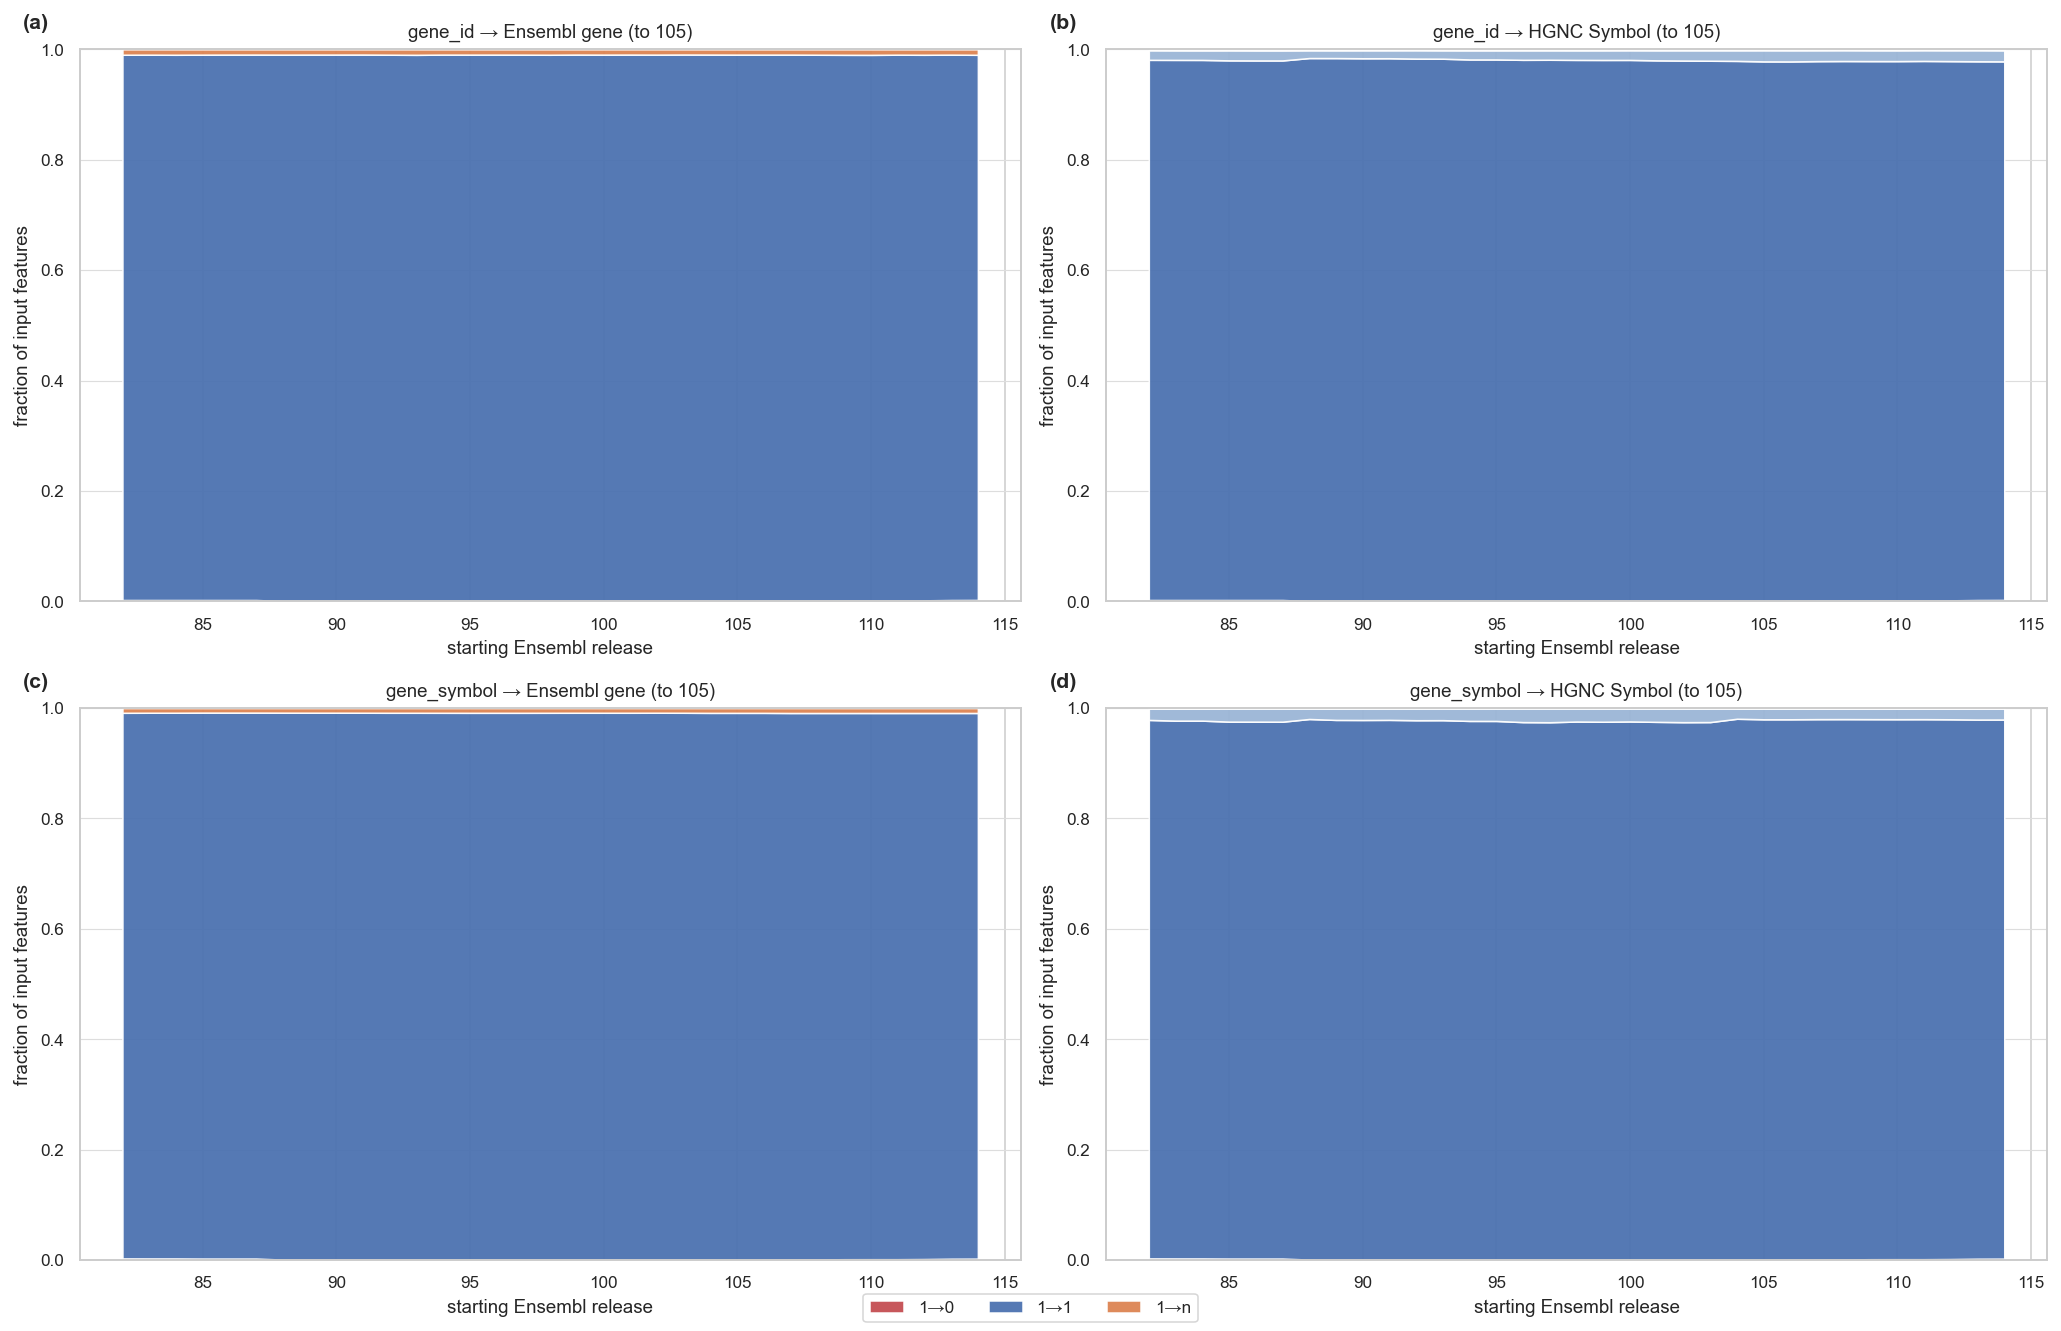

In [6]:
# -------------------- Figure: outcome profiles vs starting release (multi-panel) --------------------

combos = [
    ("gene_id", "Ensembl gene"),
    ("gene_id", "HGNC Symbol"),
    ("gene_symbol", "Ensembl gene"),
    ("gene_symbol", "HGNC Symbol"),
]

fig, axes = plt.subplots(2, 2, figsize=(14.6, 9.4), constrained_layout=True)
axes = axes.ravel()

for ax, (from_db, final_db) in zip(axes, combos, strict=False):
    sub = target_summary[(target_summary["from_database"] == from_db) & (target_summary["final_database"] == final_db)].copy()
    sub = sub.sort_values("from_release")
    if sub.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"Missing: {from_db} → {final_db}", ha="center", va="center")
        continue

    x = sub["from_release"].astype(int).values

    if final_db == "HGNC Symbol":
        layers = [
            ("1→0", sub["frac_1_to_0"].values),
            ("1→1 TDM", sub["frac_1_to_1_tdm"].values),
            ("1→1 ATM", sub["frac_1_to_1_atm"].values),
            ("1→n TDM", sub["frac_1_to_n_tdm"].values),
            ("1→n ATM", sub["frac_1_to_n_atm"].values),
        ]
        colors = [
            MANUSCRIPT_COLORS["1→0"],
            MANUSCRIPT_COLORS["1→1 TDM"],
            MANUSCRIPT_COLORS["1→1 ATM"],
            MANUSCRIPT_COLORS["1→n TDM"],
            MANUSCRIPT_COLORS["1→n ATM"],
        ]
    else:
        layers = [
            ("1→0", sub["frac_1_to_0"].values),
            ("1→1", sub["frac_1_to_1_total"].values),
            ("1→n", sub["frac_1_to_n_total"].values),
        ]
        colors = [MANUSCRIPT_COLORS["1→0"], MANUSCRIPT_COLORS["1→1"], MANUSCRIPT_COLORS["1→n"]]

    y = [v for _, v in layers]
    ax.stackplot(x, y, labels=[k for k, _ in layers], colors=colors, alpha=0.95)

    ax.set_title(f"{from_db} → {final_db} (to {TARGET_RELEASE})")
    ax.set_xlabel("starting Ensembl release")
    ax.set_ylabel("fraction of input features")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(5, max(1, len(labels))), frameon=True)
label_panels(axes)

written = save_figure(fig, f"fig_cellranger_idtrack_outcomes_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", written["pdf"])


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_diagnostics_to105.pdf


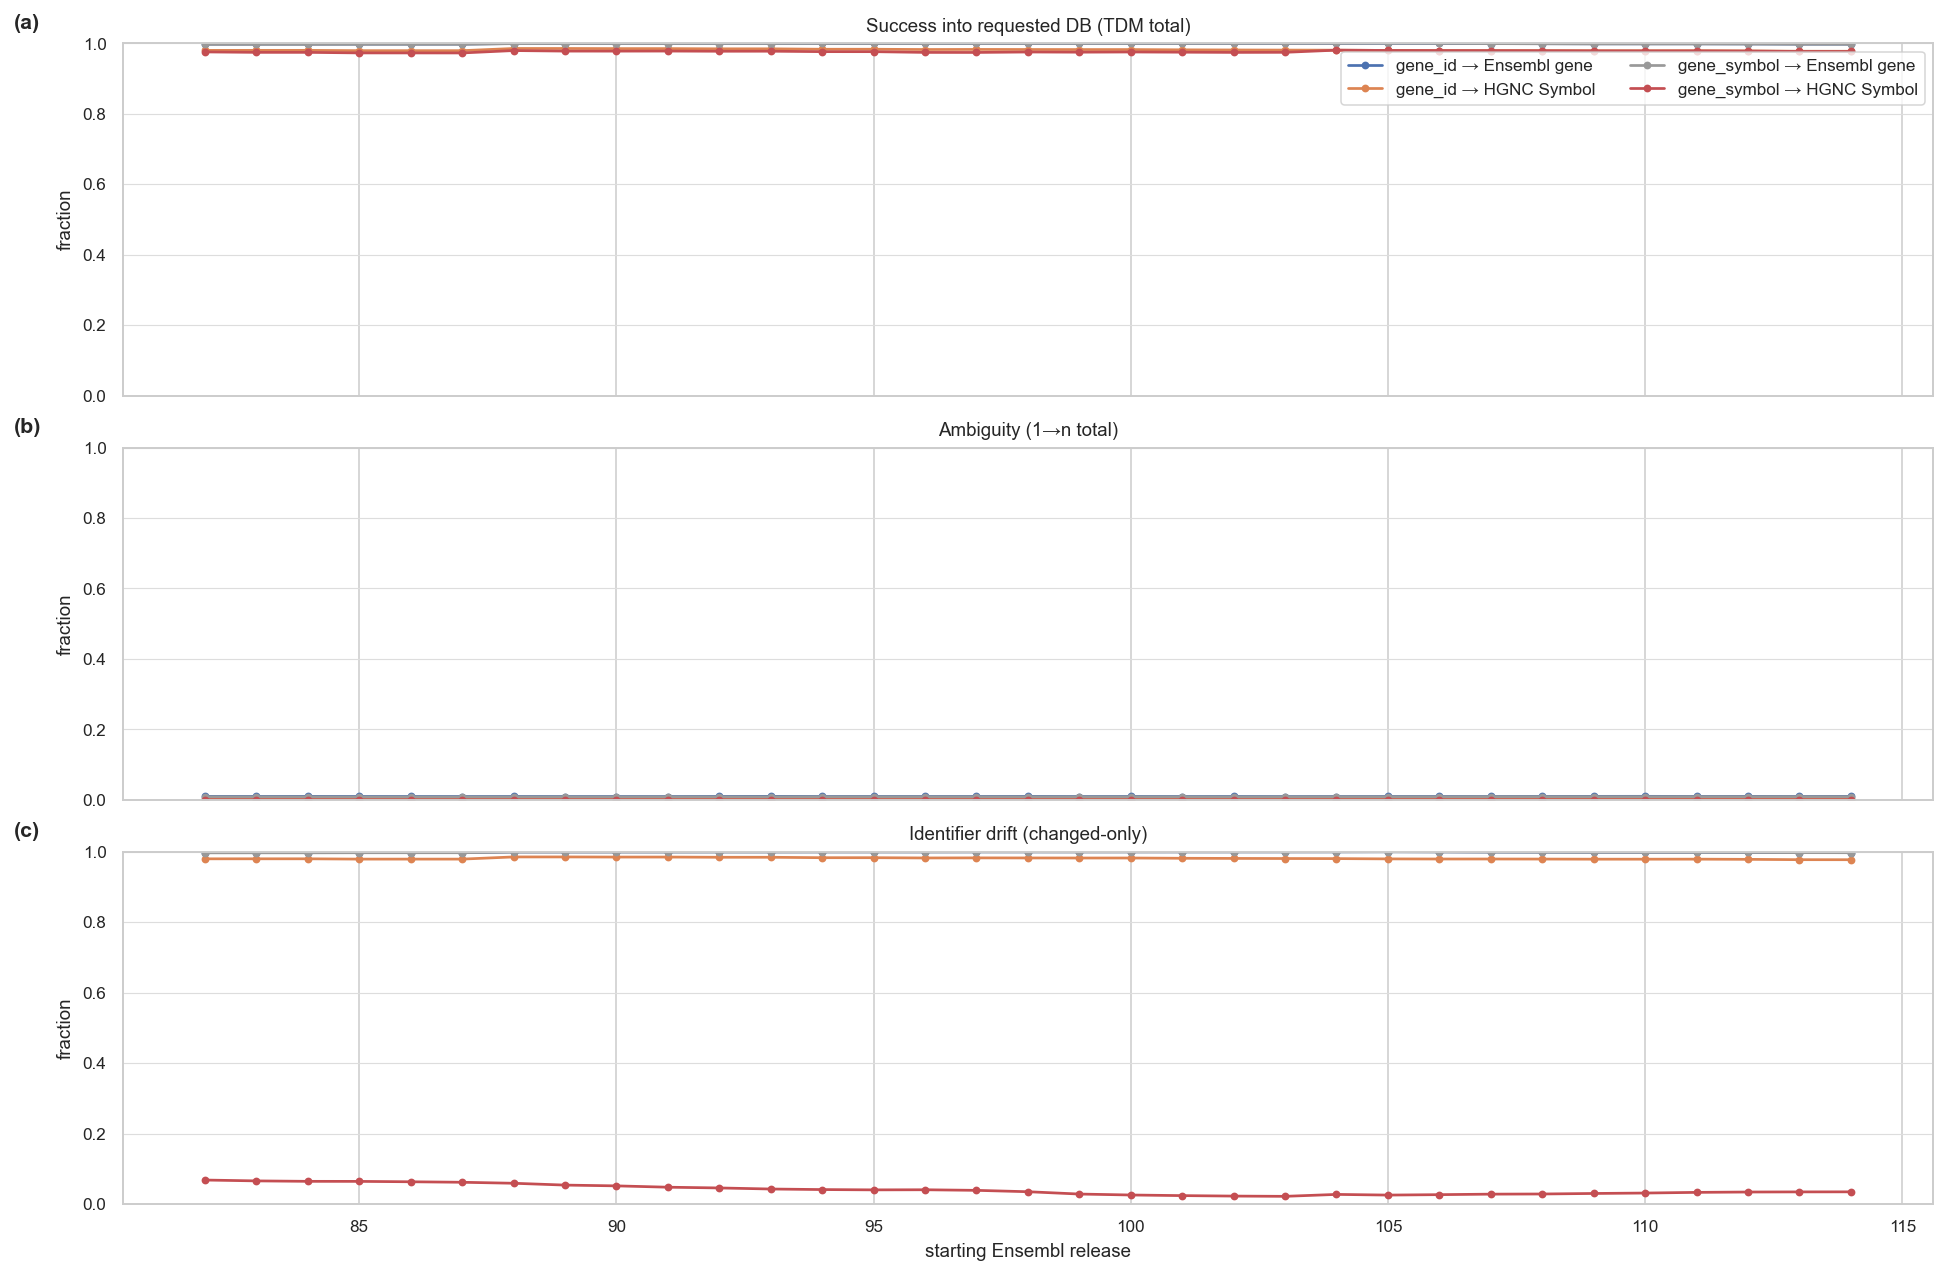

In [7]:
# -------------------- Figure: change + ambiguity diagnostics (marketing-facing) --------------------

metrics = [
    ("frac_tdm_total", "Success into requested DB (TDM total)", (0, 1)),
    ("frac_1_to_n_total", "Ambiguity (1→n total)", (0, 1)),
    ("frac_changed_any", "Identifier drift (changed-only)", (0, 1)),
]

fig2, axes2 = plt.subplots(len(metrics), 1, figsize=(13.8, 9.0), constrained_layout=True, sharex=True)
if len(metrics) == 1:
    axes2 = [axes2]

palette = {
    "gene_id → Ensembl gene": MANUSCRIPT_COLORS["1→1"],
    "gene_id → HGNC Symbol": MANUSCRIPT_COLORS["1→n"],
    "gene_symbol → Ensembl gene": MANUSCRIPT_COLORS["neutral"],
    "gene_symbol → HGNC Symbol": MANUSCRIPT_COLORS["1→0"],
}

for ax, (col, title, ylim) in zip(axes2, metrics, strict=False):
    for from_db, final_db in [("gene_id", "Ensembl gene"), ("gene_id", "HGNC Symbol"), ("gene_symbol", "Ensembl gene"), ("gene_symbol", "HGNC Symbol")]:
        sub = target_summary[(target_summary["from_database"] == from_db) & (target_summary["final_database"] == final_db)].sort_values("from_release")
        if sub.empty or col not in sub.columns:
            continue
        label = f"{from_db} → {final_db}"
        ax.plot(sub["from_release"], sub[col], "-o", ms=3, lw=1.4, label=label, color=palette.get(label))

    ax.set_title(title)
    ax.set_ylabel("fraction")
    ax.set_ylim(*ylim)
    ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

axes2[-1].set_xlabel("starting Ensembl release")
axes2[0].legend(frameon=True, ncol=2)
label_panels(axes2)

written2 = save_figure(fig2, f"fig_cellranger_idtrack_diagnostics_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", written2["pdf"])


## 5) Gold-standard comparison: expression + UMI retention (what breaks without time travel)

For each starting release, we compare it to the **gold-standard** dataset quantified at `TARGET_RELEASE`.

We compute:

- **Naive baseline** (without time travel): align by raw identifiers (`gene_id` or `gene_symbol`) using exact-match joins.
- **IDTrack time travel**: map each starting release into the `TARGET_RELEASE` boundary and (optionally) project to `HGNC Symbol`.



In [8]:
def _pseudobulk_cache_path(*, dataset: str, assembly: str, release: int) -> Path:
    stem = safe_tag(f"pseudobulk_{dataset}_{assembly}_{release}")
    return CACHE_DIR / f"{stem}.pickle"


def _mapped_pseudobulk_cache_path(
    *,
    dataset: str,
    assembly: str,
    from_release: int,
    to_release: int,
    from_database: str,
    to_database: str,
    strategy: str,
) -> Path:
    stem = safe_tag(
        f"mapped_pseudobulk_{dataset}_{assembly}_from{from_release}_to{to_release}_{from_database}__{to_database}__{strategy}"
    )
    return CACHE_DIR / f"{stem}.pickle"


def get_pseudobulk(release: int) -> dict:
    """Cache: per-feature totals + var columns."""

    def _compute():
        path = release_to_h5ad.get(int(release))
        if path is None or not path.exists():
            raise FileNotFoundError(f"Missing h5ad for release={release}")
        totals, var = feature_totals_from_h5ad(path)
        return {"release": int(release), "totals": totals, "var": var}

    return cache_pickle_or_compute(
        _pseudobulk_cache_path(dataset=DATASET_SEL, assembly=ASSEMBLY_SEL, release=int(release)),
        _compute,
        force=False,
    )


def mapped_pseudobulk(
    *,
    from_release: int,
    from_database: str,
    to_database: str,
    strategy: str,
) -> tuple[pd.Series, dict[str, np.ndarray]]:
    """Return (mapped pseudo-bulk Series, debug masks).

    Results are cached because they are reused across multiple figures/tables.
    """

    cache_pkl = _mapped_pseudobulk_cache_path(
        dataset=DATASET_SEL,
        assembly=ASSEMBLY_SEL,
        from_release=int(from_release),
        to_release=int(TARGET_RELEASE),
        from_database=str(from_database),
        to_database=str(to_database),
        strategy=str(strategy),
    )

    def _compute():
        pb = get_pseudobulk(int(from_release))
        totals = pb["totals"]
        var = pb["var"]

        if from_database not in var.columns:
            raise KeyError(f"Column {from_database!r} not in adata.var for release={from_release}.")

        matchings = load_matchings(
            runs_sel,
            dataset=DATASET_SEL,
            assembly=ASSEMBLY_SEL,
            from_release=int(from_release),
            from_database=str(from_database),
            to_database=str(to_database),
            to_release=int(TARGET_RELEASE),
        )
        if matchings is None:
            raise FileNotFoundError(
                f"Missing matchings for from_release={from_release} {from_database}→{to_database} to_release={TARGET_RELEASE}"
            )

        if len(matchings) != len(totals):
            raise ValueError(
                f"Length mismatch: matchings={len(matchings)} vs n_features={len(totals)} for release={from_release}."
            )

        M, target_ids, debug = build_mapping_matrix(matchings, strategy=strategy)
        mapped = M.T.dot(totals)
        s = pd.Series(np.asarray(mapped).ravel(), index=pd.Index(target_ids, name="target_id"), dtype=float)
        s = s.groupby(level=0).sum()

        return {"series": s, "debug": debug}

    payload = cache_pickle_or_compute(cache_pkl, _compute, force=FORCE_REBUILD)
    if not isinstance(payload, dict) or "series" not in payload or "debug" not in payload:
        raise TypeError(f"Unexpected mapped_pseudobulk cache payload in {cache_pkl}")

    return payload["series"], payload["debug"]


def raw_pseudobulk(*, from_release: int, from_database: str) -> pd.Series:
    pb = get_pseudobulk(int(from_release))
    totals = pb["totals"]
    var = pb["var"]
    if from_database not in var.columns:
        raise KeyError(f"Column {from_database!r} not in adata.var for release={from_release}.")

    ids = var[from_database].astype(str).tolist()
    normalize = "gene_id" if from_database == "gene_id" else "gene_symbol"
    return series_from_ids_and_totals(ids, totals, normalize=normalize)


def compute_gold_standard_metrics() -> pd.DataFrame:
    rows = []

    raw_target = {from_db: raw_pseudobulk(from_release=TARGET_RELEASE, from_database=from_db) for from_db in FROM_DATABASES}

    mapped_target = {}
    for from_db in FROM_DATABASES:
        for to_db in TO_DATABASES:
            for strategy in MAPPING_STRATEGIES:
                key = (from_db, to_db, strategy)
                mapped_target[key] = mapped_pseudobulk(
                    from_release=TARGET_RELEASE,
                    from_database=from_db,
                    to_database=to_db,
                    strategy=strategy,
                )[0]

    for from_release in releases:
        for from_db in FROM_DATABASES:
            raw_src = raw_pseudobulk(from_release=int(from_release), from_database=from_db)
            raw_tgt = raw_target[from_db]

            common_raw = sorted(set(raw_src.index) & set(raw_tgt.index))
            a_raw = raw_src.reindex(common_raw).astype(float)
            b_raw = raw_tgt.reindex(common_raw).astype(float)

            rows.append(
                {
                    "from_release": int(from_release),
                    "to_release": int(TARGET_RELEASE),
                    "abs_delta": int(abs(int(TARGET_RELEASE) - int(from_release))),
                    "from_database": from_db,
                    "final_database": "(raw)",
                    "strategy": "raw_exact_join",
                    "n_common": int(len(common_raw)),
                    "jaccard": float(jaccard_similarity(set(raw_src.index), set(raw_tgt.index))),
                    "corr_pearson_log1p": pearsonr_log1p(a_raw, b_raw),
                    "corr_spearman_log1p": spearmanr_log1p(a_raw, b_raw),
                    "total_umis": float(raw_src.sum()),
                    "umis_in_common": float(a_raw.sum()),
                    "frac_umis_in_common": float(a_raw.sum() / raw_src.sum()) if raw_src.sum() else float("nan"),
                }
            )

            for to_db in TO_DATABASES:
                for strategy in MAPPING_STRATEGIES:
                    src_m, dbg = mapped_pseudobulk(
                        from_release=int(from_release),
                        from_database=from_db,
                        to_database=to_db,
                        strategy=strategy,
                    )
                    tgt_m = mapped_target[(from_db, to_db, strategy)]

                    common = sorted(set(src_m.index) & set(tgt_m.index))
                    a = src_m.reindex(common).astype(float)
                    b = tgt_m.reindex(common).astype(float)

                    total_umis = float(raw_src.sum())
                    frac_retained = float(src_m.sum() / total_umis) if total_umis else float("nan")
                    frac_comparable = float(a.sum() / total_umis) if total_umis else float("nan")

                    rows.append(
                        {
                            "from_release": int(from_release),
                            "to_release": int(TARGET_RELEASE),
                            "abs_delta": int(abs(int(TARGET_RELEASE) - int(from_release))),
                            "from_database": from_db,
                            "final_database": _canonical_final_db(to_db),
                            "strategy": strategy,
                            "n_common": int(len(common)),
                            "jaccard": float(jaccard_similarity(set(src_m.index), set(tgt_m.index))),
                            "corr_pearson_log1p": pearsonr_log1p(a, b),
                            "corr_spearman_log1p": spearmanr_log1p(a, b),
                            "total_umis": total_umis,
                            "umis_retained": float(src_m.sum()),
                            "frac_umis_retained": frac_retained,
                            "umis_in_common": float(a.sum()),
                            "frac_umis_in_common": frac_comparable,
                            "frac_1_to_0_genes": float(dbg["is_1_to_0"].mean()),
                            "frac_1_to_n_genes": float(dbg["is_1_to_n"].mean()),
                            "frac_atm_genes": float(dbg["is_atm"].mean()),
                        }
                    )

    df = pd.DataFrame(rows)
    return df.sort_values(["from_database", "final_database", "strategy", "from_release"]).reset_index(drop=True)


metrics_pkl = CACHE_DIR / safe_tag(f"gold_standard_metrics_{DATASET_SEL}_{ASSEMBLY_SEL}_to{TARGET_RELEASE}")
metrics_pkl = metrics_pkl.with_suffix(".pickle")

gold_metrics = cache_pickle_or_compute(metrics_pkl, compute_gold_standard_metrics, force=FORCE_REBUILD)

out_metrics_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_gold_standard_metrics_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(gold_metrics, out_metrics_csv, index=False)
atomic_write_dataframe_csv(gold_metrics, ctx.experiment_outputs / "tables" / out_metrics_csv.name, index=False)
print("Wrote:", out_metrics_csv)

gold_metrics.head(14)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_gold_standard_metrics_to105.csv


,from_release,to_release,abs_delta,from_database,final_database,strategy,n_common,jaccard,corr_pearson_log1p,corr_spearman_log1p,total_umis,umis_in_common,frac_umis_in_common,umis_retained,frac_umis_retained,frac_1_to_0_genes,frac_1_to_n_genes,frac_atm_genes
0,82,105,23,gene_id,(raw),raw_exact_join,19348,0.946205,0.991311,0.991472,12985190.0,12959585.0,0.998028,NaN,NaN,NaN,NaN,NaN
1,83,105,22,gene_id,(raw),raw_exact_join,19371,0.947562,0.991855,0.991918,12984924.0,12964890.0,0.998457,NaN,NaN,NaN,NaN,NaN
2,84,105,21,gene_id,(raw),raw_exact_join,19371,0.947562,0.991855,0.991918,12984924.0,12964890.0,0.998457,NaN,NaN,NaN,NaN,NaN
3,85,105,20,gene_id,(raw),raw_exact_join,19507,0.954261,0.992256,0.992352,12962262.0,12941666.0,0.998411,NaN,NaN,NaN,NaN,NaN
4,86,105,19,gene_id,(raw),raw_exact_join,19507,0.954261,0.992256,0.992352,12962262.0,12941666.0,0.998411,NaN,NaN,NaN,NaN,NaN
5,87,105,18,gene_id,(raw),raw_exact_join,19507,0.954261,0.992256,0.992352,12962262.0,12941666.0,0.998411,NaN,NaN,NaN,NaN,NaN
6,88,105,17,gene_id,(raw),raw_exact_join,19596,0.969139,0.992927,0.993052,13003091.0,12987990.0,0.998839,NaN,NaN,NaN,NaN,NaN
7,89,105,16,gene_id,(raw),raw_exact_join,19596,0.969139,0.992927,0.993052,13003091.0,12987990.0,0.998839,NaN,NaN,NaN,NaN,NaN
8,90,105,15,gene_id,(raw),raw_exact_join,19620,0.970566,0.993204,0.993345,13004495.0,12990622.0,0.998933,NaN,NaN,NaN,NaN,NaN
9,91,105,14,gene_id,(raw),raw_exact_join,19620,0.970566,0.993204,0.993345,13004495.0,12990622.0,0.998933,NaN,NaN,NaN,NaN,NaN


### 5b) UMI-weighted outcome profiles (why mapping errors matter at dataset scale)

Outcome profiles are usually reported per identifier (gene count). For single-cell, the *UMI-weighted* view is often more important: a small fraction of “problematic” genes can still carry meaningful signal.

This section computes outcome profiles into `TARGET_RELEASE`, but weighted by pseudo-bulk UMIs per feature.


In [9]:
def compute_umi_weighted_outcomes_to_target() -> pd.DataFrame:
    rows = []

    for from_release in releases:
        pb = get_pseudobulk(int(from_release))
        totals = pb["totals"]
        total_umi = float(np.asarray(totals).sum())

        for from_db in FROM_DATABASES:
            for to_db in TO_DATABASES:
                matchings = load_matchings(
                    runs_sel,
                    dataset=DATASET_SEL,
                    assembly=ASSEMBLY_SEL,
                    from_release=int(from_release),
                    from_database=str(from_db),
                    to_database=str(to_db),
                    to_release=int(TARGET_RELEASE),
                )
                if matchings is None:
                    continue

                _, _, dbg = build_mapping_matrix(matchings, strategy="best")

                is_1_to_0 = dbg["is_1_to_0"]
                is_1_to_1 = dbg["is_1_to_1"]
                is_1_to_n = dbg["is_1_to_n"]
                is_atm = dbg["is_atm"]

                def _sum(mask: np.ndarray) -> float:
                    return float(np.asarray(totals[mask]).sum()) if mask.any() else 0.0

                umi_1_to_0 = _sum(is_1_to_0)
                umi_1_to_1_tdm = _sum(is_1_to_1 & (~is_atm))
                umi_1_to_1_atm = _sum(is_1_to_1 & is_atm)
                umi_1_to_n_tdm = _sum(is_1_to_n & (~is_atm))
                umi_1_to_n_atm = _sum(is_1_to_n & is_atm)

                rows.append(
                    {
                        "dataset": DATASET_SEL,
                        "assembly": ASSEMBLY_SEL,
                        "from_release": int(from_release),
                        "to_release": int(TARGET_RELEASE),
                        "from_database": str(from_db),
                        "final_database": _canonical_final_db(to_db),
                        "total_umis": total_umi,
                        "umi_1_to_0": umi_1_to_0,
                        "umi_1_to_1_tdm": umi_1_to_1_tdm,
                        "umi_1_to_1_atm": umi_1_to_1_atm,
                        "umi_1_to_n_tdm": umi_1_to_n_tdm,
                        "umi_1_to_n_atm": umi_1_to_n_atm,
                    }
                )

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No UMI-weighted outcome rows produced.")

    den = df["total_umis"].replace(0, np.nan)
    df["frac_umi_1_to_0"] = df["umi_1_to_0"] / den
    df["frac_umi_1_to_1_tdm"] = df["umi_1_to_1_tdm"] / den
    df["frac_umi_1_to_1_atm"] = df["umi_1_to_1_atm"] / den
    df["frac_umi_1_to_n_tdm"] = df["umi_1_to_n_tdm"] / den
    df["frac_umi_1_to_n_atm"] = df["umi_1_to_n_atm"] / den

    df["frac_umi_1_to_1_total"] = df["frac_umi_1_to_1_tdm"] + df["frac_umi_1_to_1_atm"]
    df["frac_umi_1_to_n_total"] = df["frac_umi_1_to_n_tdm"] + df["frac_umi_1_to_n_atm"]
    return df.sort_values(["from_database", "final_database", "from_release"]).reset_index(drop=True)


umi_out_pkl = CACHE_DIR / safe_tag(f"umi_weighted_outcomes_{DATASET_SEL}_{ASSEMBLY_SEL}_to{TARGET_RELEASE}")
umi_out_pkl = umi_out_pkl.with_suffix(".pickle")

umi_outcomes = cache_pickle_or_compute(umi_out_pkl, compute_umi_weighted_outcomes_to_target, force=FORCE_REBUILD)

out_umi_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_target_release_umi_weighted_outcomes_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(umi_outcomes, out_umi_csv, index=False)
atomic_write_dataframe_csv(umi_outcomes, ctx.experiment_outputs / "tables" / out_umi_csv.name, index=False)
print("Wrote:", out_umi_csv)

umi_outcomes.head(8)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_target_release_umi_weighted_outcomes_to105.csv


,dataset,assembly,from_release,to_release,from_database,final_database,total_umis,umi_1_to_0,umi_1_to_1_tdm,umi_1_to_1_atm,umi_1_to_n_tdm,umi_1_to_n_atm,frac_umi_1_to_0,frac_umi_1_to_1_tdm,frac_umi_1_to_1_atm,frac_umi_1_to_n_tdm,frac_umi_1_to_n_atm,frac_umi_1_to_1_total,frac_umi_1_to_n_total
0,pbmc_1k_v3,GRCh38,82,105,gene_id,Ensembl gene,12985190.0,272.0,12686071.0,0.0,298847.0,0.0,0.000021,0.976965,0.0,0.023014,0.0,0.976965,0.023014
1,pbmc_1k_v3,GRCh38,83,105,gene_id,Ensembl gene,12984924.0,272.0,12687390.0,0.0,297262.0,0.0,0.000021,0.977086,0.0,0.022893,0.0,0.977086,0.022893
2,pbmc_1k_v3,GRCh38,84,105,gene_id,Ensembl gene,12984924.0,272.0,12687391.0,0.0,297261.0,0.0,0.000021,0.977086,0.0,0.022893,0.0,0.977086,0.022893
3,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,12962262.0,272.0,12663554.0,0.0,298436.0,0.0,0.000021,0.976956,0.0,0.023023,0.0,0.976956,0.023023
4,pbmc_1k_v3,GRCh38,86,105,gene_id,Ensembl gene,12962262.0,272.0,12664970.0,0.0,297020.0,0.0,0.000021,0.977065,0.0,0.022914,0.0,0.977065,0.022914
5,pbmc_1k_v3,GRCh38,87,105,gene_id,Ensembl gene,12962262.0,272.0,12664931.0,0.0,297059.0,0.0,0.000021,0.977062,0.0,0.022917,0.0,0.977062,0.022917
6,pbmc_1k_v3,GRCh38,88,105,gene_id,Ensembl gene,13003091.0,267.0,12703945.0,0.0,298879.0,0.0,0.000021,0.976994,0.0,0.022985,0.0,0.976994,0.022985
7,pbmc_1k_v3,GRCh38,89,105,gene_id,Ensembl gene,13003091.0,267.0,12705349.0,0.0,297475.0,0.0,0.000021,0.977102,0.0,0.022877,0.0,0.977102,0.022877


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_outcomes_umi_weighted_to105.pdf


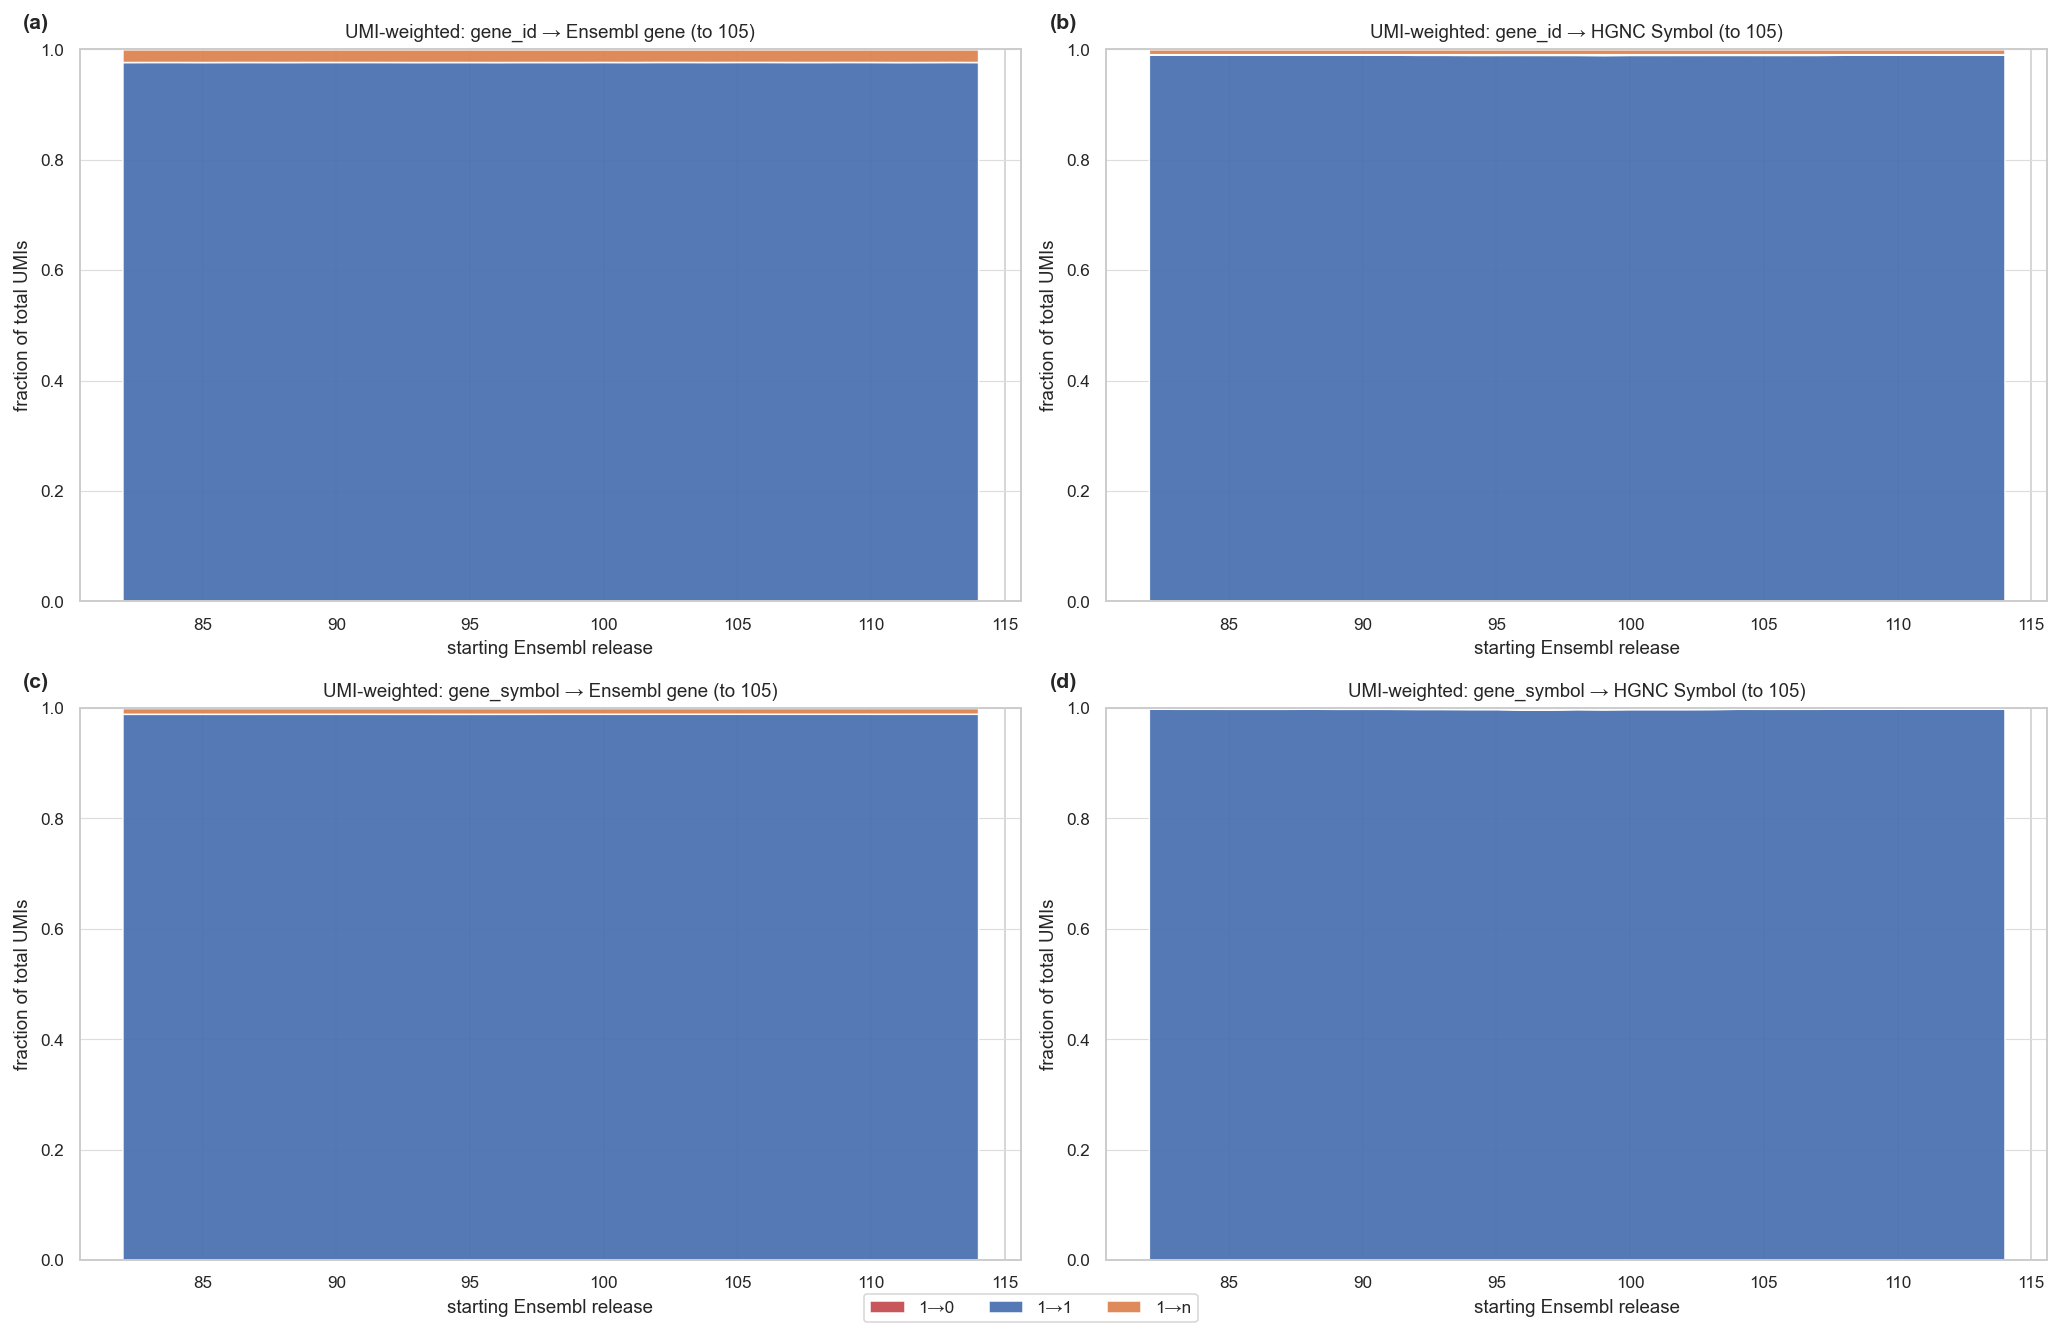

In [10]:
# Figure: UMI-weighted outcome profiles vs starting release

combos = [
    ("gene_id", "Ensembl gene"),
    ("gene_id", "HGNC Symbol"),
    ("gene_symbol", "Ensembl gene"),
    ("gene_symbol", "HGNC Symbol"),
]

figU, axesU = plt.subplots(2, 2, figsize=(14.6, 9.4), constrained_layout=True)
axesU = axesU.ravel()

for ax, (from_db, final_db) in zip(axesU, combos, strict=False):
    sub = umi_outcomes[(umi_outcomes["from_database"] == from_db) & (umi_outcomes["final_database"] == final_db)].copy()
    sub = sub.sort_values("from_release")
    if sub.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"Missing: {from_db} → {final_db}", ha="center", va="center")
        continue

    x = sub["from_release"].astype(int).values

    if final_db == "HGNC Symbol":
        layers = [
            ("1→0", sub["frac_umi_1_to_0"].values),
            ("1→1 TDM", sub["frac_umi_1_to_1_tdm"].values),
            ("1→1 ATM", sub["frac_umi_1_to_1_atm"].values),
            ("1→n TDM", sub["frac_umi_1_to_n_tdm"].values),
            ("1→n ATM", sub["frac_umi_1_to_n_atm"].values),
        ]
        colors = [
            MANUSCRIPT_COLORS["1→0"],
            MANUSCRIPT_COLORS["1→1 TDM"],
            MANUSCRIPT_COLORS["1→1 ATM"],
            MANUSCRIPT_COLORS["1→n TDM"],
            MANUSCRIPT_COLORS["1→n ATM"],
        ]
    else:
        layers = [
            ("1→0", sub["frac_umi_1_to_0"].values),
            ("1→1", sub["frac_umi_1_to_1_total"].values),
            ("1→n", sub["frac_umi_1_to_n_total"].values),
        ]
        colors = [MANUSCRIPT_COLORS["1→0"], MANUSCRIPT_COLORS["1→1"], MANUSCRIPT_COLORS["1→n"]]

    ax.stackplot(x, [v for _, v in layers], labels=[k for k, _ in layers], colors=colors, alpha=0.95)
    ax.set_title(f"UMI-weighted: {from_db} → {final_db} (to {TARGET_RELEASE})")
    ax.set_xlabel("starting Ensembl release")
    ax.set_ylabel("fraction of total UMIs")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

handles, labels = axesU[0].get_legend_handles_labels()
figU.legend(handles, labels, loc="lower center", ncol=min(5, max(1, len(labels))), frameon=True)
label_panels(axesU)

writtenU = save_figure(figU, f"fig_cellranger_idtrack_outcomes_umi_weighted_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", writtenU["pdf"])


### 5c) HGNC projection completeness (conditional on a stable Ensembl backbone)

A common workflow is:

1. time-travel *everything* into a fixed Ensembl release (backbone)
2. project into a preferred external namespace (e.g. HGNC)

This section quantifies, for each starting release:

- among genes that can be time-travelled on the Ensembl backbone, what fraction can be labeled in HGNC as a **true match** (TDM) vs requiring **fallback** (ATM) vs missing.

We report both gene-level fractions and UMI-weighted fractions.


In [11]:
def compute_hgnc_coverage_given_ensembl_success() -> pd.DataFrame:
    rows = []

    for from_release in releases:
        pb = get_pseudobulk(int(from_release))
        totals = pb["totals"]

        for from_db in FROM_DATABASES:
            ens = load_matchings(
                runs_sel,
                dataset=DATASET_SEL,
                assembly=ASSEMBLY_SEL,
                from_release=int(from_release),
                from_database=str(from_db),
                to_database="ensembl_gene",
                to_release=int(TARGET_RELEASE),
            )
            hgnc = load_matchings(
                runs_sel,
                dataset=DATASET_SEL,
                assembly=ASSEMBLY_SEL,
                from_release=int(from_release),
                from_database=str(from_db),
                to_database="HGNC Symbol",
                to_release=int(TARGET_RELEASE),
            )
            if ens is None or hgnc is None:
                continue

            # Use 'best' purely to get consistent masks; masks are independent of strategy for 1→0/1→n.
            _, _, dbg_ens = build_mapping_matrix(ens, strategy="best")
            _, _, dbg_hgnc = build_mapping_matrix(hgnc, strategy="best")

            ens_success = ~dbg_ens["is_1_to_0"]
            if not ens_success.any():
                continue

            hgnc_tdm = dbg_hgnc["has_mapping"] & (~dbg_hgnc["is_atm"])
            hgnc_atm = dbg_hgnc["has_mapping"] & dbg_hgnc["is_atm"]
            hgnc_missing = dbg_hgnc["is_1_to_0"]

            den_genes = float(ens_success.sum())
            den_umis = float(np.asarray(totals[ens_success]).sum())

            def _frac_gen(mask: np.ndarray) -> float:
                return float(mask[ens_success].mean())

            def _frac_umi(mask: np.ndarray) -> float:
                if den_umis <= 0:
                    return float("nan")
                return float(np.asarray(totals[ens_success & mask]).sum()) / den_umis

            rows.append(
                {
                    "dataset": DATASET_SEL,
                    "assembly": ASSEMBLY_SEL,
                    "from_release": int(from_release),
                    "to_release": int(TARGET_RELEASE),
                    "from_database": str(from_db),
                    "n_ens_success_genes": int(den_genes),
                    "frac_hgnc_tdm_given_ens_success": _frac_gen(hgnc_tdm),
                    "frac_hgnc_atm_given_ens_success": _frac_gen(hgnc_atm),
                    "frac_hgnc_missing_given_ens_success": _frac_gen(hgnc_missing),
                    "frac_umi_hgnc_tdm_given_ens_success": _frac_umi(hgnc_tdm),
                    "frac_umi_hgnc_atm_given_ens_success": _frac_umi(hgnc_atm),
                    "frac_umi_hgnc_missing_given_ens_success": _frac_umi(hgnc_missing),
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No HGNC conditional coverage rows produced.")
    return df.sort_values(["from_database", "from_release"]).reset_index(drop=True)


hgnc_cov_pkl = CACHE_DIR / safe_tag(f"hgnc_coverage_given_ensembl_success_{DATASET_SEL}_{ASSEMBLY_SEL}_to{TARGET_RELEASE}")
hgnc_cov_pkl = hgnc_cov_pkl.with_suffix(".pickle")

hgnc_cov = cache_pickle_or_compute(hgnc_cov_pkl, compute_hgnc_coverage_given_ensembl_success, force=FORCE_REBUILD)

out_cov_csv = MANUSCRIPT_TABLES / f"cellranger_hgnc_coverage_given_ensembl_success_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(hgnc_cov, out_cov_csv, index=False)
atomic_write_dataframe_csv(hgnc_cov, ctx.experiment_outputs / "tables" / out_cov_csv.name, index=False)
print("Wrote:", out_cov_csv)

hgnc_cov.head(8)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_hgnc_coverage_given_ensembl_success_to105.csv


,dataset,assembly,from_release,to_release,from_database,n_ens_success_genes,frac_hgnc_tdm_given_ens_success,frac_hgnc_atm_given_ens_success,frac_hgnc_missing_given_ens_success,frac_umi_hgnc_tdm_given_ens_success,frac_umi_hgnc_atm_given_ens_success,frac_umi_hgnc_missing_given_ens_success
0,pbmc_1k_v3,GRCh38,82,105,gene_id,19760,0.982338,0.017662,0.0,0.999106,0.000894,0.0
1,pbmc_1k_v3,GRCh38,83,105,gene_id,19778,0.982405,0.017595,0.0,0.999099,0.000901,0.0
2,pbmc_1k_v3,GRCh38,84,105,gene_id,19778,0.982405,0.017595,0.0,0.999099,0.000901,0.0
3,pbmc_1k_v3,GRCh38,85,105,gene_id,19913,0.981520,0.018480,0.0,0.999066,0.000934,0.0
4,pbmc_1k_v3,GRCh38,86,105,gene_id,19913,0.981520,0.018480,0.0,0.999066,0.000934,0.0
5,pbmc_1k_v3,GRCh38,87,105,gene_id,19913,0.981520,0.018480,0.0,0.999066,0.000934,0.0
6,pbmc_1k_v3,GRCh38,88,105,gene_id,19817,0.985871,0.014129,0.0,0.999089,0.000911,0.0
7,pbmc_1k_v3,GRCh38,89,105,gene_id,19817,0.985871,0.014129,0.0,0.999089,0.000911,0.0


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_hgnc_coverage_given_ensembl_success_to105.pdf


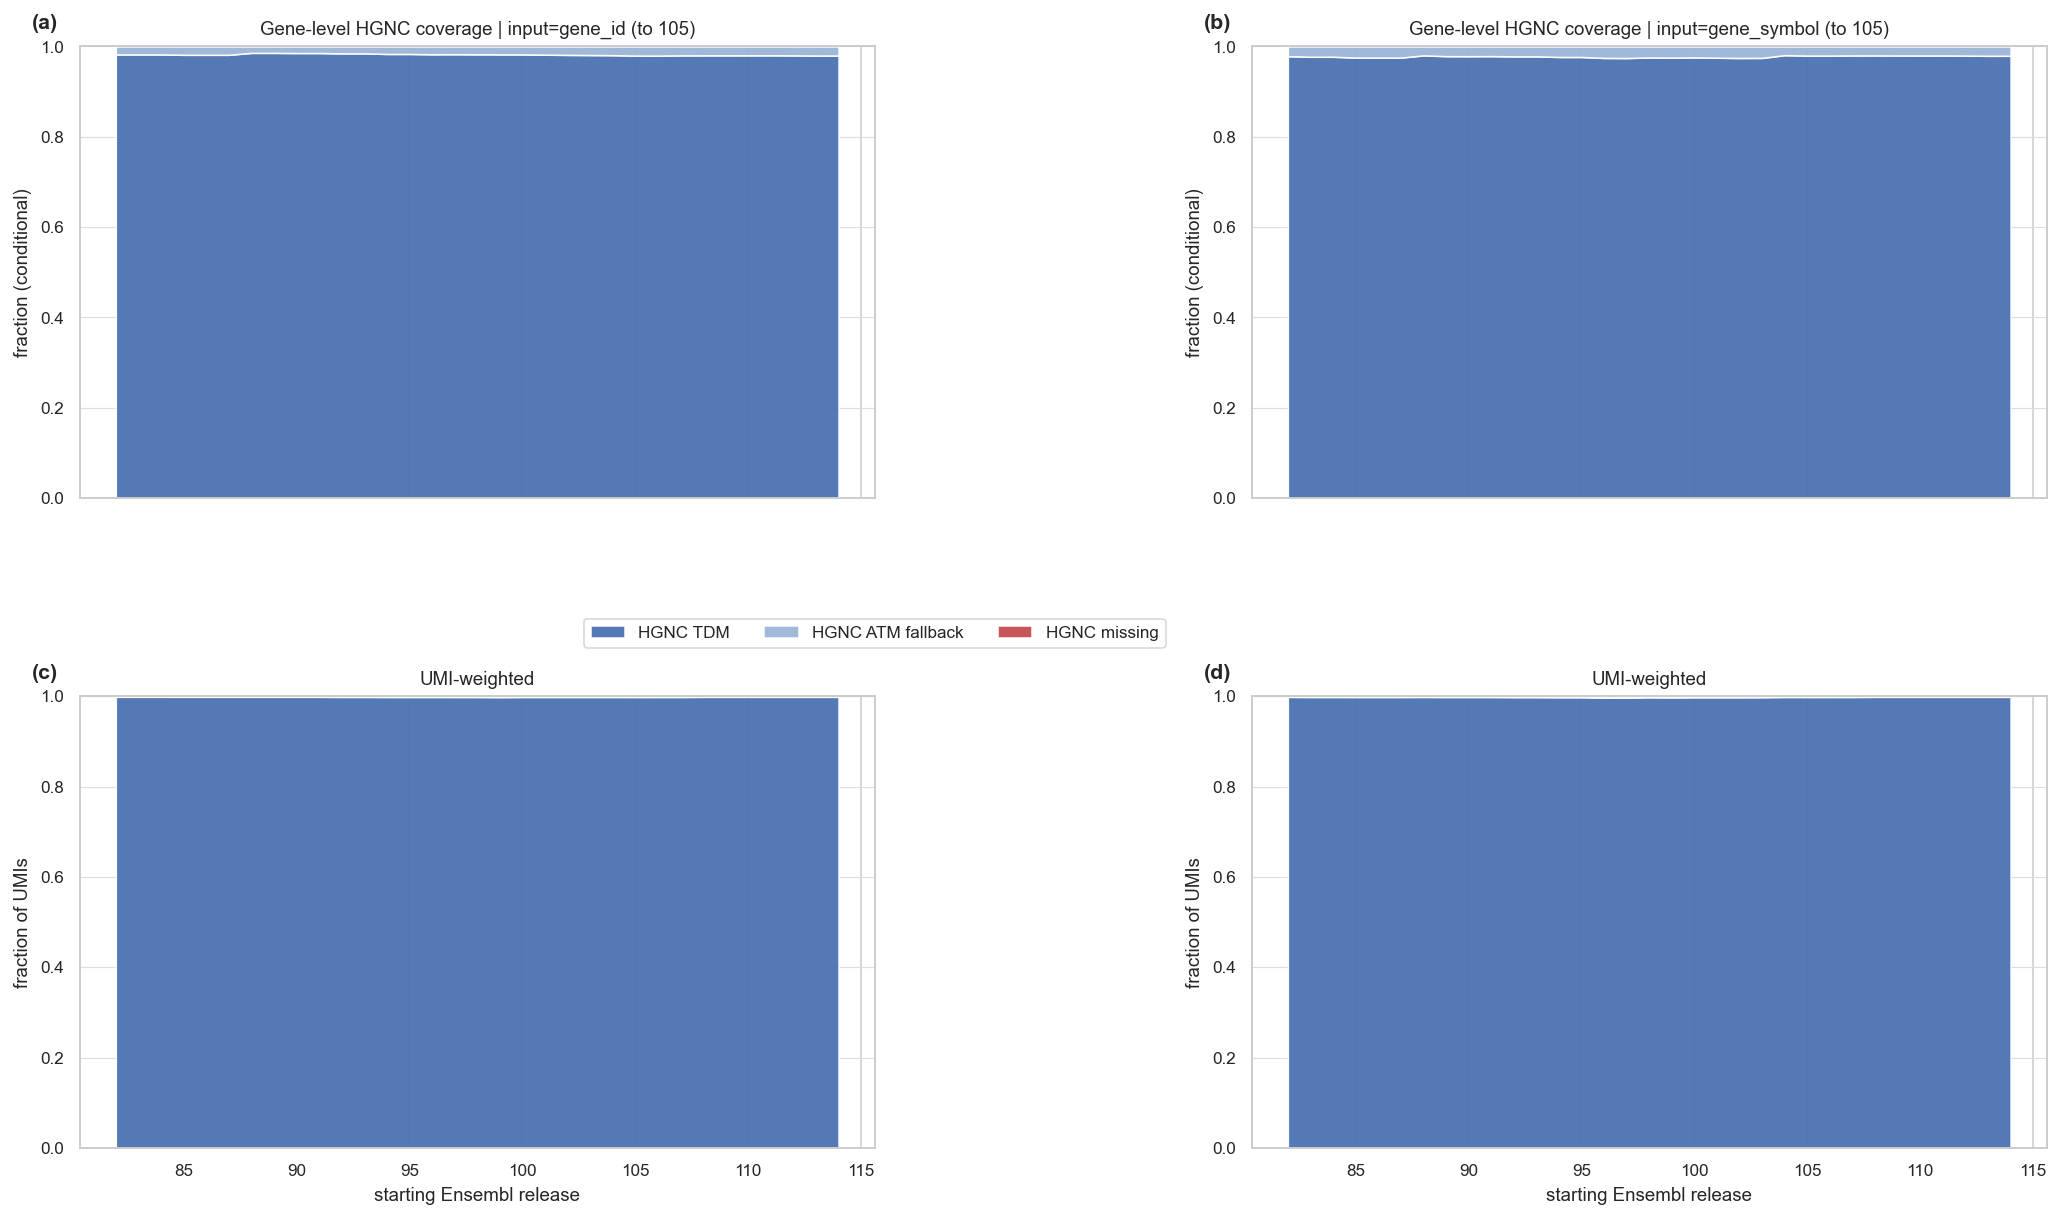

In [12]:
# Figure: HGNC projection completeness over time (gene-level + UMI-weighted)

figC, axesC = plt.subplots(2, 2, figsize=(14.6, 8.6), constrained_layout=True, sharex=True)

for col_idx, from_db in enumerate(FROM_DATABASES):
    sub = hgnc_cov[hgnc_cov["from_database"] == from_db].sort_values("from_release")

    ax0 = axesC[0, col_idx]
    ax1 = axesC[1, col_idx]

    if sub.empty:
        ax0.axis("off")
        ax1.axis("off")
        continue

    x = sub["from_release"].astype(int).values

    # gene-level stacked area
    ax0.stackplot(
        x,
        [
            sub["frac_hgnc_tdm_given_ens_success"].values,
            sub["frac_hgnc_atm_given_ens_success"].values,
            sub["frac_hgnc_missing_given_ens_success"].values,
        ],
        labels=["HGNC TDM", "HGNC ATM fallback", "HGNC missing"],
        colors=[MANUSCRIPT_COLORS["1→1 TDM"], MANUSCRIPT_COLORS["1→1 ATM"], MANUSCRIPT_COLORS["1→0"]],
        alpha=0.95,
    )
    ax0.set_ylim(0, 1)
    ax0.set_title(f"Gene-level HGNC coverage | input={from_db} (to {TARGET_RELEASE})")
    ax0.set_ylabel("fraction (conditional)")
    ax0.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

    # UMI-weighted stacked area
    ax1.stackplot(
        x,
        [
            sub["frac_umi_hgnc_tdm_given_ens_success"].values,
            sub["frac_umi_hgnc_atm_given_ens_success"].values,
            sub["frac_umi_hgnc_missing_given_ens_success"].values,
        ],
        labels=["HGNC TDM", "HGNC ATM fallback", "HGNC missing"],
        colors=[MANUSCRIPT_COLORS["1→1 TDM"], MANUSCRIPT_COLORS["1→1 ATM"], MANUSCRIPT_COLORS["1→0"]],
        alpha=0.95,
    )
    ax1.set_ylim(0, 1)
    ax1.set_title("UMI-weighted")
    ax1.set_xlabel("starting Ensembl release")
    ax1.set_ylabel("fraction of UMIs")
    ax1.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

axesC[0, 0].legend(frameon=True, ncol=3, loc="lower center", bbox_to_anchor=(1.0, -0.35))
label_panels(axesC.ravel())
writtenC = save_figure(figC, f"fig_cellranger_hgnc_coverage_given_ensembl_success_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", writtenC["pdf"])


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_gold_standard_gain_to105.pdf


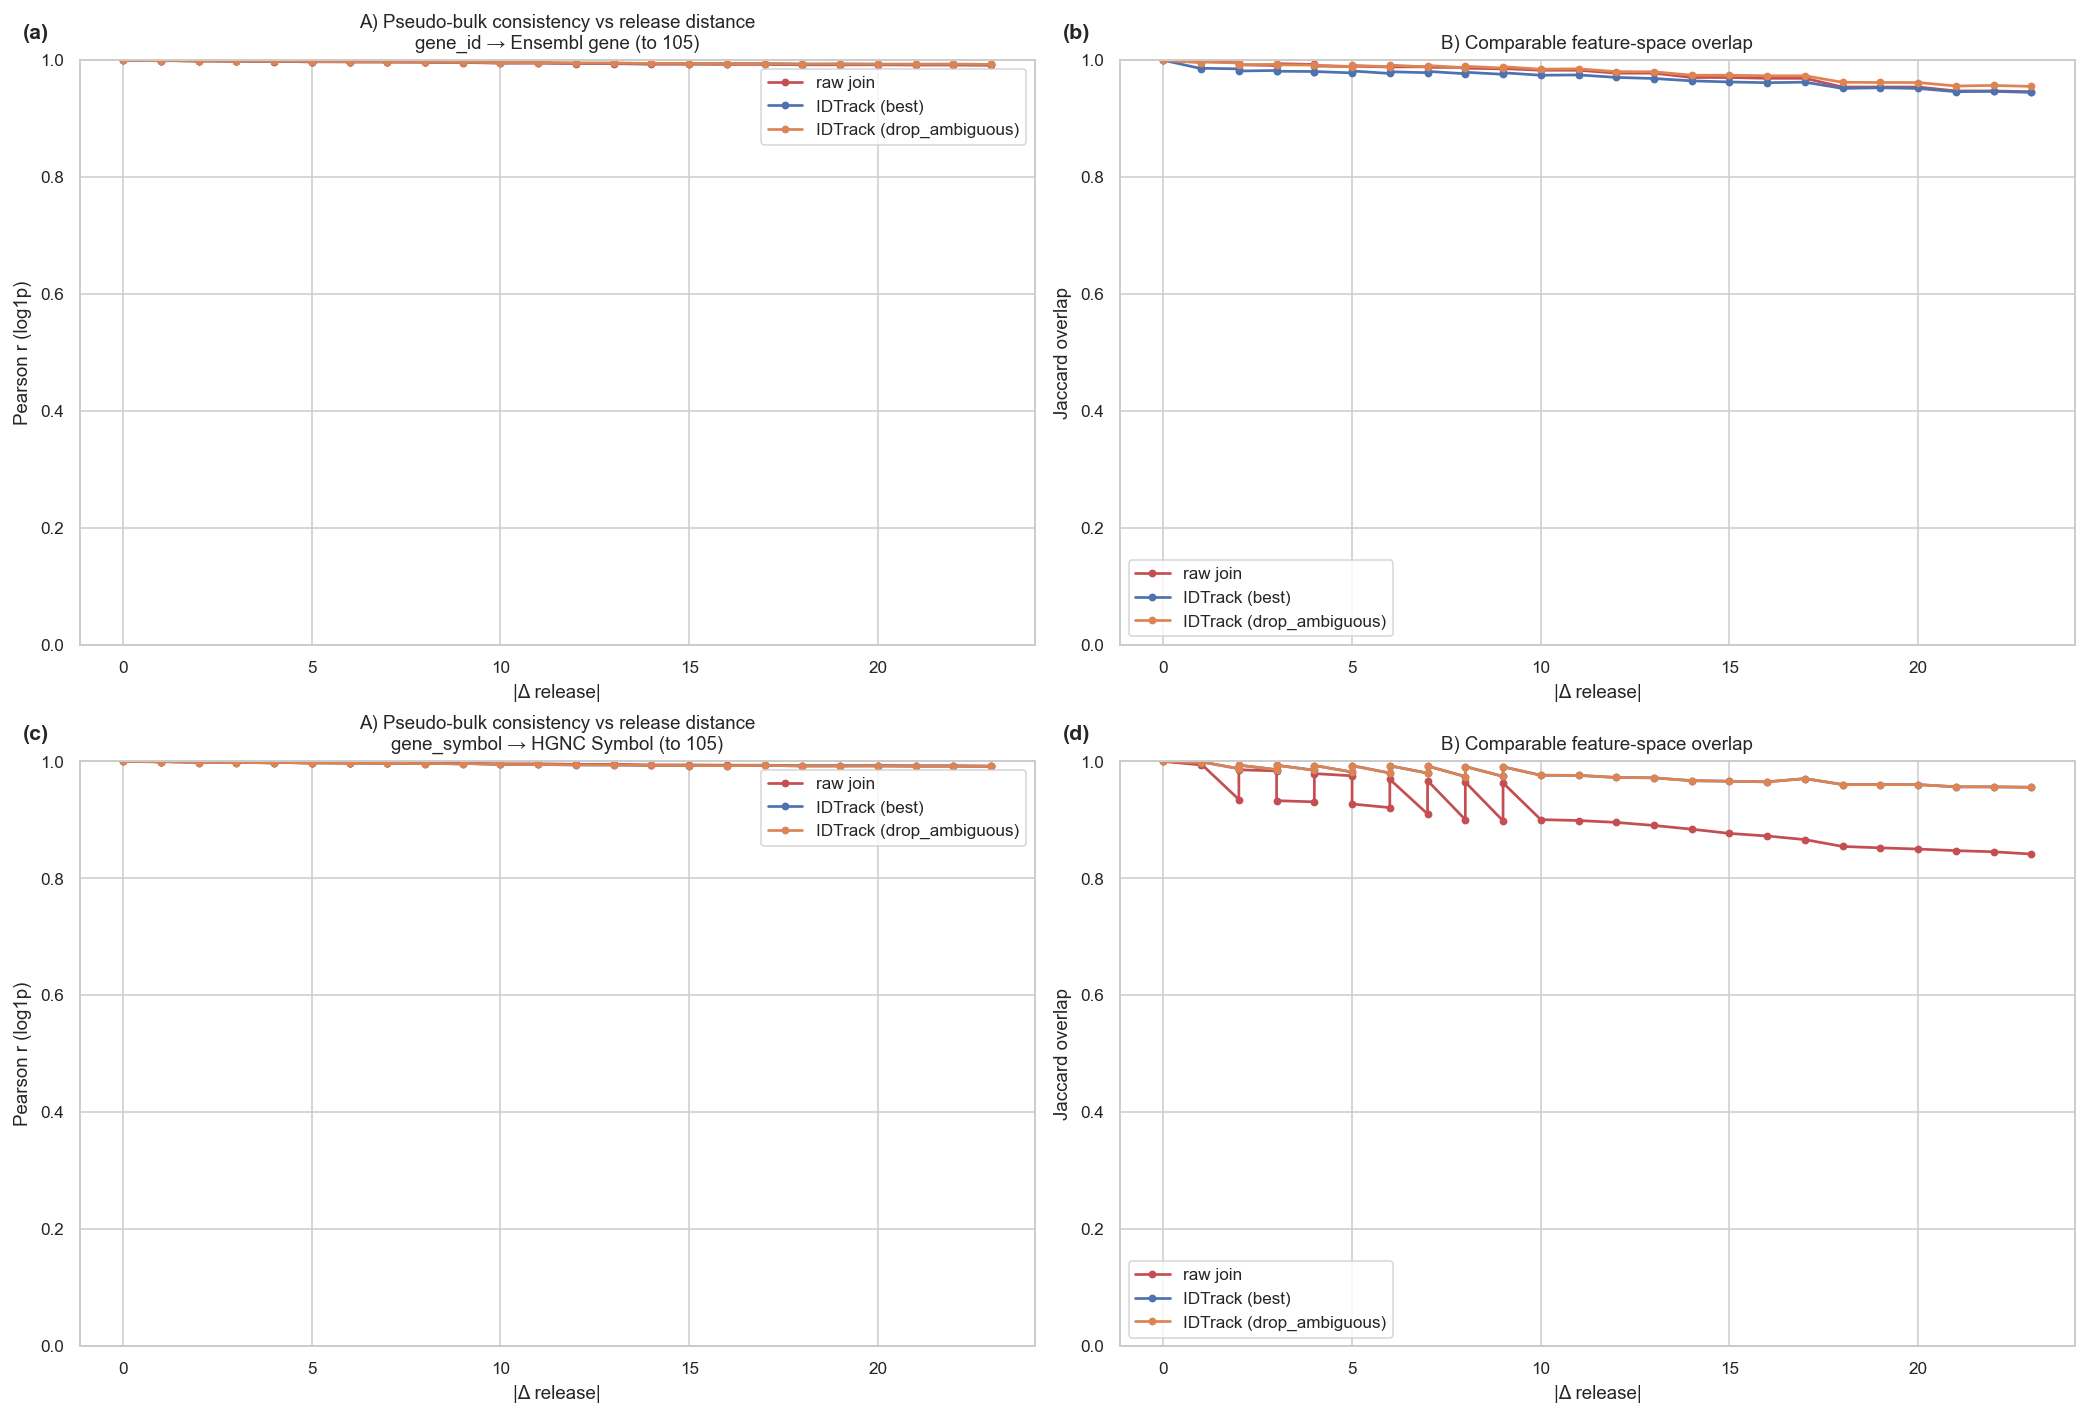

In [13]:
# -------------------- Figure: time travel restores overlap + expression consistency (multi-panel) --------------------

focus_channels = [
    ("gene_id", "Ensembl gene"),
    ("gene_symbol", "HGNC Symbol"),
]

fig3, axes3 = plt.subplots(len(focus_channels), 2, figsize=(14.8, 5.0 * len(focus_channels)), constrained_layout=True)
if len(focus_channels) == 1:
    axes3 = np.array([axes3])

for row_idx, (from_db, final_db) in enumerate(focus_channels):
    axA, axB = axes3[row_idx]

    raw = gold_metrics[(gold_metrics["from_database"] == from_db) & (gold_metrics["strategy"] == "raw_exact_join")].copy()
    raw = raw.sort_values("abs_delta")

    mapped = gold_metrics[(gold_metrics["from_database"] == from_db) & (gold_metrics["final_database"] == final_db) & (gold_metrics["strategy"].isin(MAPPING_STRATEGIES))].copy()
    mapped = mapped.sort_values(["strategy", "abs_delta"])

    if not raw.empty:
        axA.plot(raw["abs_delta"], raw["corr_pearson_log1p"], "-o", ms=3, lw=1.4, label="raw join", color=MANUSCRIPT_COLORS["1→0"])

    for strategy, color in [("best", MANUSCRIPT_COLORS["1→1"]), ("drop_ambiguous", MANUSCRIPT_COLORS["1→n"])]:
        sub = mapped[mapped["strategy"] == strategy]
        if sub.empty:
            continue
        axA.plot(sub["abs_delta"], sub["corr_pearson_log1p"], "-o", ms=3, lw=1.4, label=f"IDTrack ({strategy})", color=color)

    axA.set_title(f"A) Pseudo-bulk consistency vs release distance\n{from_db} → {final_db} (to {TARGET_RELEASE})")
    axA.set_xlabel("|Δ release|")
    axA.set_ylabel("Pearson r (log1p)")
    axA.set_ylim(0, 1)
    axA.legend(frameon=True)

    if not raw.empty:
        axB.plot(raw["abs_delta"], raw["jaccard"], "-o", ms=3, lw=1.4, label="raw join", color=MANUSCRIPT_COLORS["1→0"])

    for strategy, color in [("best", MANUSCRIPT_COLORS["1→1"]), ("drop_ambiguous", MANUSCRIPT_COLORS["1→n"])]:
        sub = mapped[mapped["strategy"] == strategy]
        if sub.empty:
            continue
        axB.plot(sub["abs_delta"], sub["jaccard"], "-o", ms=3, lw=1.4, label=f"IDTrack ({strategy})", color=color)

    axB.set_title("B) Comparable feature-space overlap")
    axB.set_xlabel("|Δ release|")
    axB.set_ylabel("Jaccard overlap")
    axB.set_ylim(0, 1)
    axB.legend(frameon=True)

label_panels(axes3.ravel())
written3 = save_figure(fig3, f"fig_cellranger_idtrack_gold_standard_gain_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", written3["pdf"])


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_umi_preservation_to105.pdf


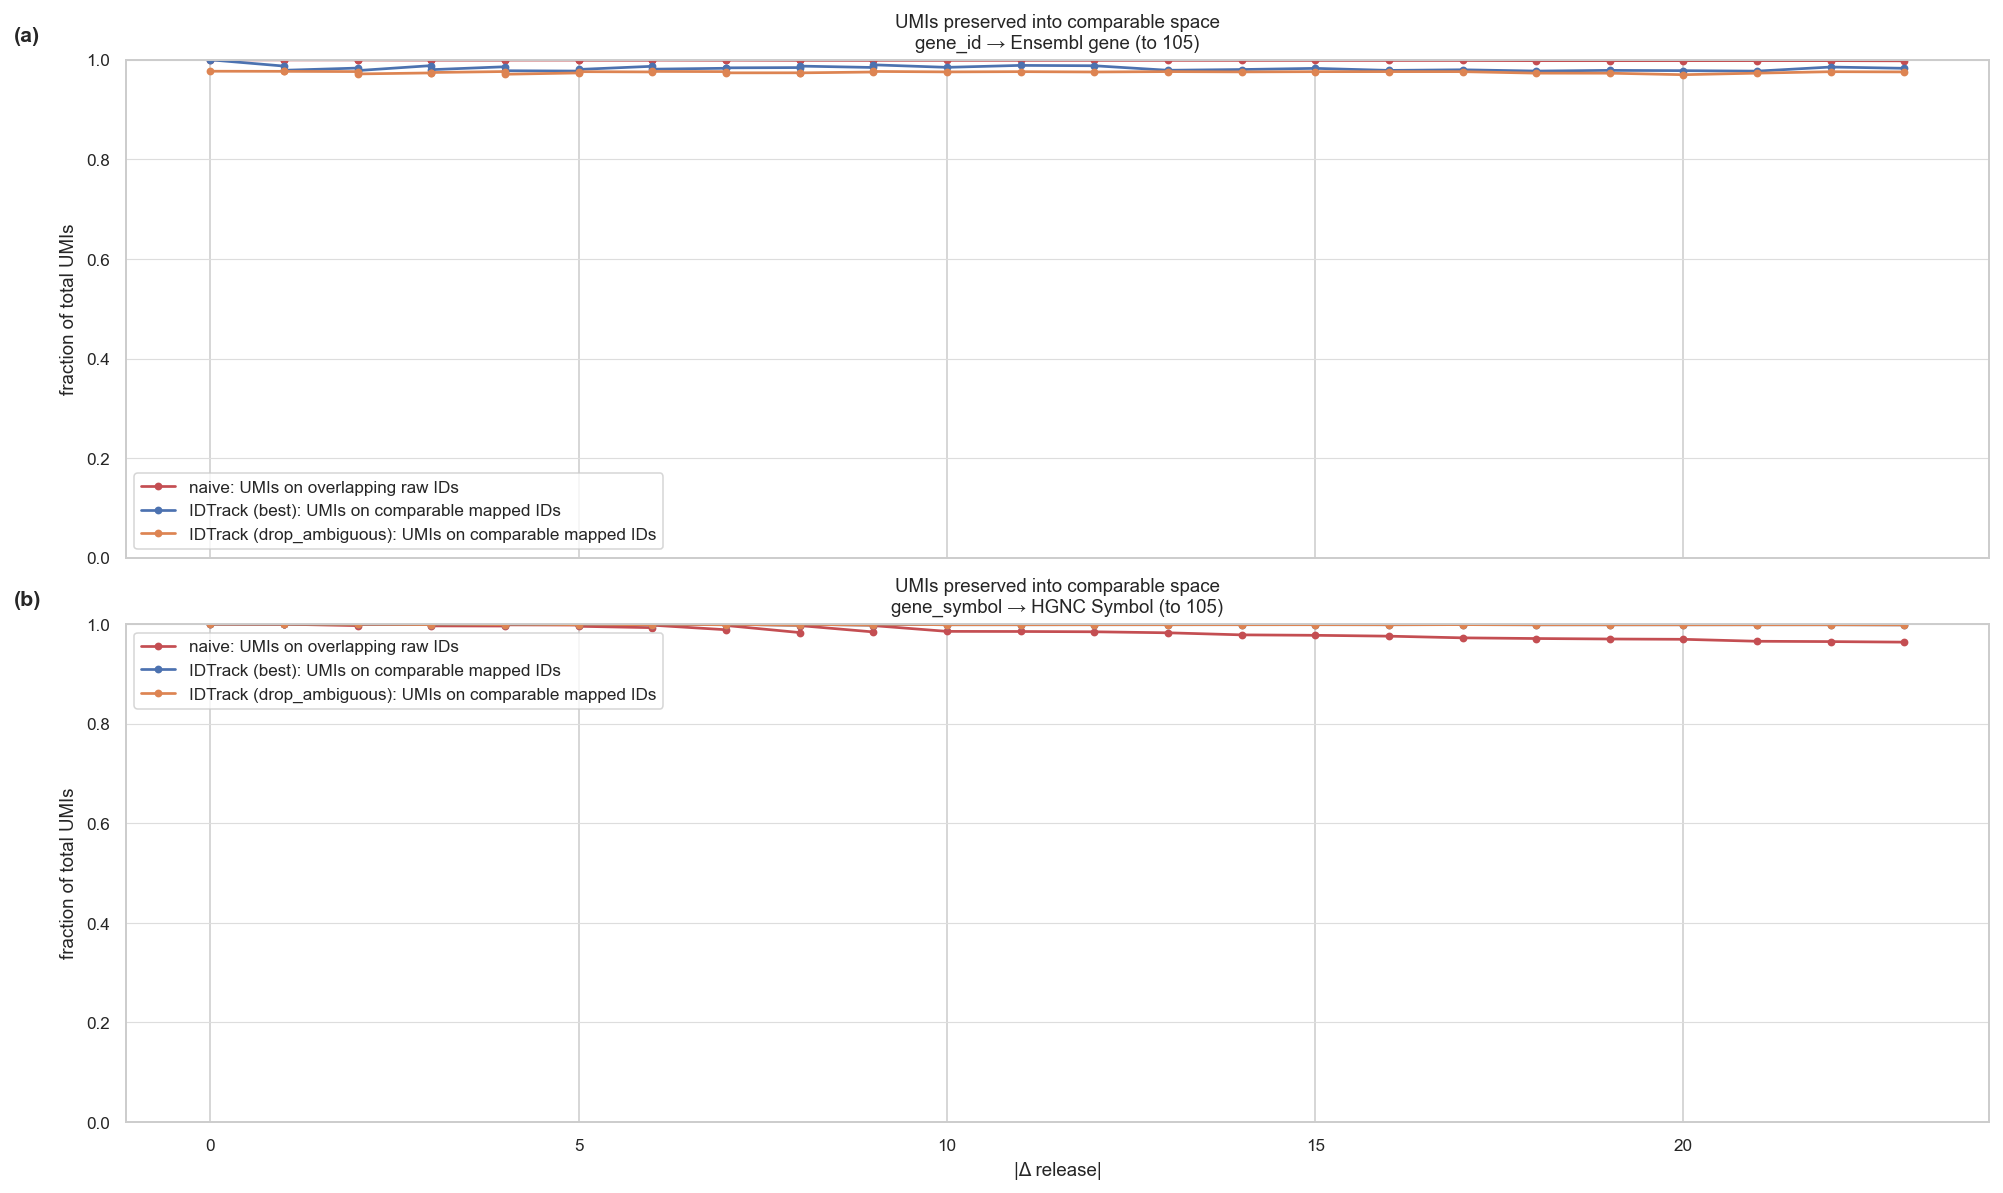

In [14]:
# -------------------- Figure: UMI preservation (what you lose without time travel) --------------------

fig4, axes4 = plt.subplots(len(focus_channels), 1, figsize=(14.2, 4.2 * len(focus_channels)), constrained_layout=True, sharex=True)
if len(focus_channels) == 1:
    axes4 = [axes4]

for ax, (from_db, final_db) in zip(axes4, focus_channels, strict=False):
    raw = gold_metrics[(gold_metrics["from_database"] == from_db) & (gold_metrics["strategy"] == "raw_exact_join")].copy().sort_values("abs_delta")
    mapped = gold_metrics[(gold_metrics["from_database"] == from_db) & (gold_metrics["final_database"] == final_db)].copy().sort_values(["strategy", "abs_delta"])

    if not raw.empty:
        ax.plot(
            raw["abs_delta"],
            raw["frac_umis_in_common"],
            "-o",
            ms=3,
            lw=1.4,
            label="naive: UMIs on overlapping raw IDs",
            color=MANUSCRIPT_COLORS["1→0"],
        )

    for strategy, color in [("best", MANUSCRIPT_COLORS["1→1"]), ("drop_ambiguous", MANUSCRIPT_COLORS["1→n"])]:
        sub = mapped[mapped["strategy"] == strategy]
        if sub.empty:
            continue
        ax.plot(
            sub["abs_delta"],
            sub["frac_umis_in_common"],
            "-o",
            ms=3,
            lw=1.4,
            label=f"IDTrack ({strategy}): UMIs on comparable mapped IDs",
            color=color,
        )

    ax.set_title(f"UMIs preserved into comparable space\n{from_db} → {final_db} (to {TARGET_RELEASE})")
    ax.set_ylabel("fraction of total UMIs")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)
    ax.legend(frameon=True)

axes4[-1].set_xlabel("|Δ release|")
label_panels(axes4)
written4 = save_figure(fig4, f"fig_cellranger_idtrack_umi_preservation_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", written4["pdf"])


## 6) Deep-dive: a concrete “time travel vs gold standard” case study

We take one historical release (`FOCUS_FROM_RELEASE`) and compare it to the gold standard at `TARGET_RELEASE`.

We export:

- a “mapping ledger” table (genes + UMI-weighted)
- top recovered genes (largest UMI contributions that would be lost without time travel)



In [15]:
def deep_dive_pair(
    *,
    from_release: int,
    to_release: int,
    from_database: str,
    to_database: str,
    strategy: str = "best",
    top_n: int = 25,
) -> dict[str, object]:
    if int(to_release) != int(TARGET_RELEASE):
        raise ValueError("Deep dive assumes to_release == TARGET_RELEASE.")

    pb_src = get_pseudobulk(int(from_release))
    pb_tgt = get_pseudobulk(int(to_release))

    totals_src = pb_src["totals"]
    var_src = pb_src["var"]

    totals_tgt = pb_tgt["totals"]
    var_tgt = pb_tgt["var"]

    if from_database not in var_src.columns or from_database not in var_tgt.columns:
        raise KeyError(f"Missing {from_database} in var columns.")

    normalize = "gene_id" if from_database == "gene_id" else "gene_symbol"
    raw_src = series_from_ids_and_totals(var_src[from_database].astype(str).tolist(), totals_src, normalize=normalize)
    raw_tgt = series_from_ids_and_totals(var_tgt[from_database].astype(str).tolist(), totals_tgt, normalize=normalize)

    raw_common = sorted(set(raw_src.index) & set(raw_tgt.index))

    src_m, dbg_src = mapped_pseudobulk(from_release=int(from_release), from_database=from_database, to_database=to_database, strategy=strategy)
    tgt_m, dbg_tgt = mapped_pseudobulk(from_release=int(to_release), from_database=from_database, to_database=to_database, strategy=strategy)

    mapped_common = sorted(set(src_m.index) & set(tgt_m.index))

    matchings = load_matchings(
        runs_sel,
        dataset=DATASET_SEL,
        assembly=ASSEMBLY_SEL,
        from_release=int(from_release),
        from_database=str(from_database),
        to_database=str(to_database),
        to_release=int(to_release),
    )
    if matchings is None:
        raise FileNotFoundError("Missing matchings for deep-dive.")
    if len(matchings) != len(totals_src):
        raise ValueError("Mismatch between matchings and feature totals length.")

    raw_tgt_set = set(raw_tgt.index)
    mapped_tgt_set = set(tgt_m.index)

    rows = []
    for i, (m, umi) in enumerate(zip(matchings, totals_src, strict=False)):
        no_corr = bool(m.get("no_corresponding"))
        no_conv = bool(m.get("no_conversion"))
        if no_corr or no_conv:
            mapping = "1→0"
            n_targets = 0
            best = None
            is_atm = False
        else:
            tids = m.get("target_id") or []
            tids = [str(t).strip() for t in tids if t is not None and str(t).strip()]
            uniq = list(dict.fromkeys(tids))
            n_targets = len(uniq)
            best = uniq[0] if uniq else None
            is_atm = bool(m.get("no_target"))
            mapping = "1→1" if n_targets == 1 else "1→n"

        query = str(m.get("query_id"))
        raw_norm = _normalize_gene_id(query) if from_database == "gene_id" else _normalize_gene_symbol(query)

        naive_keep = raw_norm in raw_tgt_set
        mapped_keep = (best in mapped_tgt_set) if best is not None else False
        recovered = mapped_keep and (not naive_keep) and mapping != "1→0"

        rows.append(
            {
                "feature_index": int(i),
                "query_id": query,
                "query_id_norm": raw_norm,
                "best_target": best,
                "mapping": mapping,
                "n_targets": int(n_targets),
                "no_target": bool(is_atm),
                "naive_keep": bool(naive_keep),
                "mapped_keep": bool(mapped_keep),
                "recovered_by_time_travel": bool(recovered),
                "umi_total": float(umi),
            }
        )

    feature_df = pd.DataFrame(rows)

    total_umi = float(feature_df["umi_total"].sum())
    ledger = (
        feature_df.groupby(["mapping", "no_target"], as_index=False)
        .agg(n_genes=("feature_index", "count"), umi_total=("umi_total", "sum"))
        .sort_values(["mapping", "no_target"], ascending=[True, True])
    )
    ledger["frac_genes"] = ledger["n_genes"] / ledger["n_genes"].sum()
    ledger["frac_umis"] = ledger["umi_total"] / total_umi if total_umi else float("nan")

    recovered = feature_df[feature_df["recovered_by_time_travel"]].copy().sort_values("umi_total", ascending=False)
    recovered_top = recovered.head(int(top_n)).copy()

    ambiguous = feature_df[feature_df["mapping"] == "1→n"].copy().sort_values("umi_total", ascending=False)
    ambiguous_top = ambiguous.head(int(top_n)).copy()

    src_common = src_m.reindex(mapped_common).astype(float)
    tgt_common = tgt_m.reindex(mapped_common).astype(float)

    return {
        "feature_df": feature_df,
        "ledger": ledger,
        "recovered_top": recovered_top,
        "ambiguous_top": ambiguous_top,
        "raw_common_n": int(len(raw_common)),
        "mapped_common_n": int(len(mapped_common)),
        "raw_corr": pearsonr_log1p(raw_src.reindex(raw_common), raw_tgt.reindex(raw_common)),
        "mapped_corr": pearsonr_log1p(src_common, tgt_common),
        "raw_umis_in_common": float(raw_src.reindex(raw_common).sum()),
        "mapped_umis_in_common": float(src_common.sum()),
    }


DEEPDIVE_TOP_N = int(os.environ.get("IDTRACK_DEEPDIVE_TOP_N", "200"))


def _deep_dive_cache_path(
    *,
    from_release: int,
    to_release: int,
    from_database: str,
    to_database: str,
    strategy: str,
    top_n: int,
) -> Path:
    stem = safe_tag(
        f"deepdive_{DATASET_SEL}_{ASSEMBLY_SEL}_from{from_release}_to{to_release}_{from_database}__{to_database}__{strategy}_top{top_n}"
    )
    return (CACHE_DIR / stem).with_suffix(".pickle")


pair_channels = [
    ("gene_id", "ensembl_gene"),
    ("gene_symbol", "HGNC Symbol"),
]

pair_results = {}
for from_db, to_db in pair_channels:
    key = f"{from_db}__{to_db}"
    cache_pkl = _deep_dive_cache_path(
        from_release=int(FOCUS_FROM_RELEASE),
        to_release=int(TARGET_RELEASE),
        from_database=str(from_db),
        to_database=str(to_db),
        strategy="best",
        top_n=int(DEEPDIVE_TOP_N),
    )

    def _compute(from_db=from_db, to_db=to_db):
        return deep_dive_pair(
            from_release=int(FOCUS_FROM_RELEASE),
            to_release=int(TARGET_RELEASE),
            from_database=str(from_db),
            to_database=str(to_db),
            strategy="best",
            top_n=int(DEEPDIVE_TOP_N),
        )

    if PLOT_ONLY_FROM_CACHE and not cache_pkl.exists():
        raise FileNotFoundError(
            f"Missing deep-dive cache {cache_pkl.name}. "
            "Run this notebook once on the server (with inputs available) to populate caches, then copy CACHE_DIR."
        )

    print("Loading deep dive:", key, "| cache:", cache_pkl.name)
    pair_results[key] = cache_pickle_or_compute(cache_pkl, _compute, force=FORCE_REBUILD)

pair_results.keys()


Loading deep dive: gene_id__ensembl_gene | cache: deepdive_pbmc_1k_v3_GRCh38_from85_to105_gene_id__ensembl_gene__best_top200.pickle
Loading deep dive: gene_symbol__HGNC Symbol | cache: deepdive_pbmc_1k_v3_GRCh38_from85_to105_gene_symbol__HGNC_Symbol__best_top200.pickle


dict_keys(['gene_id__ensembl_gene', 'gene_symbol__HGNC Symbol'])

In [16]:
# -------------------- Export deep-dive tables (publication-ready) --------------------

for key, res in pair_results.items():
    ledger = res["ledger"]
    recovered_top = res["recovered_top"]
    ambiguous_top = res["ambiguous_top"]

    out_ledger_csv = MANUSCRIPT_TABLES / f"cellranger_deepdive_ledger_{key}_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
    atomic_write_dataframe_csv(ledger, out_ledger_csv, index=False)
    atomic_write_dataframe_csv(ledger, ctx.experiment_outputs / "tables" / out_ledger_csv.name, index=False)

    out_rec_csv = MANUSCRIPT_TABLES / f"cellranger_deepdive_top_recovered_{key}_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
    atomic_write_dataframe_csv(recovered_top, out_rec_csv, index=False)
    atomic_write_dataframe_csv(recovered_top, ctx.experiment_outputs / "tables" / out_rec_csv.name, index=False)

    out_amb_csv = MANUSCRIPT_TABLES / f"cellranger_deepdive_top_ambiguous_{key}_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
    atomic_write_dataframe_csv(ambiguous_top, out_amb_csv, index=False)
    atomic_write_dataframe_csv(ambiguous_top, ctx.experiment_outputs / "tables" / out_amb_csv.name, index=False)

    print("Wrote:", out_ledger_csv)
    print("Wrote:", out_rec_csv)
    print("Wrote:", out_amb_csv)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_ledger_gene_id__ensembl_gene_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_top_recovered_gene_id__ensembl_gene_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_top_ambiguous_gene_id__ensembl_gene_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_ledger_gene_symbol__HGNC Symbol_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_top_recovered_gene_symbol__HGNC Symbol_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducib

/tmp/ipykernel_1447009/944531416.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  axA.set_xticklabels(list(bars.keys()), rotation=20, ha="right")
/tmp/ipykernel_1447009/944531416.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  axA.set_xticklabels(list(bars.keys()), rotation=20, ha="right")


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_deepdive_from85_to105.pdf


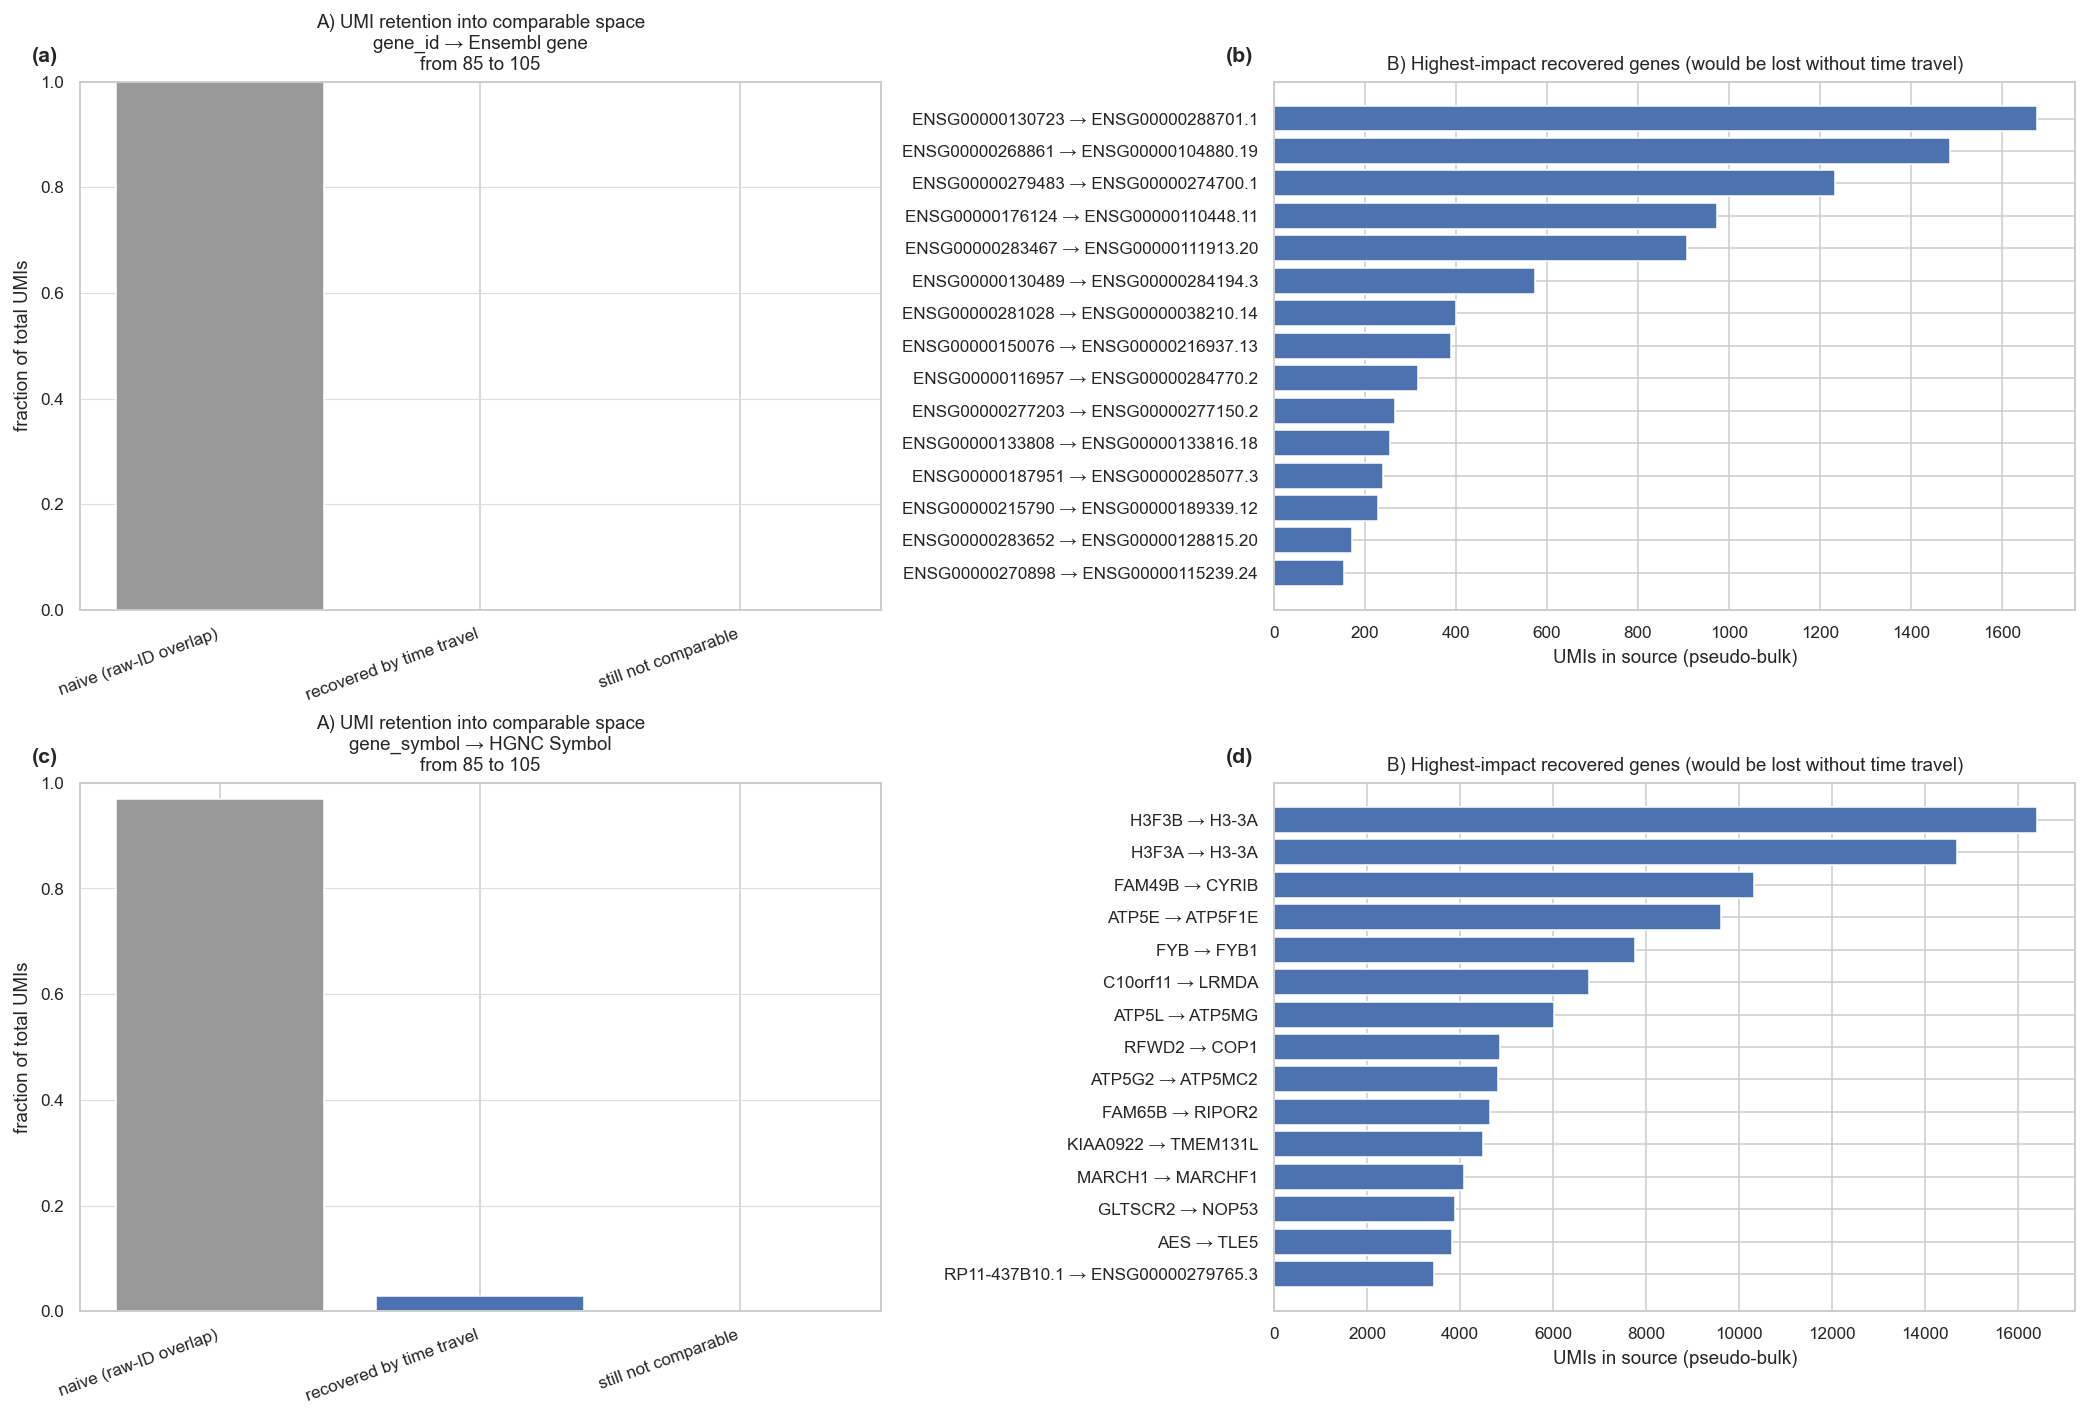

In [17]:
# -------------------- Deep-dive figure: what changes with vs without time travel --------------------

fig5, axes5 = plt.subplots(len(pair_channels), 2, figsize=(14.8, 5.0 * len(pair_channels)), constrained_layout=True)
if len(pair_channels) == 1:
    axes5 = np.array([axes5])

for row_idx, (from_db, to_db) in enumerate(pair_channels):
    key = f"{from_db}__{to_db}"
    res = pair_results[key]
    feature_df = res["feature_df"].copy()
    recovered_top = res["recovered_top"].copy()

    axA, axB = axes5[row_idx]

    total = feature_df["umi_total"].sum()
    naive = feature_df.loc[feature_df["naive_keep"], "umi_total"].sum()
    recovered = feature_df.loc[feature_df["recovered_by_time_travel"], "umi_total"].sum()

    bars = {
        "naive (raw-ID overlap)": naive,
        "recovered by time travel": recovered,
        "still not comparable": max(total - (naive + recovered), 0),
    }

    axA.bar(
        list(bars.keys()),
        [v / total if total else 0 for v in bars.values()],
        color=[MANUSCRIPT_COLORS["neutral"], MANUSCRIPT_COLORS["1→1"], MANUSCRIPT_COLORS["1→0"]],
    )
    axA.set_ylim(0, 1)
    axA.set_ylabel("fraction of total UMIs")
    axA.set_title(f"A) UMI retention into comparable space\n{from_db} → {_canonical_final_db(to_db)}\nfrom {FOCUS_FROM_RELEASE} to {TARGET_RELEASE}")
    axA.set_xticklabels(list(bars.keys()), rotation=20, ha="right")
    axA.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

    if recovered_top.empty:
        axB.axis("off")
        axB.text(0.5, 0.5, "No recovered genes found", ha="center", va="center")
    else:
        top = recovered_top.head(15).copy()
        labels = [f"{q} → {t}" for q, t in zip(top["query_id"], top["best_target"], strict=False)]
        axB.barh(list(reversed(labels)), list(reversed(top["umi_total"].values)), color=MANUSCRIPT_COLORS["1→1"])
        axB.set_xlabel("UMIs in source (pseudo-bulk)")
        axB.set_title("B) Highest-impact recovered genes (would be lost without time travel)")

label_panels(axes5.ravel())
written5 = save_figure(fig5, f"fig_cellranger_idtrack_deepdive_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.pdf", ctx, formats=("pdf",))
print("Saved:", written5["pdf"])


### 6b) Deep-dive diagnostics: expression agreement and recovery concentration

These panels are designed to be copy-pasteable into a Results narrative:

- **hexbin**: mapped pseudo-bulk (source vs target) on the common feature space
- **logFC distribution**: how much per-gene totals shift after harmonization
- **recovery concentration**: how many genes account for most recovered UMIs



Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_deepdive_diagnostics_gene_id__ensembl_gene_from85_to105.pdf
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_deepdive_diagnostics_gene_symbol__HGNC Symbol_from85_to105.pdf


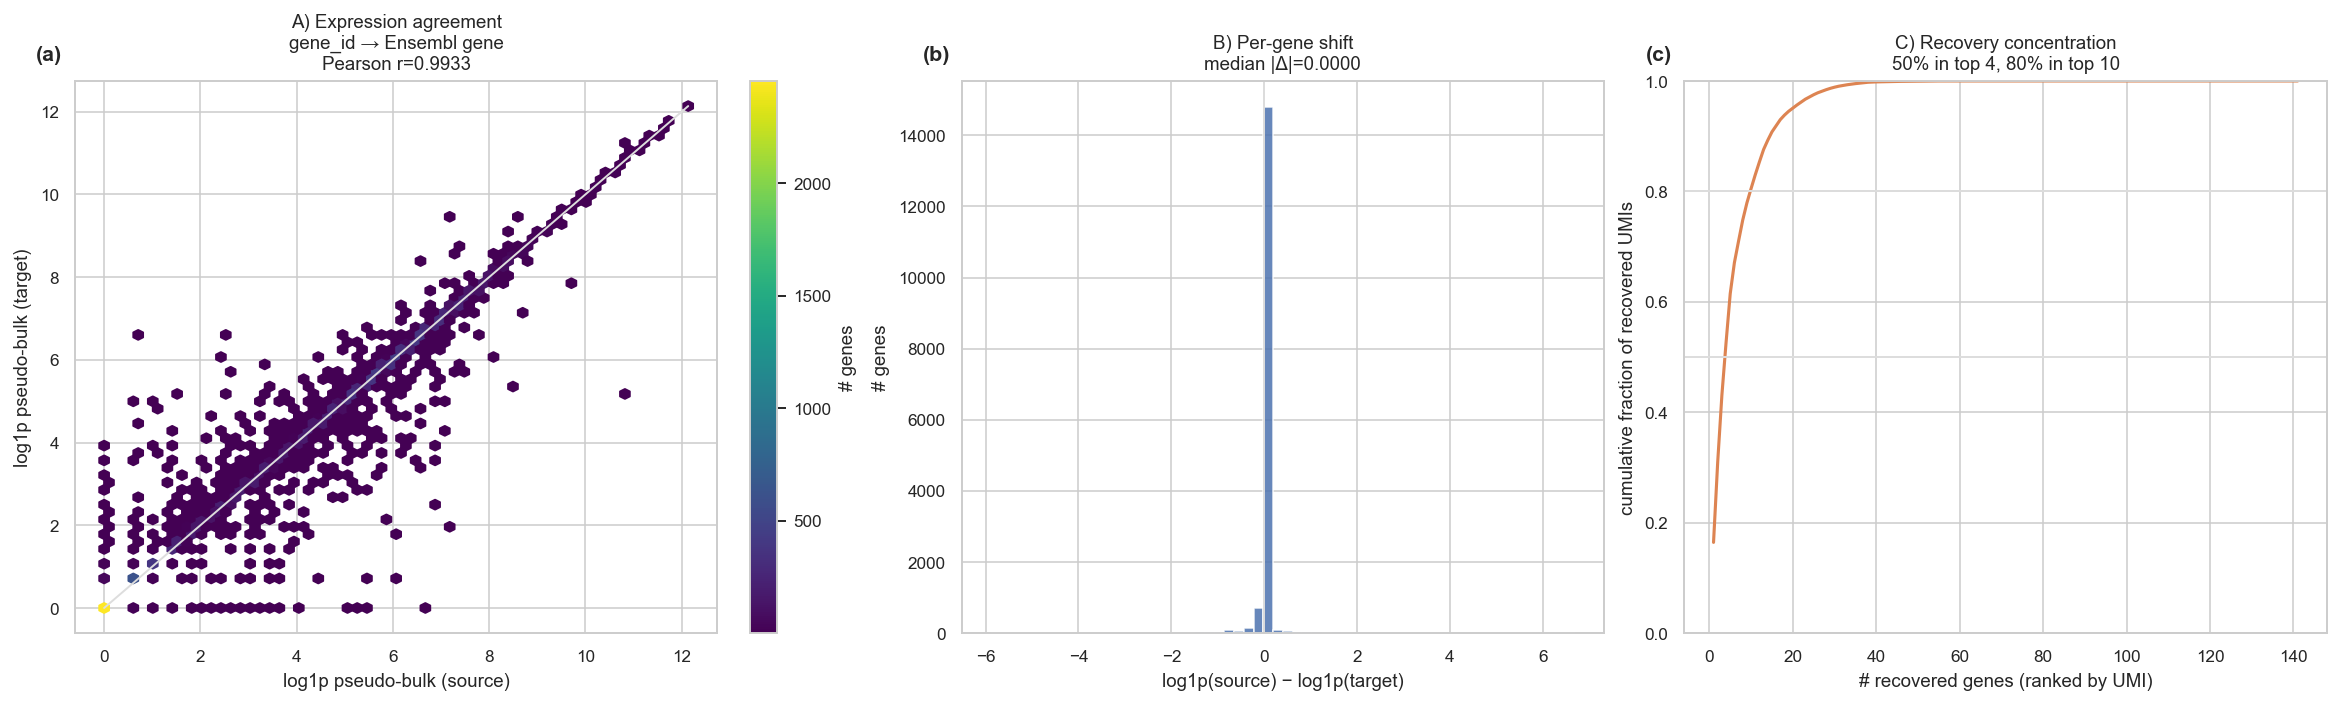

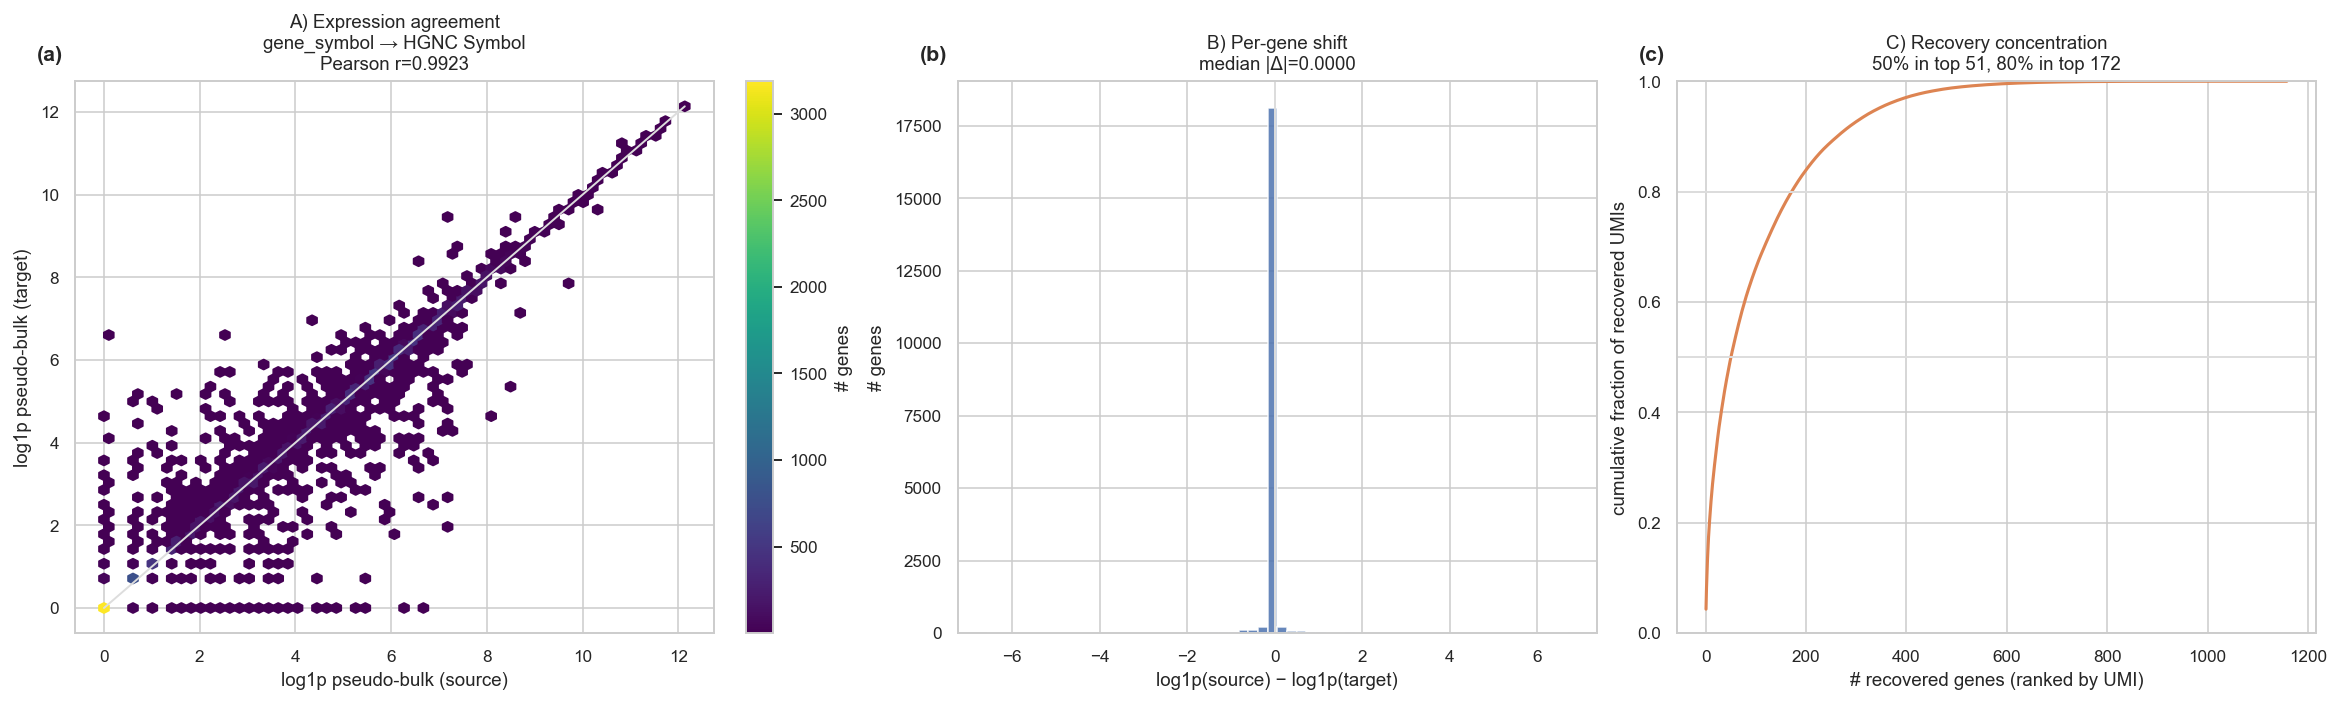

In [18]:
import math

for from_db, to_db in pair_channels:
    key = f"{from_db}__{to_db}"
    final_db = _canonical_final_db(to_db)

    # Mapped pseudo-bulk vectors
    src_m, _ = mapped_pseudobulk(from_release=int(FOCUS_FROM_RELEASE), from_database=from_db, to_database=to_db, strategy="best")
    tgt_m, _ = mapped_pseudobulk(from_release=int(TARGET_RELEASE), from_database=from_db, to_database=to_db, strategy="best")

    common = sorted(set(src_m.index) & set(tgt_m.index))
    if not common:
        print("No common targets for", key)
        continue

    a = src_m.reindex(common).astype(float)
    b = tgt_m.reindex(common).astype(float)

    # Recovery concentration (recovered UMIs are already exported per-feature)
    feat = pair_results[key]["feature_df"].copy()
    recovered = feat[feat["recovered_by_time_travel"]].copy()
    recovered = recovered.sort_values("umi_total", ascending=False)

    rec_vals = recovered["umi_total"].values
    rec_total = float(rec_vals.sum())
    if rec_vals.size:
        cum = np.cumsum(rec_vals) / rec_total if rec_total else np.zeros_like(rec_vals)
    else:
        cum = np.array([])

    # Figure per channel
    figX, axesX = plt.subplots(1, 3, figsize=(16.6, 4.9), constrained_layout=True)
    ax0, ax1, ax2 = axesX

    # (a) hexbin agreement
    x = np.log1p(a.values)
    y = np.log1p(b.values)
    hb = ax0.hexbin(x, y, gridsize=60, cmap="viridis", mincnt=1)
    cb = figX.colorbar(hb, ax=ax0)
    cb.set_label("# genes")
    r = pearsonr_log1p(a, b)
    ax0.plot([x.min(), x.max()], [x.min(), x.max()], color=MANUSCRIPT_COLORS["grid"], lw=1)
    ax0.set_xlabel("log1p pseudo-bulk (source)")
    ax0.set_ylabel("log1p pseudo-bulk (target)")
    ax0.set_title(f"A) Expression agreement\n{from_db} → {final_db}\nPearson r={r:.4f}")

    # (b) logFC distribution
    diff = x - y
    ax1.hist(diff, bins=60, color=MANUSCRIPT_COLORS["1→1"], alpha=0.85)
    ax1.axvline(0, color=MANUSCRIPT_COLORS["grid"], lw=1)
    mad = float(np.median(np.abs(diff)))
    ax1.set_xlabel("log1p(source) − log1p(target)")
    ax1.set_ylabel("# genes")
    ax1.set_title(f"B) Per-gene shift\nmedian |Δ|={mad:.4f}")

    # (c) recovery concentration
    if cum.size == 0:
        ax2.axis("off")
        ax2.text(0.5, 0.5, "No recovered UMIs", ha="center", va="center")
    else:
        xs = np.arange(1, cum.size + 1)
        ax2.plot(xs, cum, color=MANUSCRIPT_COLORS["1→n"], lw=1.6)
        ax2.axhline(0.5, color=MANUSCRIPT_COLORS["grid"], lw=1)
        ax2.axhline(0.8, color=MANUSCRIPT_COLORS["grid"], lw=1)
        k50 = int(xs[np.searchsorted(cum, 0.5)]) if (cum >= 0.5).any() else int(xs[-1])
        k80 = int(xs[np.searchsorted(cum, 0.8)]) if (cum >= 0.8).any() else int(xs[-1])
        ax2.set_xlabel("# recovered genes (ranked by UMI)")
        ax2.set_ylabel("cumulative fraction of recovered UMIs")
        ax2.set_ylim(0, 1)
        ax2.set_title(f"C) Recovery concentration\n50% in top {k50}, 80% in top {k80}")

    label_panels(axesX)
    writtenX = save_figure(
        figX,
        f"fig_cellranger_idtrack_deepdive_diagnostics_{key}_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.pdf",
        ctx,
        formats=("pdf",),
    )
    print("Saved:", writtenX["pdf"])


## 7) Optional (heavy): release×release heatmaps from cached conversions

If you have conversions for many releases (e.g. 82–114), you can generate a full `from_release × to_release` heatmap **without building the graph**.

This is optional because it can take time the first run (it summarizes many cached matchings lists). Results are cached under `CACHE_DIR`.



Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_time_travel_matrix_gene_id__Ensembl gene.pdf


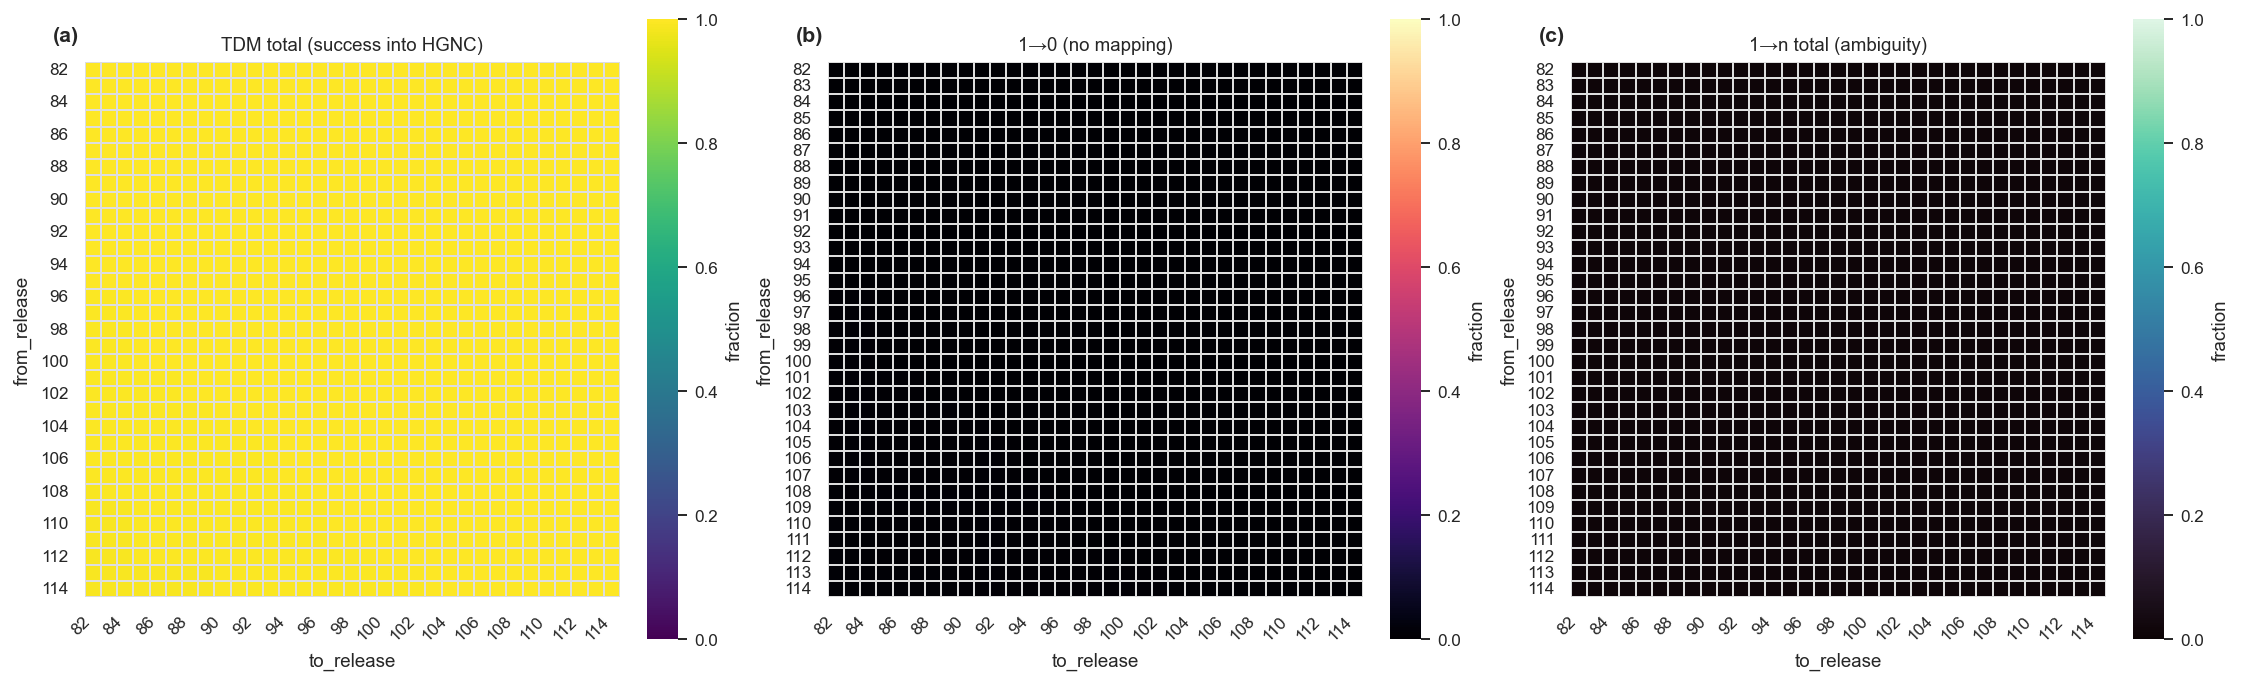

In [25]:
# Toggle this to True if you want full matrix heatmaps.
# NOTE: first run can take time for large release ranges; outputs are cached.

BUILD_FULL_MATRIX = True

if not BUILD_FULL_MATRIX:
    print("Skipping full matrix build (set BUILD_FULL_MATRIX=True to run).")
else:
    from_db = "gene_id"
    to_db = "ensembl_gene"

    grid_pkl = CACHE_DIR / safe_tag(f"time_travel_grid_{DATASET_SEL}_{ASSEMBLY_SEL}_{from_db}__{to_db}")
    grid_pkl = grid_pkl.with_suffix(".pickle")

    def _compute_grid() -> pd.DataFrame:
        rows = []
        for fr in releases:
            pkl = select_run_pickle_path(
                runs_sel,
                dataset=DATASET_SEL,
                assembly=ASSEMBLY_SEL,
                from_release=int(fr),
                from_database=from_db,
                to_database=to_db,
                to_release=int(TARGET_RELEASE),
            )
            if pkl is None:
                continue
            obj = read_pickle(pkl)
            if not isinstance(obj, dict):
                continue

            for tr, matchings in obj.items():
                try:
                    tr_i = int(tr)
                except Exception:
                    continue
                if tr_i not in set(releases):
                    continue
                if not isinstance(matchings, list):
                    continue

                summ = summarize_matchings_fast(matchings)
                rows.append(
                    {
                        "from_release": int(fr),
                        "to_release": int(tr_i),
                        "from_database": from_db,
                        "final_database": _canonical_final_db(to_db),
                        **summ,
                    }
                )

        df = pd.DataFrame(rows)
        if df.empty:
            raise RuntimeError("No grid rows were produced.")
        return add_fraction_columns(df)

    grid = cache_pickle_or_compute(grid_pkl, _compute_grid, force=FORCE_REBUILD)

    metrics = [
        ("frac_tdm_total", "TDM total (success into HGNC)", "viridis", 0, 1, None),
        ("frac_1_to_0", "1→0 (no mapping)", "magma", 0, 1, None),
        ("frac_1_to_n_total", "1→n total (ambiguity)", "mako", 0, 1, None),
    ]

    figH, axesH = plt.subplots(1, len(metrics), figsize=(5.3 * len(metrics), 5.0), constrained_layout=True)
    if len(metrics) == 1:
        axesH = [axesH]

    for ax, (col, title, cmap, vmin, vmax, center) in zip(axesH, metrics, strict=False):
        mat = grid.pivot(index="from_release", columns="to_release", values=col).sort_index().sort_index(axis=1)
        heatmap(ax, mat, title=title, cmap=cmap, vmin=vmin, vmax=vmax, center=center, square=True, cbar=True, cbar_label="fraction")
        ax.set_xlabel("to_release")
        ax.set_ylabel("from_release")

    label_panels(axesH)
    writtenH = save_figure(figH, f"fig_cellranger_idtrack_time_travel_matrix_{from_db}__{_canonical_final_db(to_db)}.pdf", ctx, formats=("pdf",))
    print("Saved:", writtenH["pdf"])


## 8) LaTeX-ready summary snippets (optional)

This cell writes small LaTeX tables you can paste into the manuscript.



In [20]:
rows = []
for key, res in pair_results.items():
    rows.append(
        {
            "channel": key.replace("__", " → "),
            "from_release": int(FOCUS_FROM_RELEASE),
            "to_release": int(TARGET_RELEASE),
            "raw_common_genes": int(res["raw_common_n"]),
            "mapped_common_genes": int(res["mapped_common_n"]),
            "raw_corr_log1p": float(res["raw_corr"]),
            "mapped_corr_log1p": float(res["mapped_corr"]),
            "raw_umis_in_common": float(res["raw_umis_in_common"]),
            "mapped_umis_in_common": float(res["mapped_umis_in_common"]),
        }
    )

focus_table = pd.DataFrame(rows)

out_focus_csv = MANUSCRIPT_TABLES / f"cellranger_deepdive_focus_summary_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(focus_table, out_focus_csv, index=False)
atomic_write_dataframe_csv(focus_table, ctx.experiment_outputs / "tables" / out_focus_csv.name, index=False)
print("Wrote:", out_focus_csv)

out_focus_tex = MANUSCRIPT_TABLES / f"cellranger_deepdive_focus_summary_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.tex"
atomic_write_dataframe_latex(focus_table, out_focus_tex, index=False, escape=True)
atomic_write_dataframe_latex(focus_table, ctx.experiment_outputs / "tables" / out_focus_tex.name, index=False, escape=True)
print("Wrote:", out_focus_tex)

focus_table


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_focus_summary_from85_to105.csv
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_deepdive_focus_summary_from85_to105.tex


,channel,from_release,to_release,raw_common_genes,mapped_common_genes,raw_corr_log1p,mapped_corr_log1p,raw_umis_in_common,mapped_umis_in_common
0,gene_id → ensembl_gene,85,105,19507,16275,0.992256,0.993299,12941666.0,12681022.0
1,gene_symbol → HGNC Symbol,85,105,18339,19332,0.992913,0.992306,12567316.0,12945733.0


## 9) Marketing hero summary (top-K overlap + agreement + UMIs)

In addition to correlations and Jaccard overlap, a reviewer-friendly question is:

**Do we preserve the most abundant (most biologically salient) genes across time?**

This section computes a simple, interpretable metric: **top-K overlap** between the mapped pseudo-bulk and the gold standard.
It then builds a compact multi-panel figure that combines:

- expression agreement (pseudo-bulk)
- comparable feature-space overlap (Jaccard)
- fraction of UMIs in a comparable space
- top-K overlap (abundance-aware stability)



In [21]:
# -------------------- Top-K overlap (abundance-aware feature preservation) --------------------

TOPK_LIST = tuple(
    int(x) for x in os.environ.get("IDTRACK_TOPK_LIST", "50,100,200,500").split(",") if str(x).strip()
)
if not TOPK_LIST:
    TOPK_LIST = (50, 100, 200, 500)


def _topk_overlap_cache_path() -> Path:
    k_tag = "-".join(map(str, TOPK_LIST))
    stem = safe_tag(f"topk_overlap_{DATASET_SEL}_{ASSEMBLY_SEL}_to{TARGET_RELEASE}_k{k_tag}")
    return CACHE_DIR / f"{stem}.pickle"


def compute_topk_overlap() -> pd.DataFrame:
    rows = []

    raw_target: dict[str, pd.Series] = {}
    for from_db in FROM_DATABASES:
        try:
            raw_target[str(from_db)] = raw_pseudobulk(from_release=TARGET_RELEASE, from_database=str(from_db))
        except Exception as exc:  # noqa: S110
            print(f"[WARN] Could not build raw target pseudo-bulk for {from_db}: {exc}")
            continue

    mapped_target: dict[tuple[str, str, str], pd.Series] = {}
    for from_db in FROM_DATABASES:
        for to_db in TO_DATABASES:
            for strategy in MAPPING_STRATEGIES:
                try:
                    tgt_m, _ = mapped_pseudobulk(
                        from_release=int(TARGET_RELEASE),
                        from_database=str(from_db),
                        to_database=str(to_db),
                        strategy=str(strategy),
                    )
                except Exception as exc:  # noqa: S110
                    print(f"[WARN] Could not build mapped target pseudo-bulk for {from_db}→{to_db} ({strategy}): {exc}")
                    continue
                mapped_target[(str(from_db), str(to_db), str(strategy))] = tgt_m

    for from_release in releases:
        abs_delta = int(abs(int(TARGET_RELEASE) - int(from_release)))

        for from_db in FROM_DATABASES:
            try:
                raw_src = raw_pseudobulk(from_release=int(from_release), from_database=str(from_db))
            except Exception as exc:  # noqa: S110
                print(f"[WARN] Could not build raw pseudo-bulk for from_release={from_release} from_db={from_db}: {exc}")
                continue

            raw_tgt = raw_target.get(str(from_db))
            if raw_tgt is None:
                continue

            for k in TOPK_LIST:
                k_eff = int(min(int(k), int(raw_src.size), int(raw_tgt.size)))
                if k_eff <= 0:
                    overlap = float("nan")
                else:
                    overlap = len(set(raw_src.nlargest(k_eff).index) & set(raw_tgt.nlargest(k_eff).index)) / float(k_eff)

                rows.append(
                    {
                        "dataset": DATASET_SEL,
                        "assembly": ASSEMBLY_SEL,
                        "from_release": int(from_release),
                        "to_release": int(TARGET_RELEASE),
                        "abs_delta": abs_delta,
                        "from_database": str(from_db),
                        "final_database": "(raw)",
                        "strategy": "raw_exact_join",
                        "k": int(k),
                        "topk_overlap": float(overlap),
                    }
                )

            for to_db in TO_DATABASES:
                final_db = _canonical_final_db(str(to_db))
                for strategy in MAPPING_STRATEGIES:
                    tgt_m = mapped_target.get((str(from_db), str(to_db), str(strategy)))
                    if tgt_m is None:
                        continue

                    try:
                        src_m, _ = mapped_pseudobulk(
                            from_release=int(from_release),
                            from_database=str(from_db),
                            to_database=str(to_db),
                            strategy=str(strategy),
                        )
                    except Exception as exc:  # noqa: S110
                        print(
                            f"[WARN] Could not build mapped pseudo-bulk for from_release={from_release} {from_db}→{to_db} ({strategy}): {exc}"
                        )
                        continue

                    for k in TOPK_LIST:
                        k_eff = int(min(int(k), int(src_m.size), int(tgt_m.size)))
                        if k_eff <= 0:
                            overlap = float("nan")
                        else:
                            overlap = len(set(src_m.nlargest(k_eff).index) & set(tgt_m.nlargest(k_eff).index)) / float(k_eff)

                        rows.append(
                            {
                                "dataset": DATASET_SEL,
                                "assembly": ASSEMBLY_SEL,
                                "from_release": int(from_release),
                                "to_release": int(TARGET_RELEASE),
                                "abs_delta": abs_delta,
                                "from_database": str(from_db),
                                "final_database": str(final_db),
                                "strategy": str(strategy),
                                "k": int(k),
                                "topk_overlap": float(overlap),
                            }
                        )

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No top-K rows produced.")
    return df.sort_values(["from_database", "final_database", "strategy", "k", "from_release"]).reset_index(drop=True)


topk_overlap_df = cache_pickle_or_compute(_topk_overlap_cache_path(), compute_topk_overlap, force=FORCE_REBUILD)

out_topk_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_topk_overlap_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(topk_overlap_df, out_topk_csv, index=False)
atomic_write_dataframe_csv(topk_overlap_df, ctx.experiment_outputs / "tables" / out_topk_csv.name, index=False)
print("Wrote:", out_topk_csv)

topk_overlap_df.head(12)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_topk_overlap_to105.csv


,dataset,assembly,from_release,to_release,abs_delta,from_database,final_database,strategy,k,topk_overlap
0,pbmc_1k_v3,GRCh38,82,105,23,gene_id,(raw),raw_exact_join,50,1.0
1,pbmc_1k_v3,GRCh38,83,105,22,gene_id,(raw),raw_exact_join,50,1.0
2,pbmc_1k_v3,GRCh38,84,105,21,gene_id,(raw),raw_exact_join,50,1.0
3,pbmc_1k_v3,GRCh38,85,105,20,gene_id,(raw),raw_exact_join,50,1.0
4,pbmc_1k_v3,GRCh38,86,105,19,gene_id,(raw),raw_exact_join,50,1.0
5,pbmc_1k_v3,GRCh38,87,105,18,gene_id,(raw),raw_exact_join,50,1.0
6,pbmc_1k_v3,GRCh38,88,105,17,gene_id,(raw),raw_exact_join,50,1.0
7,pbmc_1k_v3,GRCh38,89,105,16,gene_id,(raw),raw_exact_join,50,1.0
8,pbmc_1k_v3,GRCh38,90,105,15,gene_id,(raw),raw_exact_join,50,1.0
9,pbmc_1k_v3,GRCh38,91,105,14,gene_id,(raw),raw_exact_join,50,1.0


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_hero_summary_to105_k200.pdf


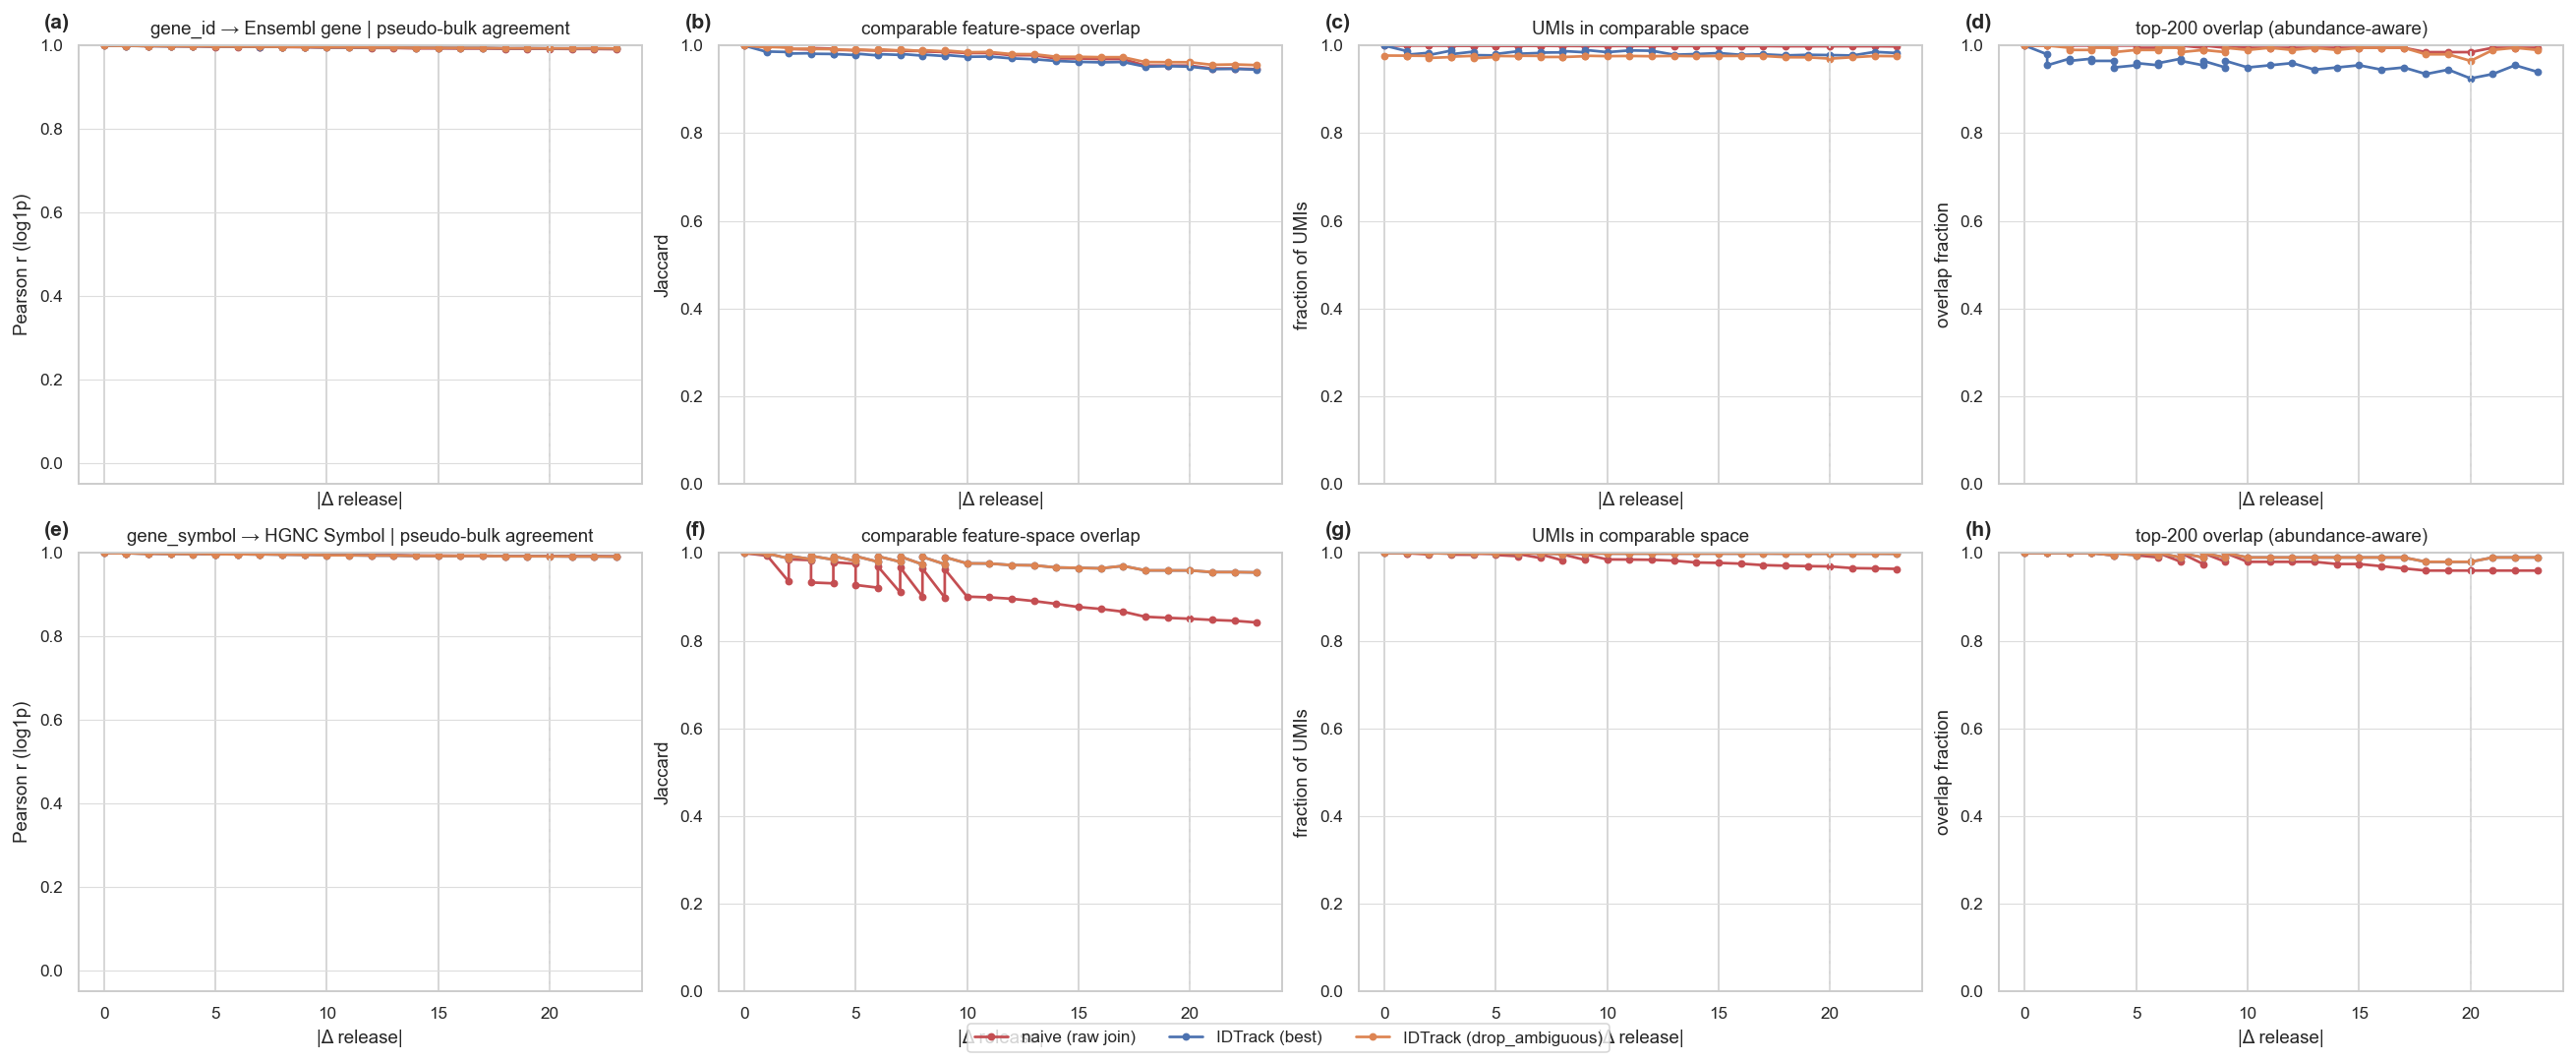

In [22]:
# -------------------- Hero figure: agreement + overlap + UMI preservation + top-K --------------------

HERO_K = int(HERO_TOPK)
focus_abs_delta = int(abs(int(TARGET_RELEASE) - int(FOCUS_FROM_RELEASE)))

hero_channels = [
    ("gene_id", "Ensembl gene", "ensembl_gene"),
    ("gene_symbol", "HGNC Symbol", "HGNC Symbol"),
]

figH, axesH = plt.subplots(len(hero_channels), 4, figsize=(18.6, 7.6), constrained_layout=True, sharex="col")
if len(hero_channels) == 1:
    axesH = np.array([axesH])


def _plot_metric(
    ax,
    *,
    raw_df: pd.DataFrame,
    mapped_df: pd.DataFrame,
    col: str,
    title: str,
    ylabel: str,
    ylim: tuple[float, float] = (0.0, 1.0),
) -> None:
    if not raw_df.empty and col in raw_df.columns:
        ax.plot(
            raw_df["abs_delta"],
            raw_df[col],
            "-o",
            ms=3,
            lw=1.4,
            label="naive (raw join)",
            color=MANUSCRIPT_COLORS["1→0"],
        )

    for strategy, color in [("best", MANUSCRIPT_COLORS["1→1"]), ("drop_ambiguous", MANUSCRIPT_COLORS["1→n"])]:
        sub = mapped_df[mapped_df["strategy"] == strategy]
        if sub.empty or col not in sub.columns:
            continue
        ax.plot(sub["abs_delta"], sub[col], "-o", ms=3, lw=1.4, label=f"IDTrack ({strategy})", color=color)

    ax.axvline(focus_abs_delta, color=MANUSCRIPT_COLORS["grid"], lw=1, ls="--")
    ax.set_ylim(*ylim)
    ax.set_xlabel("|Δ release|")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)


for row_idx, (from_db, final_db, to_db) in enumerate(hero_channels):
    raw = gold_metrics[(gold_metrics["from_database"] == from_db) & (gold_metrics["strategy"] == "raw_exact_join")].copy()
    raw = raw.sort_values("abs_delta")

    mapped = gold_metrics[
        (gold_metrics["from_database"] == from_db)
        & (gold_metrics["final_database"] == final_db)
        & (gold_metrics["strategy"].isin(MAPPING_STRATEGIES))
    ].copy()
    mapped = mapped.sort_values(["strategy", "abs_delta"])

    top_raw = topk_overlap_df[
        (topk_overlap_df["from_database"] == from_db)
        & (topk_overlap_df["final_database"] == "(raw)")
        & (topk_overlap_df["strategy"] == "raw_exact_join")
        & (topk_overlap_df["k"] == HERO_K)
    ].copy()
    top_raw = top_raw.sort_values("abs_delta")

    top_mapped = topk_overlap_df[
        (topk_overlap_df["from_database"] == from_db)
        & (topk_overlap_df["final_database"] == final_db)
        & (topk_overlap_df["strategy"].isin(MAPPING_STRATEGIES))
        & (topk_overlap_df["k"] == HERO_K)
    ].copy()
    top_mapped = top_mapped.sort_values(["strategy", "abs_delta"])

    _plot_metric(
        axesH[row_idx, 0],
        raw_df=raw,
        mapped_df=mapped,
        col="corr_pearson_log1p",
        title=f"{from_db} → {final_db} | pseudo-bulk agreement",
        ylabel="Pearson r (log1p)",
        ylim=(-0.05, 1.0),
    )
    _plot_metric(
        axesH[row_idx, 1],
        raw_df=raw,
        mapped_df=mapped,
        col="jaccard",
        title="comparable feature-space overlap",
        ylabel="Jaccard",
        ylim=(0.0, 1.0),
    )
    _plot_metric(
        axesH[row_idx, 2],
        raw_df=raw,
        mapped_df=mapped,
        col="frac_umis_in_common",
        title="UMIs in comparable space",
        ylabel="fraction of UMIs",
        ylim=(0.0, 1.0),
    )
    _plot_metric(
        axesH[row_idx, 3],
        raw_df=top_raw,
        mapped_df=top_mapped,
        col="topk_overlap",
        title=f"top-{HERO_K} overlap (abundance-aware)",
        ylabel="overlap fraction",
        ylim=(0.0, 1.0),
    )

handles, labels = axesH[0, 0].get_legend_handles_labels()
figH.legend(handles, labels, loc="lower center", ncol=3, frameon=True)
label_panels(axesH.ravel())
writtenH = save_figure(figH, f"fig_cellranger_idtrack_hero_summary_to{TARGET_RELEASE}_k{HERO_K}.pdf", ctx, formats=("pdf",))
print("Saved:", writtenH["pdf"])


## 10) Where drift hurts: outcomes stratified by expression level (focus release)

Drift is often assumed to affect only low-abundance features.
Here we stratify mapping outcomes by **UMI quantile bins** in the historical release to show where the *mass* sits.

This helps motivate why drift matters even when headline gene-level fractions look small.



Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_expression_bin_outcomes_from85_to105.csv
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_expression_bins_from85_to105.pdf


,dataset,assembly,from_release,to_release,from_database,final_database,bin,bin_low,bin_high,category,bin_n_genes,bin_total_umis,n_genes,frac_genes_in_bin,umis,frac_umis_in_bin
0,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,0–50% (low),0.00,0.50,1→0,9986,115870.0,47,0.004707,35.0,0.000302
1,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,0–50% (low),0.00,0.50,1→1,9986,115870.0,9822,0.983577,115128.0,0.993596
2,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,0–50% (low),0.00,0.50,1→n,9986,115870.0,117,0.011716,707.0,0.006102
3,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,50–90%,0.50,0.90,1→0,7978,3303806.0,1,0.000125,237.0,0.000072
4,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,50–90%,0.50,0.90,1→1,7978,3303806.0,7927,0.993607,3282522.0,0.993558
5,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,50–90%,0.50,0.90,1→n,7978,3303806.0,50,0.006267,21047.0,0.006371
6,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,90–99%,0.90,0.99,1→0,1797,4226789.0,0,0.000000,0.0,0.000000
7,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,90–99%,0.90,0.99,1→1,1797,4226789.0,1781,0.991096,4187192.0,0.990632
8,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,90–99%,0.90,0.99,1→n,1797,4226789.0,16,0.008904,39597.0,0.009368
9,pbmc_1k_v3,GRCh38,85,105,gene_id,Ensembl gene,99–100% (high),0.99,1.00,1→0,200,5315797.0,0,0.000000,0.0,0.000000


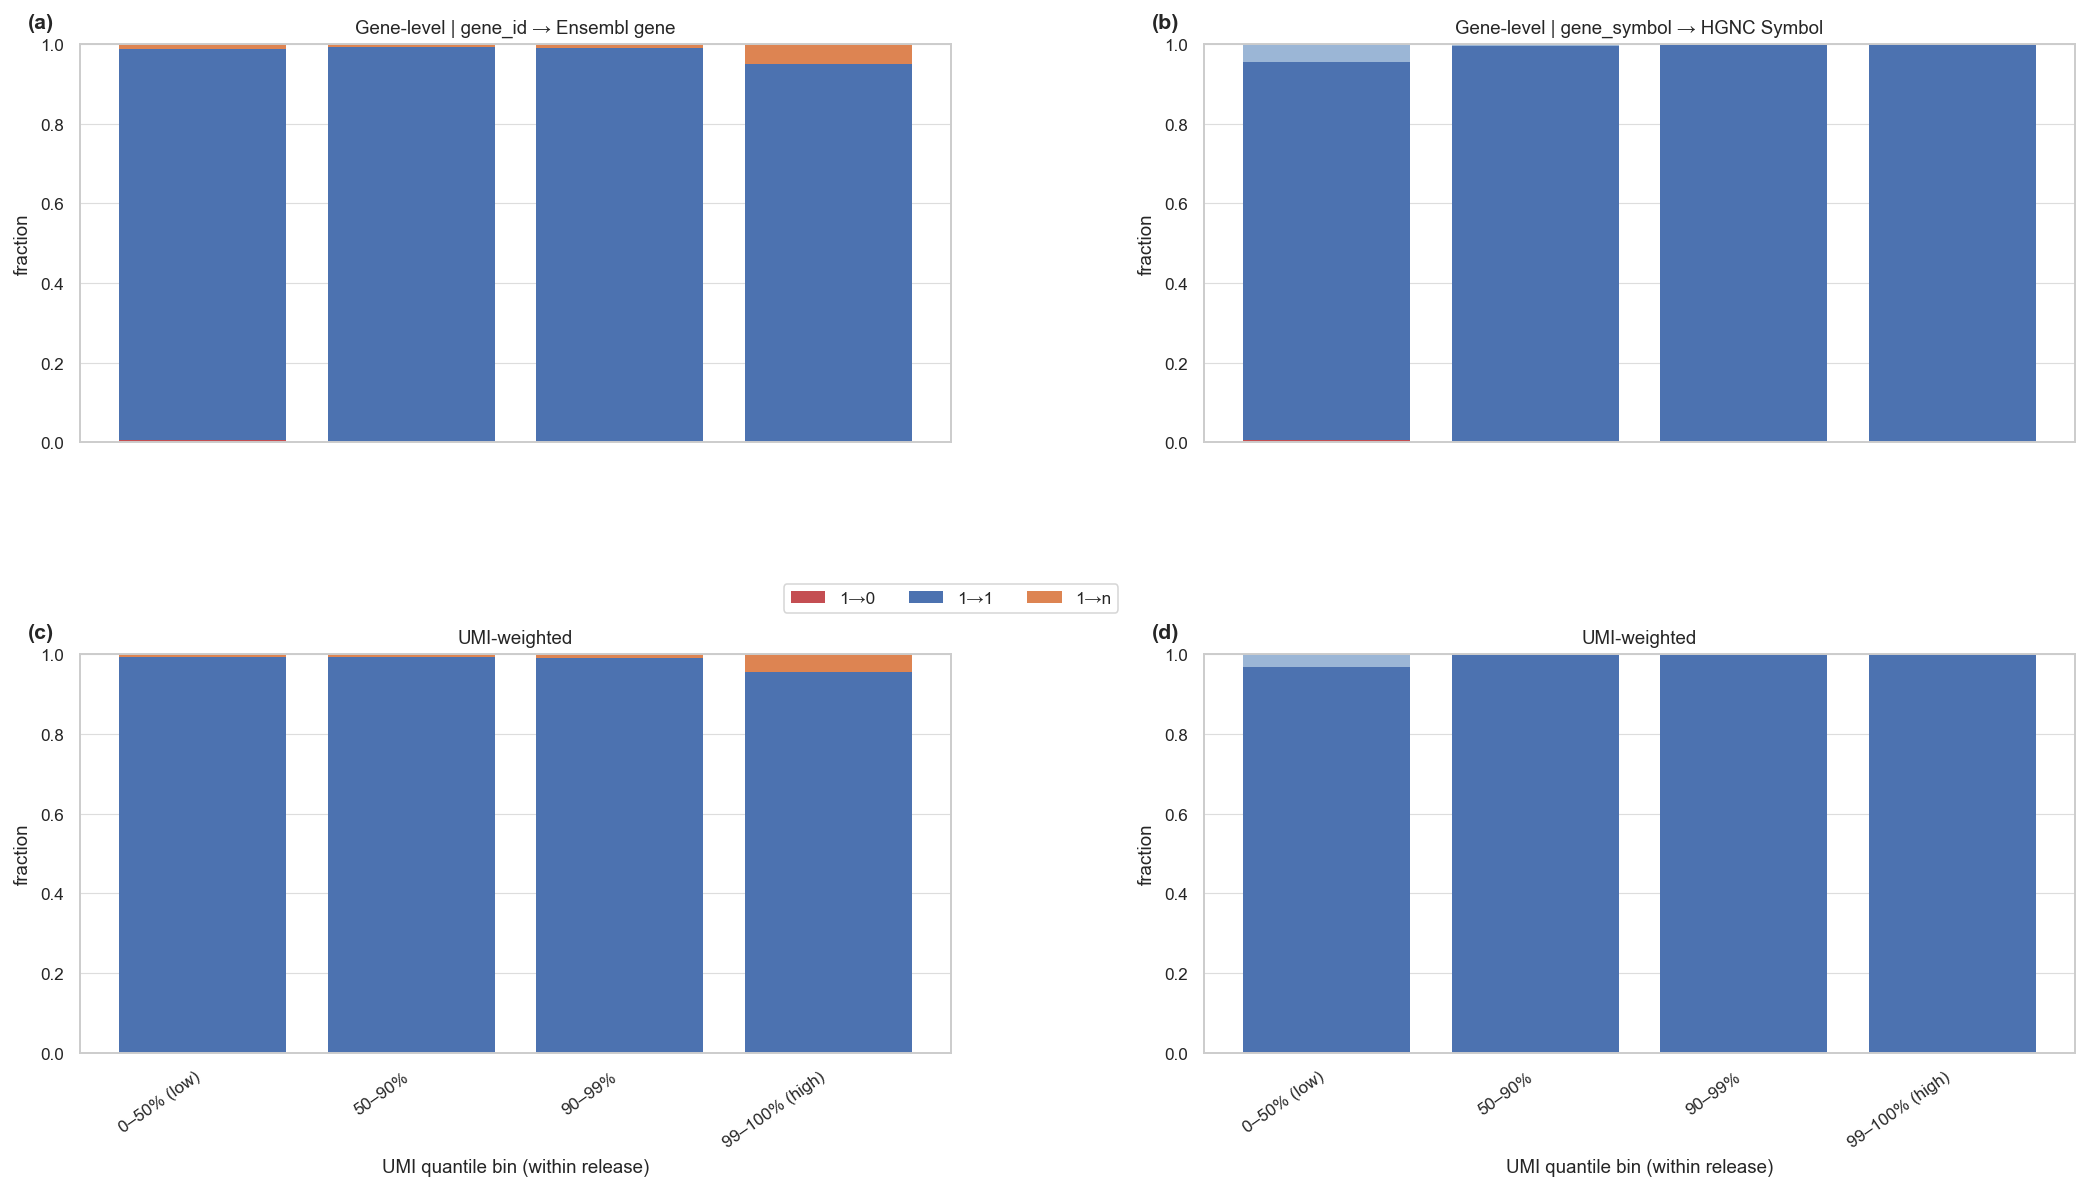

In [23]:
# -------------------- Outcome profiles by UMI quantile (focus release) --------------------

Q_BINS = [
    (0.00, 0.50, "0–50% (low)"),
    (0.50, 0.90, "50–90%"),
    (0.90, 0.99, "90–99%"),
    (0.99, 1.00, "99–100% (high)"),
]


def _expr_bin_cache_path(*, from_db: str, to_db: str) -> Path:
    stem = safe_tag(
        f"expr_bin_outcomes_{DATASET_SEL}_{ASSEMBLY_SEL}_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}_{from_db}__{to_db}"
    )
    return CACHE_DIR / f"{stem}.pickle"


def compute_expr_bin_table(*, from_db: str, to_db: str) -> pd.DataFrame:
    pb = get_pseudobulk(int(FOCUS_FROM_RELEASE))
    totals = np.asarray(pb["totals"]).astype(np.float64, copy=False)

    matchings = load_matchings(
        runs_sel,
        dataset=DATASET_SEL,
        assembly=ASSEMBLY_SEL,
        from_release=int(FOCUS_FROM_RELEASE),
        from_database=str(from_db),
        to_database=str(to_db),
        to_release=int(TARGET_RELEASE),
    )
    if matchings is None:
        raise FileNotFoundError(
            f"Missing matchings for from_release={FOCUS_FROM_RELEASE} {from_db}→{to_db} to_release={TARGET_RELEASE}"
        )
    if len(matchings) != int(totals.shape[0]):
        raise ValueError("Mismatch between matchings length and feature totals length.")

    _, _, dbg = build_mapping_matrix(matchings, strategy="best")

    ranks = pd.Series(totals).rank(method="average", pct=True).values
    final_db = _canonical_final_db(str(to_db))

    if final_db == "HGNC Symbol":
        cats = [
            ("1→0", dbg["is_1_to_0"], MANUSCRIPT_COLORS["1→0"]),
            ("1→1 TDM", dbg["is_1_to_1"] & (~dbg["is_atm"]), MANUSCRIPT_COLORS["1→1 TDM"]),
            ("1→1 ATM", dbg["is_1_to_1"] & dbg["is_atm"], MANUSCRIPT_COLORS["1→1 ATM"]),
            ("1→n TDM", dbg["is_1_to_n"] & (~dbg["is_atm"]), MANUSCRIPT_COLORS["1→n TDM"]),
            ("1→n ATM", dbg["is_1_to_n"] & dbg["is_atm"], MANUSCRIPT_COLORS["1→n ATM"]),
        ]
    else:
        cats = [
            ("1→0", dbg["is_1_to_0"], MANUSCRIPT_COLORS["1→0"]),
            ("1→1", dbg["is_1_to_1"], MANUSCRIPT_COLORS["1→1"]),
            ("1→n", dbg["is_1_to_n"], MANUSCRIPT_COLORS["1→n"]),
        ]

    rows = []
    for low, high, label in Q_BINS:
        if float(low) <= 0:
            m = ranks <= float(high)
        else:
            m = (ranks > float(low)) & (ranks <= float(high))

        bin_n = int(m.sum())
        bin_umis = float(totals[m].sum())

        for cat, cat_mask, _ in cats:
            nm = int((m & cat_mask).sum())
            um = float(totals[m & cat_mask].sum())
            rows.append(
                {
                    "dataset": DATASET_SEL,
                    "assembly": ASSEMBLY_SEL,
                    "from_release": int(FOCUS_FROM_RELEASE),
                    "to_release": int(TARGET_RELEASE),
                    "from_database": str(from_db),
                    "final_database": str(final_db),
                    "bin": str(label),
                    "bin_low": float(low),
                    "bin_high": float(high),
                    "category": str(cat),
                    "bin_n_genes": int(bin_n),
                    "bin_total_umis": float(bin_umis),
                    "n_genes": int(nm),
                    "frac_genes_in_bin": (float(nm) / float(bin_n)) if bin_n else float("nan"),
                    "umis": float(um),
                    "frac_umis_in_bin": (float(um) / float(bin_umis)) if bin_umis else float("nan"),
                }
            )

    return pd.DataFrame(rows)


expr_bins_parts = []
for from_db, to_db in [("gene_id", "ensembl_gene"), ("gene_symbol", "HGNC Symbol")]:
    p = _expr_bin_cache_path(from_db=from_db, to_db=to_db)
    expr_bins_parts.append(
        cache_pickle_or_compute(
            p,
            lambda from_db=from_db, to_db=to_db: compute_expr_bin_table(from_db=from_db, to_db=to_db),
            force=FORCE_REBUILD,
        )
    )

expr_bins = pd.concat(expr_bins_parts, ignore_index=True)

out_expr_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_expression_bin_outcomes_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(expr_bins, out_expr_csv, index=False)
atomic_write_dataframe_csv(expr_bins, ctx.experiment_outputs / "tables" / out_expr_csv.name, index=False)
print("Wrote:", out_expr_csv)


figB, axesB = plt.subplots(2, 2, figsize=(14.8, 8.4), constrained_layout=True, sharex="col")
channelsB = [
    ("gene_id", "Ensembl gene"),
    ("gene_symbol", "HGNC Symbol"),
]
bin_order = [b[2] for b in Q_BINS]

for col_idx, (from_db, final_db) in enumerate(channelsB):
    sub = expr_bins[(expr_bins["from_database"] == from_db) & (expr_bins["final_database"] == final_db)].copy()
    if sub.empty:
        axesB[0, col_idx].axis("off")
        axesB[1, col_idx].axis("off")
        continue

    if final_db == "HGNC Symbol":
        cat_order = ["1→0", "1→1 TDM", "1→1 ATM", "1→n TDM", "1→n ATM"]
        colors = [
            MANUSCRIPT_COLORS["1→0"],
            MANUSCRIPT_COLORS["1→1 TDM"],
            MANUSCRIPT_COLORS["1→1 ATM"],
            MANUSCRIPT_COLORS["1→n TDM"],
            MANUSCRIPT_COLORS["1→n ATM"],
        ]
    else:
        cat_order = ["1→0", "1→1", "1→n"]
        colors = [MANUSCRIPT_COLORS["1→0"], MANUSCRIPT_COLORS["1→1"], MANUSCRIPT_COLORS["1→n"]]

    def _stack(ax, value_col: str, title: str) -> None:
        bottoms = np.zeros(len(bin_order), dtype=float)
        xs = np.arange(len(bin_order))

        for cat, color in zip(cat_order, colors, strict=False):
            vals = []
            for b in bin_order:
                v = sub[(sub["bin"] == b) & (sub["category"] == cat)][value_col]
                vals.append(float(v.iloc[0]) if len(v) else 0.0)
            ax.bar(xs, vals, bottom=bottoms, color=color, edgecolor="none", label=cat)
            bottoms = bottoms + np.asarray(vals)

        ax.set_xticks(xs)
        ax.set_xticklabels(bin_order, rotation=35, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.set_ylabel("fraction")
        ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

    _stack(axesB[0, col_idx], "frac_genes_in_bin", f"Gene-level | {from_db} → {final_db}")
    _stack(axesB[1, col_idx], "frac_umis_in_bin", "UMI-weighted")
    axesB[1, col_idx].set_xlabel("UMI quantile bin (within release)")

axesB[0, 0].legend(frameon=True, ncol=3, loc="lower center", bbox_to_anchor=(1.0, -0.45))
label_panels(axesB.ravel())
writtenB = save_figure(
    figB,
    f"fig_cellranger_idtrack_expression_bins_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.pdf",
    ctx,
    formats=("pdf",),
)
print("Saved:", writtenB["pdf"])

expr_bins.head(12)


## 11) Deep-dive (cell level): per-cell agreement and UMI recovery

Pseudo-bulk agreement is necessary but not sufficient: readers may ask whether the improvement holds *per cell*.

This section (default: enabled) aligns shared cell barcodes between releases and quantifies, per cell:

- expression-profile agreement (Pearson correlation on log1p-normalized counts)
- fraction of UMIs that land in a comparable feature space

The computation is cached so repeated figure tweaks are fast.



Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_cell_level_deepdive_from85_to105.csv
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_cell_level_deepdive_from85_to105.pdf


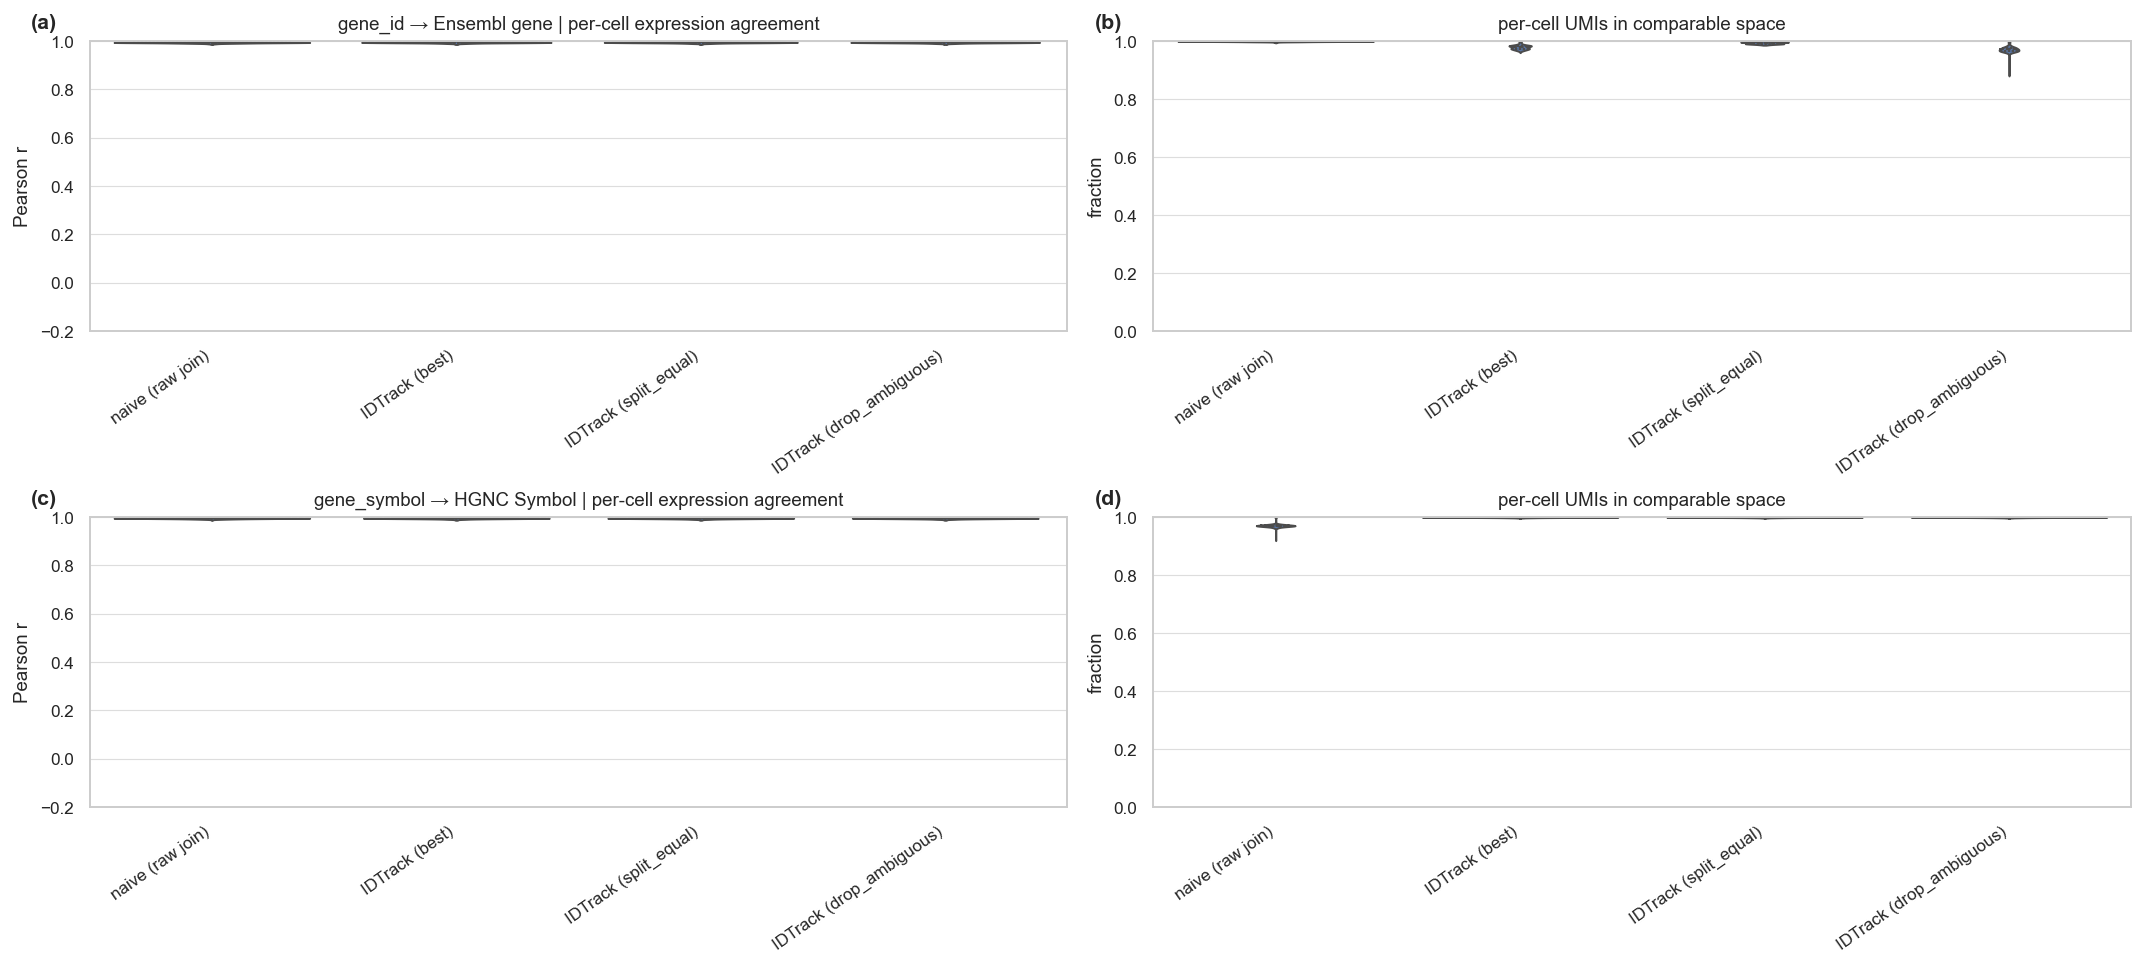

In [24]:
# -------------------- Cell-level deep dive (focus release; cached) --------------------

if not RUN_CELL_LEVEL_DEEPDIVE:
    print("Skipping cell-level deep dive (set IDTRACK_RUN_CELL_LEVEL_DEEPDIVE=1 to enable).")
else:
    from_release = int(FOCUS_FROM_RELEASE)
    to_release = int(TARGET_RELEASE)

    cell_cache = CACHE_DIR / safe_tag(
        f"cell_level_deepdive_{DATASET_SEL}_{ASSEMBLY_SEL}_from{from_release}_to{to_release}_g{CELL_LEVEL_MAX_GENES}_c{CELL_LEVEL_MAX_CELLS}"
    )
    cell_cache = cell_cache.with_suffix(".pickle")


    def _to_csr(X):
        if sparse.issparse(X):
            return X.tocsr()
        return sparse.csr_matrix(np.asarray(X))


    def _rowwise_pearson(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        if a.shape != b.shape:
            raise ValueError(f"shape mismatch: {a.shape} vs {b.shape}")
        if a.shape[1] < 2:
            return np.full(a.shape[0], np.nan, dtype=float)

        am = a.mean(axis=1, keepdims=True)
        bm = b.mean(axis=1, keepdims=True)
        aa = a - am
        bb = b - bm
        num = (aa * bb).sum(axis=1)
        den = np.sqrt((aa * aa).sum(axis=1)) * np.sqrt((bb * bb).sum(axis=1))
        out = np.full(a.shape[0], np.nan, dtype=float)
        good = den > 0
        out[good] = num[good] / den[good]
        return out


    def _normalize_log1p(mat: np.ndarray, *, target_sum: float) -> np.ndarray:
        sums = mat.sum(axis=1)
        scale = np.where(sums > 0, float(target_sum) / sums, 0.0)
        return np.log1p(mat * scale[:, None])


    def _rowwise_corr_sparse(
        Xa,
        Xb,
        *,
        chunk_size: int,
        target_sum: float,
    ) -> np.ndarray:
        if Xa.shape != Xb.shape:
            raise ValueError(f"shape mismatch: {Xa.shape} vs {Xb.shape}")
        n = int(Xa.shape[0])
        p = int(Xa.shape[1])
        if p < 2:
            return np.full(n, np.nan, dtype=float)

        cs = int(chunk_size) if int(chunk_size) > 0 else n
        out = np.full(n, np.nan, dtype=float)
        for start in range(0, n, cs):
            end = min(n, start + cs)
            A = Xa[start:end].toarray()
            B = Xb[start:end].toarray()
            out[start:end] = _rowwise_pearson(
                _normalize_log1p(A, target_sum=float(target_sum)),
                _normalize_log1p(B, target_sum=float(target_sum)),
            )
        return out


    def _build_normalization_matrix(ids: list[str], *, normalize: str) -> tuple[sparse.csr_matrix, list[str]]:
        if normalize == "gene_id":
            keys = [_normalize_gene_id(x) for x in ids]
        elif normalize == "gene_symbol":
            keys = [_normalize_gene_symbol(x) for x in ids]
        else:
            keys = [str(x) for x in ids]

        keys = [str(k) for k in keys]
        uniq = sorted(set(keys))
        idx = {k: j for j, k in enumerate(uniq)}

        rows = np.arange(len(keys), dtype=int)
        cols = np.array([idx[k] for k in keys], dtype=int)
        data = np.ones(len(keys), dtype=float)
        M = sparse.csr_matrix((data, (rows, cols)), shape=(len(keys), len(uniq)), dtype=float)
        return M, uniq


    def _compute_cell_level() -> pd.DataFrame:
        src_path = release_to_h5ad.get(from_release)
        tgt_path = release_to_h5ad.get(to_release)
        if src_path is None or tgt_path is None:
            raise FileNotFoundError("Missing h5ad paths for deep-dive releases.")

        ad_src = ad.read_h5ad(str(src_path))
        ad_tgt = ad.read_h5ad(str(tgt_path))

        common_cells = sorted(set(ad_src.obs_names) & set(ad_tgt.obs_names))
        if not common_cells:
            raise RuntimeError("No shared cell barcodes between releases; cannot do per-cell pairing.")

        if CELL_LEVEL_MAX_CELLS and len(common_cells) > int(CELL_LEVEL_MAX_CELLS):
            rng = np.random.default_rng(0)
            idx = rng.choice(np.arange(len(common_cells)), size=int(CELL_LEVEL_MAX_CELLS), replace=False)
            common_cells = [common_cells[i] for i in sorted(idx.tolist())]

        ad_src = ad_src[common_cells].copy()
        ad_tgt = ad_tgt[common_cells].copy()

        X_src = _to_csr(ad_src.X)
        X_tgt = _to_csr(ad_tgt.X)

        total_src = np.asarray(X_src.sum(axis=1)).ravel().astype(float)

        out_rows = []

        channels = [
            ("gene_id", "ensembl_gene", "Ensembl gene"),
            ("gene_symbol", "HGNC Symbol", "HGNC Symbol"),
        ]

        for from_db, to_db, final_db in channels:
            if from_db not in ad_src.var.columns or from_db not in ad_tgt.var.columns:
                print(f"[WARN] Missing {from_db!r} in var; skipping channel.")
                continue

            # -------------------- Baseline: naive raw join (no time travel) --------------------
            norm_kind = "gene_id" if from_db == "gene_id" else "gene_symbol"
            M_src_raw, ids_src_raw = _build_normalization_matrix(
                ad_src.var[from_db].astype(str).tolist(),
                normalize=norm_kind,
            )
            M_tgt_raw, ids_tgt_raw = _build_normalization_matrix(
                ad_tgt.var[from_db].astype(str).tolist(),
                normalize=norm_kind,
            )

            X_src_raw = X_src.dot(M_src_raw)
            X_tgt_raw = X_tgt.dot(M_tgt_raw)

            idx_src_raw = {k: j for j, k in enumerate(ids_src_raw)}
            idx_tgt_raw = {k: j for j, k in enumerate(ids_tgt_raw)}
            common_raw = sorted(set(idx_src_raw) & set(idx_tgt_raw))

            if common_raw and total_src.size:
                cols_common_src = [idx_src_raw[g] for g in common_raw]
                common_sum = np.asarray(X_src_raw[:, cols_common_src].sum(axis=1)).ravel().astype(float)
                frac_common = np.where(total_src > 0, common_sum / total_src, np.nan)
            else:
                frac_common = np.full(X_src.shape[0], np.nan, dtype=float)

            # Per-cell agreement on a consistent (top) gene set in the comparable space
            if len(common_raw) >= 2:
                tgt_series_raw = raw_pseudobulk(from_release=to_release, from_database=from_db)
                common_series = tgt_series_raw.reindex(common_raw).fillna(0.0)
                sel = common_series.nlargest(min(int(CELL_LEVEL_MAX_GENES), int(common_series.size))).index.tolist()

                idx_src_sel = [idx_src_raw[g] for g in sel if g in idx_src_raw]
                idx_tgt_sel = [idx_tgt_raw[g] for g in sel if g in idx_tgt_raw]

                r_cell = _rowwise_corr_sparse(
                    X_src_raw[:, idx_src_sel],
                    X_tgt_raw[:, idx_tgt_sel],
                    chunk_size=int(CELL_LEVEL_CHUNK_SIZE),
                    target_sum=float(CELL_LEVEL_NORM_SUM),
                )
            else:
                r_cell = np.full(X_src.shape[0], np.nan, dtype=float)

            out_rows.extend(
                {
                    "cell": str(cell),
                    "from_database": str(from_db),
                    "final_database": "(raw)",
                    "strategy": "raw_exact_join",
                    "corr_cell_pearson_log1p": float(r),
                    "frac_umis_in_common": float(f),
                    "frac_umis_retained": 1.0,
                }
                for cell, r, f in zip(ad_src.obs_names.tolist(), r_cell, frac_common, strict=False)
            )

            # -------------------- IDTrack: time travel into target release --------------------
            for strategy in ("best", "drop_ambiguous", "split_equal"):
                match_src = load_matchings(
                    runs_sel,
                    dataset=DATASET_SEL,
                    assembly=ASSEMBLY_SEL,
                    from_release=from_release,
                    from_database=from_db,
                    to_database=to_db,
                    to_release=to_release,
                )
                match_tgt = load_matchings(
                    runs_sel,
                    dataset=DATASET_SEL,
                    assembly=ASSEMBLY_SEL,
                    from_release=to_release,
                    from_database=from_db,
                    to_database=to_db,
                    to_release=to_release,
                )

                if match_src is None or match_tgt is None:
                    print(f"[WARN] Missing matchings for {from_db}→{to_db} ({strategy}); skipping.")
                    continue

                M_src, ids_src, _ = build_mapping_matrix(match_src, strategy=str(strategy))
                M_tgt, ids_tgt, _ = build_mapping_matrix(match_tgt, strategy=str(strategy))

                X_src_map = X_src.dot(M_src)
                X_tgt_map = X_tgt.dot(M_tgt)

                idx_src_map = {k: j for j, k in enumerate(ids_src)}
                idx_tgt_map = {k: j for j, k in enumerate(ids_tgt)}
                common = sorted(set(idx_src_map) & set(idx_tgt_map))

                if common and total_src.size:
                    cols_common_src = [idx_src_map[g] for g in common]
                    common_sum = np.asarray(X_src_map[:, cols_common_src].sum(axis=1)).ravel().astype(float)
                    retained_sum = np.asarray(X_src_map.sum(axis=1)).ravel().astype(float)
                    frac_common_map = np.where(total_src > 0, common_sum / total_src, np.nan)
                    frac_retained_map = np.where(total_src > 0, retained_sum / total_src, np.nan)
                else:
                    frac_common_map = np.full(X_src.shape[0], np.nan, dtype=float)
                    frac_retained_map = np.full(X_src.shape[0], np.nan, dtype=float)

                if len(common) >= 2:
                    tgt_series_map, _ = mapped_pseudobulk(
                        from_release=to_release,
                        from_database=from_db,
                        to_database=to_db,
                        strategy=str(strategy),
                    )
                    common_series = tgt_series_map.reindex(common).fillna(0.0)
                    sel = common_series.nlargest(min(int(CELL_LEVEL_MAX_GENES), int(common_series.size))).index.tolist()

                    idx_src_sel = [idx_src_map[g] for g in sel if g in idx_src_map]
                    idx_tgt_sel = [idx_tgt_map[g] for g in sel if g in idx_tgt_map]

                    r_cell = _rowwise_corr_sparse(
                        X_src_map[:, idx_src_sel],
                        X_tgt_map[:, idx_tgt_sel],
                        chunk_size=int(CELL_LEVEL_CHUNK_SIZE),
                        target_sum=float(CELL_LEVEL_NORM_SUM),
                    )
                else:
                    r_cell = np.full(X_src.shape[0], np.nan, dtype=float)

                out_rows.extend(
                    {
                        "cell": str(cell),
                        "from_database": str(from_db),
                        "final_database": str(final_db),
                        "strategy": str(strategy),
                        "corr_cell_pearson_log1p": float(r),
                        "frac_umis_in_common": float(f),
                        "frac_umis_retained": float(fr),
                    }
                    for cell, r, f, fr in zip(
                        ad_src.obs_names.tolist(),
                        r_cell,
                        frac_common_map,
                        frac_retained_map,
                        strict=False,
                    )
                )

        return pd.DataFrame(out_rows)


    cell_level_df = cache_pickle_or_compute(cell_cache, _compute_cell_level, force=FORCE_REBUILD)

    out_cell_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_cell_level_deepdive_from{from_release}_to{to_release}.csv"
    atomic_write_dataframe_csv(cell_level_df, out_cell_csv, index=False)
    atomic_write_dataframe_csv(cell_level_df, ctx.experiment_outputs / "tables" / out_cell_csv.name, index=False)
    print("Wrote:", out_cell_csv)

    # -------------------- Figure: per-cell agreement + UMI recovery --------------------
    plot_channels = [
        ("gene_id", "Ensembl gene"),
        ("gene_symbol", "HGNC Symbol"),
    ]
    strategy_order = ["raw_exact_join", "best", "split_equal", "drop_ambiguous"]
    strategy_labels = {
        "raw_exact_join": "naive (raw join)",
        "best": "IDTrack (best)",
        "split_equal": "IDTrack (split_equal)",
        "drop_ambiguous": "IDTrack (drop_ambiguous)",
    }

    figCL, axesCL = plt.subplots(len(plot_channels), 2, figsize=(15.2, 6.8), constrained_layout=True)
    if len(plot_channels) == 1:
        axesCL = np.array([axesCL])


    def _plot_distribution(ax, sub: pd.DataFrame, *, y: str, title: str, ylim: tuple[float, float]) -> None:
        sub = sub.dropna(subset=[y]).copy()
        if sub.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            return

        sub["strategy_label"] = sub["strategy"].map(strategy_labels).fillna(sub["strategy"])
        order = [strategy_labels[s] for s in strategy_order if s in set(sub["strategy"].astype(str))]

        if sns is not None:
            sns.violinplot(data=sub, x="strategy_label", y=y, order=order, ax=ax, cut=0, inner="quartile")
        else:
            data = [sub[sub["strategy"] == s][y].values for s in strategy_order if s in set(sub["strategy"].astype(str))]
            ax.boxplot(data, showfliers=False)
            ax.set_xticks(np.arange(1, len(data) + 1))
            ax.set_xticklabels(order, rotation=35, ha="right")

        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)
        ax.set_xlabel("")
        ax.set_ylabel("")

        for tick in ax.get_xticklabels():
            tick.set_rotation(35)
            tick.set_ha("right")


    for row_idx, (from_db, final_db) in enumerate(plot_channels):
        sub = cell_level_df[cell_level_df["from_database"] == from_db].copy()
        _plot_distribution(
            axesCL[row_idx, 0],
            sub,
            y="corr_cell_pearson_log1p",
            title=f"{from_db} → {final_db} | per-cell expression agreement",
            ylim=(-0.2, 1.0),
        )
        _plot_distribution(
            axesCL[row_idx, 1],
            sub,
            y="frac_umis_in_common",
            title="per-cell UMIs in comparable space",
            ylim=(0.0, 1.0),
        )
        axesCL[row_idx, 0].set_ylabel("Pearson r")
        axesCL[row_idx, 1].set_ylabel("fraction")

    label_panels(axesCL.ravel())
    writtenCL = save_figure(
        figCL,
        f"fig_cellranger_idtrack_cell_level_deepdive_from{from_release}_to{to_release}.pdf",
        ctx,
        formats=("pdf",),
    )
    print("Saved:", writtenCL["pdf"])

    cell_level_df.head(12)


## 12) Ambiguity strategy sweep (focus release)

IDTrack exposes ambiguity rather than silently forcing a single target.

This section compares three downstream policies for 1→n outputs:

- `best`: choose the top-ranked target (maximizes determinism)
- `drop_ambiguous`: keep only strict 1→1 mappings (maximizes precision)
- `split_equal`: split 1→n counts equally across targets (UMI-preserving, non-arbitrary)

The point is not that one policy is universally “correct”, but that IDTrack makes the trade-off explicit and reportable.



Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/cellranger_idtrack_strategy_sweep_from85_to105.csv
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_cellranger_idtrack_strategy_sweep_from85_to105.pdf


,from_release,to_release,from_database,final_database,strategy,corr_pearson_log1p,jaccard,frac_umis_retained,frac_umis_in_common,frac_1_to_0_genes,frac_1_to_n_genes,frac_atm_genes
0,85,105,gene_id,Ensembl gene,best,0.993299,0.951810,0.999979,0.978303,0.002405,0.009669,0.000000
1,85,105,gene_id,Ensembl gene,drop_ambiguous,0.993286,0.961933,0.976956,0.970184,0.002405,0.009669,0.000000
2,85,105,gene_id,Ensembl gene,split_equal,0.993246,0.960283,0.999979,0.993131,0.002405,0.009669,0.000000
3,85,105,gene_symbol,HGNC Symbol,best,0.992306,0.960358,0.999928,0.998725,0.002755,0.000050,0.024498
4,85,105,gene_symbol,HGNC Symbol,drop_ambiguous,0.992306,0.960358,0.999928,0.998725,0.002755,0.000050,0.024498
5,85,105,gene_symbol,HGNC Symbol,split_equal,0.992306,0.960358,0.999928,0.998725,0.002755,0.000050,0.024498


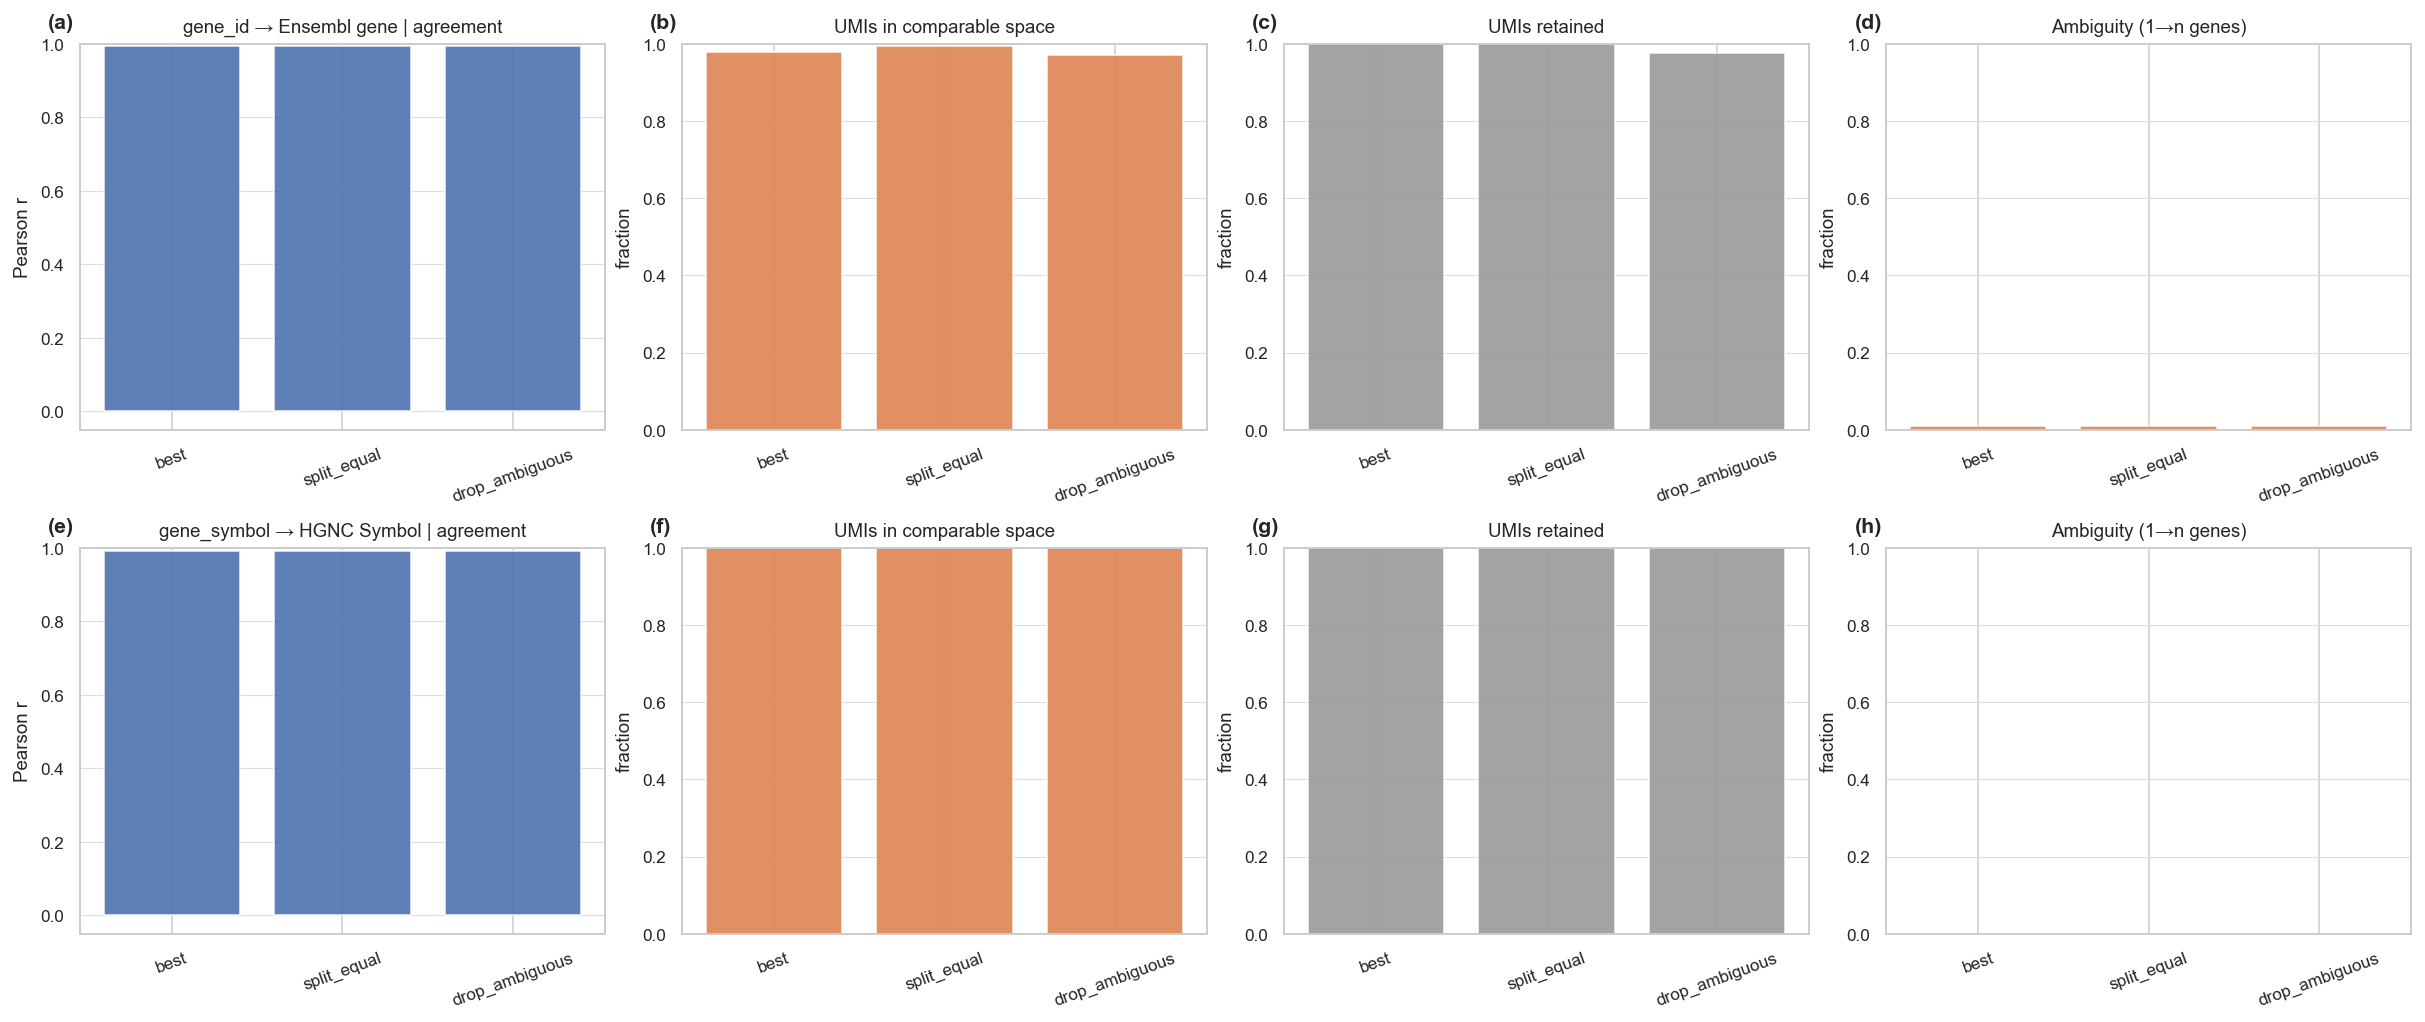

In [25]:
# -------------------- Strategy sweep (focus release) --------------------

focus_channels = [
    ("gene_id", "ensembl_gene"),
    ("gene_symbol", "HGNC Symbol"),
]

sweep_rows = []
for from_db, to_db in focus_channels:
    final_db = _canonical_final_db(to_db)
    raw_src = raw_pseudobulk(from_release=int(FOCUS_FROM_RELEASE), from_database=str(from_db))
    total_umis = float(raw_src.sum())

    for strategy in ("best", "drop_ambiguous", "split_equal"):
        src_m, dbg = mapped_pseudobulk(
            from_release=int(FOCUS_FROM_RELEASE),
            from_database=str(from_db),
            to_database=str(to_db),
            strategy=str(strategy),
        )
        tgt_m, _ = mapped_pseudobulk(
            from_release=int(TARGET_RELEASE),
            from_database=str(from_db),
            to_database=str(to_db),
            strategy=str(strategy),
        )

        common = sorted(set(src_m.index) & set(tgt_m.index))
        a = src_m.reindex(common).astype(float)
        b = tgt_m.reindex(common).astype(float)

        frac_retained = float(src_m.sum() / total_umis) if total_umis else float("nan")
        frac_comparable = float(a.sum() / total_umis) if total_umis else float("nan")

        sweep_rows.append(
            {
                "from_release": int(FOCUS_FROM_RELEASE),
                "to_release": int(TARGET_RELEASE),
                "from_database": str(from_db),
                "final_database": str(final_db),
                "strategy": str(strategy),
                "corr_pearson_log1p": pearsonr_log1p(a, b),
                "jaccard": float(jaccard_similarity(set(src_m.index), set(tgt_m.index))),
                "frac_umis_retained": float(frac_retained),
                "frac_umis_in_common": float(frac_comparable),
                "frac_1_to_0_genes": float(dbg["is_1_to_0"].mean()),
                "frac_1_to_n_genes": float(dbg["is_1_to_n"].mean()),
                "frac_atm_genes": float(dbg["is_atm"].mean()),
            }
        )

strategy_sweep = pd.DataFrame(sweep_rows)

out_sweep_csv = MANUSCRIPT_TABLES / f"cellranger_idtrack_strategy_sweep_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.csv"
atomic_write_dataframe_csv(strategy_sweep, out_sweep_csv, index=False)
atomic_write_dataframe_csv(strategy_sweep, ctx.experiment_outputs / "tables" / out_sweep_csv.name, index=False)
print("Wrote:", out_sweep_csv)


# Figure: compact trade-off summary (per channel)
figS, axesS = plt.subplots(2, 4, figsize=(17.2, 7.2), constrained_layout=True)
strategy_order = ["best", "split_equal", "drop_ambiguous"]

for row_idx, (from_db, to_db) in enumerate(focus_channels):
    final_db = _canonical_final_db(to_db)
    sub = strategy_sweep[(strategy_sweep["from_database"] == from_db) & (strategy_sweep["final_database"] == final_db)].copy()
    sub["strategy"] = pd.Categorical(sub["strategy"], categories=strategy_order, ordered=True)
    sub = sub.sort_values("strategy")

    xs = np.arange(len(sub))
    labels = sub["strategy"].astype(str).tolist()

    axesS[row_idx, 0].bar(xs, sub["corr_pearson_log1p"], color=MANUSCRIPT_COLORS["1→1"], alpha=0.9)
    axesS[row_idx, 0].set_ylim(-0.05, 1)
    axesS[row_idx, 0].set_title(f"{from_db} → {final_db} | agreement")
    axesS[row_idx, 0].set_ylabel("Pearson r")

    axesS[row_idx, 1].bar(xs, sub["frac_umis_in_common"], color=MANUSCRIPT_COLORS["1→n"], alpha=0.9)
    axesS[row_idx, 1].set_ylim(0, 1)
    axesS[row_idx, 1].set_title("UMIs in comparable space")
    axesS[row_idx, 1].set_ylabel("fraction")

    axesS[row_idx, 2].bar(xs, sub["frac_umis_retained"], color=MANUSCRIPT_COLORS["neutral"], alpha=0.9)
    axesS[row_idx, 2].set_ylim(0, 1)
    axesS[row_idx, 2].set_title("UMIs retained")
    axesS[row_idx, 2].set_ylabel("fraction")

    axesS[row_idx, 3].bar(xs, sub["frac_1_to_n_genes"], color=MANUSCRIPT_COLORS["1→n"], alpha=0.9)
    axesS[row_idx, 3].set_ylim(0, 1)
    axesS[row_idx, 3].set_title("Ambiguity (1→n genes)")
    axesS[row_idx, 3].set_ylabel("fraction")

    for col in range(4):
        ax = axesS[row_idx, col]
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=20)
        ax.grid(True, axis="y", color=MANUSCRIPT_COLORS["grid"], lw=0.6)

label_panels(axesS.ravel())
writtenS = save_figure(
    figS,
    f"fig_cellranger_idtrack_strategy_sweep_from{FOCUS_FROM_RELEASE}_to{TARGET_RELEASE}.pdf",
    ctx,
    formats=("pdf",),
)
print("Saved:", writtenS["pdf"])

strategy_sweep
